# NeXo v3.0 · Notebook 00 — Exploratory Data Analysis (CRISP-DM Phase 2)

> **Defense-grade EDA** on real Tunisie Telecom OSS + BSS data.
> Audience: thesis jury + Huawei supervisor (defense window mid-Jun → mid-Jul 2026).
> Methodology: **CRISP-DM Phase 2 — Data Understanding** (Collect Initial Data → Describe Data → Explore Data → Verify Data Quality).

## Goal

Understand the **full** Tunisie Telecom dataset before any cleaning or modeling. Every distribution, every NaN pattern, every relationship — visualized inline with **statistical evidence**, not visual intuition alone.

## Scope

- **BSS**: 16 monthly CSVs in `TT_data/BSS/` — real (Feb 468K, Mars 500K) + bootstrap-simulated (Jan, Apr, May, Jun, Jul, Aug, Sep). Includes `_consistent` simulator variants.
- **OSS**: 3 raw Huawei CSV exports (2G + 3G + 4G), header at row 8.

## Output Policy

**Read-only.** No files saved by this notebook. Notebook 01 owns all writes (MinIO + parquet). Figures shown inline via `plt.show()` only. This is a deliberate contract — re-running this notebook never mutates downstream artifacts.

## CRISP-DM Phase 2 Section Map

| § | CRISP-DM Sub-Task | What we do |
|---|---|---|
| §0–§2 | Setup | Reproducibility, constants, data dictionary, env fingerprint |
| §3–§6 | Collect + Describe (BSS) | Load, shape, dtypes, memory, row counts |
| §7–§9 | Verify Data Quality (BSS) | Missingness matrix + bar + dendrogram (`missingno`) |
| §10–§13 | Explore Data (BSS) | Numeric/categorical distributions, outliers (skew-based log1p) |
| §14 | Explore Relationships (BSS) | Pearson + Spearman + Mutual Information (linear + monotonic + non-linear) |
| §15–§19 | Collect + Describe + Verify (OSS) | Per-RAT load, columns, missingness |
| §20–§22 | Explore Data (OSS) | Integrity, CDR, 4G richness |
| §22.5 | Distribution-vs-Target | KDE overlays by `dou_total` quartile (proxy CEM target) |
| §23 | Geographic Intelligence | Tunisia governorate choropleth (24 governorates) |
| §24 | Real-vs-Simulated Validation | KS test for generator fidelity (statistical evidence, not just visual) |
| §25 | Summary | In-memory findings dict |
| §26 | Limitations | Threats to validity |
| §27 | Sources | Citations |

## Reading Convention (every chart)

- **What this shows** — one sentence on the chart's purpose.
- **What to look for** — one sentence on the interpretation reviewers should focus on.

## Confidentiality

Raw `TT_data/` rows are **never** printed. Only aggregates (counts, percentiles, histograms, correlations, choropleths). All cells reading `TT_data/` paths are local-only — never export.

## 0 · Reproducibility, Constants & Data Dictionary

**What this shows:** All sampling sizes, SLA thresholds, statistical alphas, and geographic paths in ONE place. Papermill-overridable at retrain time.
**What to look for:** Whether constants are documented + cited (Bulmer 1979 for skew, Massey 1951 for KS, Huawei spec for SLA).

In [1]:
# --- Papermill parameters cell (do not remove the `parameters` tag in JSON metadata) ---
# Consumed by `pb-model-retrain` playbook which papermill-overrides values at runtime.
# All values below are DEFAULTS only — runtime can override via -p flags.

# Sampling controls (kept conservative for defense reproducibility)
SAMPLE_N_FOR_MISSINGNESS = 20_000   # missingno render budget (full dataset is 8M rows)
TOP_AREAS_N              = 20       # top-N areas to display in bar chart
HEAVY_TAIL_LOG1P_SKEW    = 1.0      # |skew| > this → use log1p axis (Bulmer 1979)

# SLA constants (from Huawei OSS KPI specification — never change without supervisor approval)
SLA_INTEGRITY_TARGET     = 98.0     # OSS Integrity (%) target
SLA_CDR_THRESHOLD        = 2.0      # Call Drop Rate (%) anomaly threshold
HUAWEI_OSS_HEADER_ROW    = 6        # rows 1–7 = Huawei metadata; row 8 = column headers

# KS test thresholds (Massey 1951)
KS_PVALUE_DRIFT_ALPHA    = 0.05     # reject H0 (same distribution) below this p

# Geographic
TUNISIA_GEOJSON_PATH     = '../dashboard/lib/tunisia-geojson.json'   # 24 governorates

# Quartile binning for distribution-vs-target overlays
TARGET_QUARTILE_COL      = 'dou_total'   # proxy for CEM experience (high dou → engaged subscriber)
N_QUARTILES              = 4

print(f'SAMPLE_N_FOR_MISSINGNESS = {SAMPLE_N_FOR_MISSINGNESS:,}')
print(f'TOP_AREAS_N              = {TOP_AREAS_N}')
print(f'HEAVY_TAIL_LOG1P_SKEW    = {HEAVY_TAIL_LOG1P_SKEW}')
print(f'SLA_INTEGRITY_TARGET     = {SLA_INTEGRITY_TARGET}%')
print(f'SLA_CDR_THRESHOLD        = {SLA_CDR_THRESHOLD}%')
print(f'HUAWEI_OSS_HEADER_ROW    = {HUAWEI_OSS_HEADER_ROW}')
print(f'KS_PVALUE_DRIFT_ALPHA    = {KS_PVALUE_DRIFT_ALPHA}')
print(f'TARGET_QUARTILE_COL      = {TARGET_QUARTILE_COL!r}')
print(f'TUNISIA_GEOJSON_PATH     = {TUNISIA_GEOJSON_PATH}')

SAMPLE_N_FOR_MISSINGNESS = 20,000
TOP_AREAS_N              = 20
HEAVY_TAIL_LOG1P_SKEW    = 1.0
SLA_INTEGRITY_TARGET     = 98.0%
SLA_CDR_THRESHOLD        = 2.0%
HUAWEI_OSS_HEADER_ROW    = 6
KS_PVALUE_DRIFT_ALPHA    = 0.05
TARGET_QUARTILE_COL      = 'dou_total'
TUNISIA_GEOJSON_PATH     = ../dashboard/lib/tunisia-geojson.json


## 1 · Setup — imports + theme

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from IPython.display import display

import os
import random
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Statistical evidence for distribution / drift checks
from scipy import stats
from sklearn.feature_selection import mutual_info_regression

# Best-of-best missingness diagnostics (ResidentMario/missingno, 3.5k+ GitHub stars)
try:
    import missingno as msno
    HAVE_MSNO = True
except ImportError:
    HAVE_MSNO = False
    print('[warn] missingno not installed - install via: pip install missingno')

# Geographic intelligence (geopandas choropleth — Tunisia 24 governorates)
try:
    import geopandas as gpd
    HAVE_GEOPANDAS = True
except ImportError:
    HAVE_GEOPANDAS = False
    print('[warn] geopandas not installed - install via: pip install geopandas')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 110, 'font.size': 10})
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 220)

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# --- Env fingerprint (for thesis appendix / reproducibility statement) ---
print(f'python  {sys.version.split()[0]}')
print(f'pandas  {pd.__version__}')
print(f'numpy   {np.__version__}')
print(f'scipy   {stats.__name__.split(".")[0]} {__import__("scipy").__version__}')
print(f'sklearn {__import__("sklearn").__version__}')
print(f'seaborn {sns.__version__}')
print(f'missingno : {"yes" if HAVE_MSNO else "no"}')
print(f'geopandas : {"yes" if HAVE_GEOPANDAS else "no"}')
print(f'SEED    : {SEED}')

python  3.11.0rc1
pandas  2.2.2
numpy   2.0.1
scipy   scipy 1.14.1
sklearn 1.5.2
seaborn 0.13.2
missingno : yes
geopandas : yes
SEED    : 42


## 2 · Paths — locate TT_data on disk

In [3]:
ROOT     = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
TT_DATA  = ROOT / 'TT_data'
BSS_DIR  = TT_DATA / 'BSS'
OSS_DIR  = TT_DATA / 'OSS'
assert BSS_DIR.exists(), f'BSS not found: {BSS_DIR}'
print(f'BSS: {len(list(BSS_DIR.glob("smartcare_cem_*.csv")))} CSVs')
print(f'OSS: {len(list(OSS_DIR.glob("*.csv")))} CSVs')

BSS: 16 CSVs
OSS: 3 CSVs


## 3 · Load ALL BSS months

16 CSVs × ~500K rows. Tag each with month + real/simulated origin.
`feb` and `mars` are real; others are bootstrap-simulated.

In [4]:
import re

# --- Constants (no magic strings) ---
# MONTH_MAP: maps filename token → ISO month. French and English tokens both supported.
# Note: 'aug' (English) and 'aou' (French) both map to August. If both CSV variants exist,
#       they are NOT deduplicated by month — both are loaded with distinct file names tracked.
#       Owner decision required: keep both (more rows) or dedup by month?
MONTH_MAP = {
    'jan':  '2026-01', 'feb':  '2026-02', 'mars': '2026-03',
    'avr':  '2026-04', 'mai':  '2026-05', 'jun':  '2026-06',
    'jul':  '2026-07', 'aug':  '2026-08', 'aou':  '2026-08',
    'sep':  '2026-09',
}
REAL_MONTH_TOKENS = {'feb', 'mars'}   # only Feb + Mars are real TT data

frames = []
loaded_files = []
for f in sorted(BSS_DIR.glob('smartcare_cem_*.csv')):
    m = re.match(r'smartcare_cem_([a-z]+)', f.stem)
    if not m or m.group(1) not in MONTH_MAP:
        continue
    tok = m.group(1)
    df = pd.read_csv(f)
    df['month_year']    = MONTH_MAP[tok]
    df['source_origin'] = 'real' if tok in REAL_MONTH_TOKENS else 'simulated'
    df['source_file']   = f.stem  # track which CSV each row came from (debug + audit)
    frames.append(df)
    loaded_files.append((f.name, len(df), df.source_origin.iloc[0]))
    print(f'  + {f.name:50s} rows={len(df):>7,}  origin={df.source_origin.iloc[0]}')

df_bss = pd.concat(frames, ignore_index=True); del frames

# Warn on potential month-token duplicates (e.g., aou + aug, *_consistent variants)
month_file_counts = (
    pd.Series([f[0] for f in loaded_files])
    .str.extract(r'smartcare_cem_([a-z]+)')[0]
    .map(MONTH_MAP)
    .value_counts()
)
dup_months = month_file_counts[month_file_counts > 1]
if not dup_months.empty:
    print('\n[warn] Months loaded from multiple files (possible double-count):')
    for mo, n in dup_months.items():
        print(f'   {mo}: {n} files')
    print('  → owner decision: dedup by (imsi, month_year) before training? [tracked in 00_findings.md B1]')

print(f'\nTOTAL: {len(df_bss):,} rows × {df_bss.shape[1]} cols')
print(f'  real:      {(df_bss.source_origin=="real").sum():>10,}')
print(f'  simulated: {(df_bss.source_origin=="simulated").sum():>10,}')

  + smartcare_cem_aou_consistent.csv                   rows=500,000  origin=simulated
  + smartcare_cem_aug.csv                              rows=500,000  origin=simulated
  + smartcare_cem_avr.csv                              rows=500,000  origin=simulated
  + smartcare_cem_avr_consistent.csv                   rows=500,000  origin=simulated
  + smartcare_cem_feb.csv                              rows=468,077  origin=real
  + smartcare_cem_jan.csv                              rows=500,000  origin=simulated
  + smartcare_cem_jan_consistent.csv                   rows=500,000  origin=simulated
  + smartcare_cem_jul.csv                              rows=500,000  origin=simulated
  + smartcare_cem_jul_consistent.csv                   rows=500,000  origin=simulated
  + smartcare_cem_jun.csv                              rows=500,000  origin=simulated
  + smartcare_cem_jun_consistent.csv                   rows=500,000  origin=simulated
  + smartcare_cem_mai.csv                              rows

## 4 · BSS shape + dtypes + memory

In [5]:
print('Shape:', df_bss.shape)
print(f'Memory: {df_bss.memory_usage(deep=True).sum()/1e6:.0f} MB')
display(df_bss.dtypes)


Shape: (7968077, 29)
Memory: 7980 MB


imsi                    object
tac                     object
model                   object
brand                   object
tertype                 object
generation              object
sim_slot                object
volte_flag             float64
usim_flag                int64
area                    object
area_delegation         object
usertype                object
dou_total                int64
traffic_2g               int64
traffic_3g               int64
traffic_4g               int64
traffic_5g               int64
duration               float64
voice_onlinetime_3g    float64
voice_onlinetime_2g    float64
s1_mme_sr              float64
iu_attach_sr           float64
gb_attach_sr           float64
session_flag             int64
highest_rat             object
month_year              object
churned                 object
source_origin           object
source_file             object
dtype: object

## 5 · BSS row counts per month (real vs simulated)

source_origin    real  simulated
month_year                      
2026-01             0    1000000
2026-02        468077          0
2026-03        500000          0
2026-04             0    1000000
2026-05             0    1000000
2026-06             0    1000000
2026-07             0    1000000
2026-08             0    1000000
2026-09             0    1000000


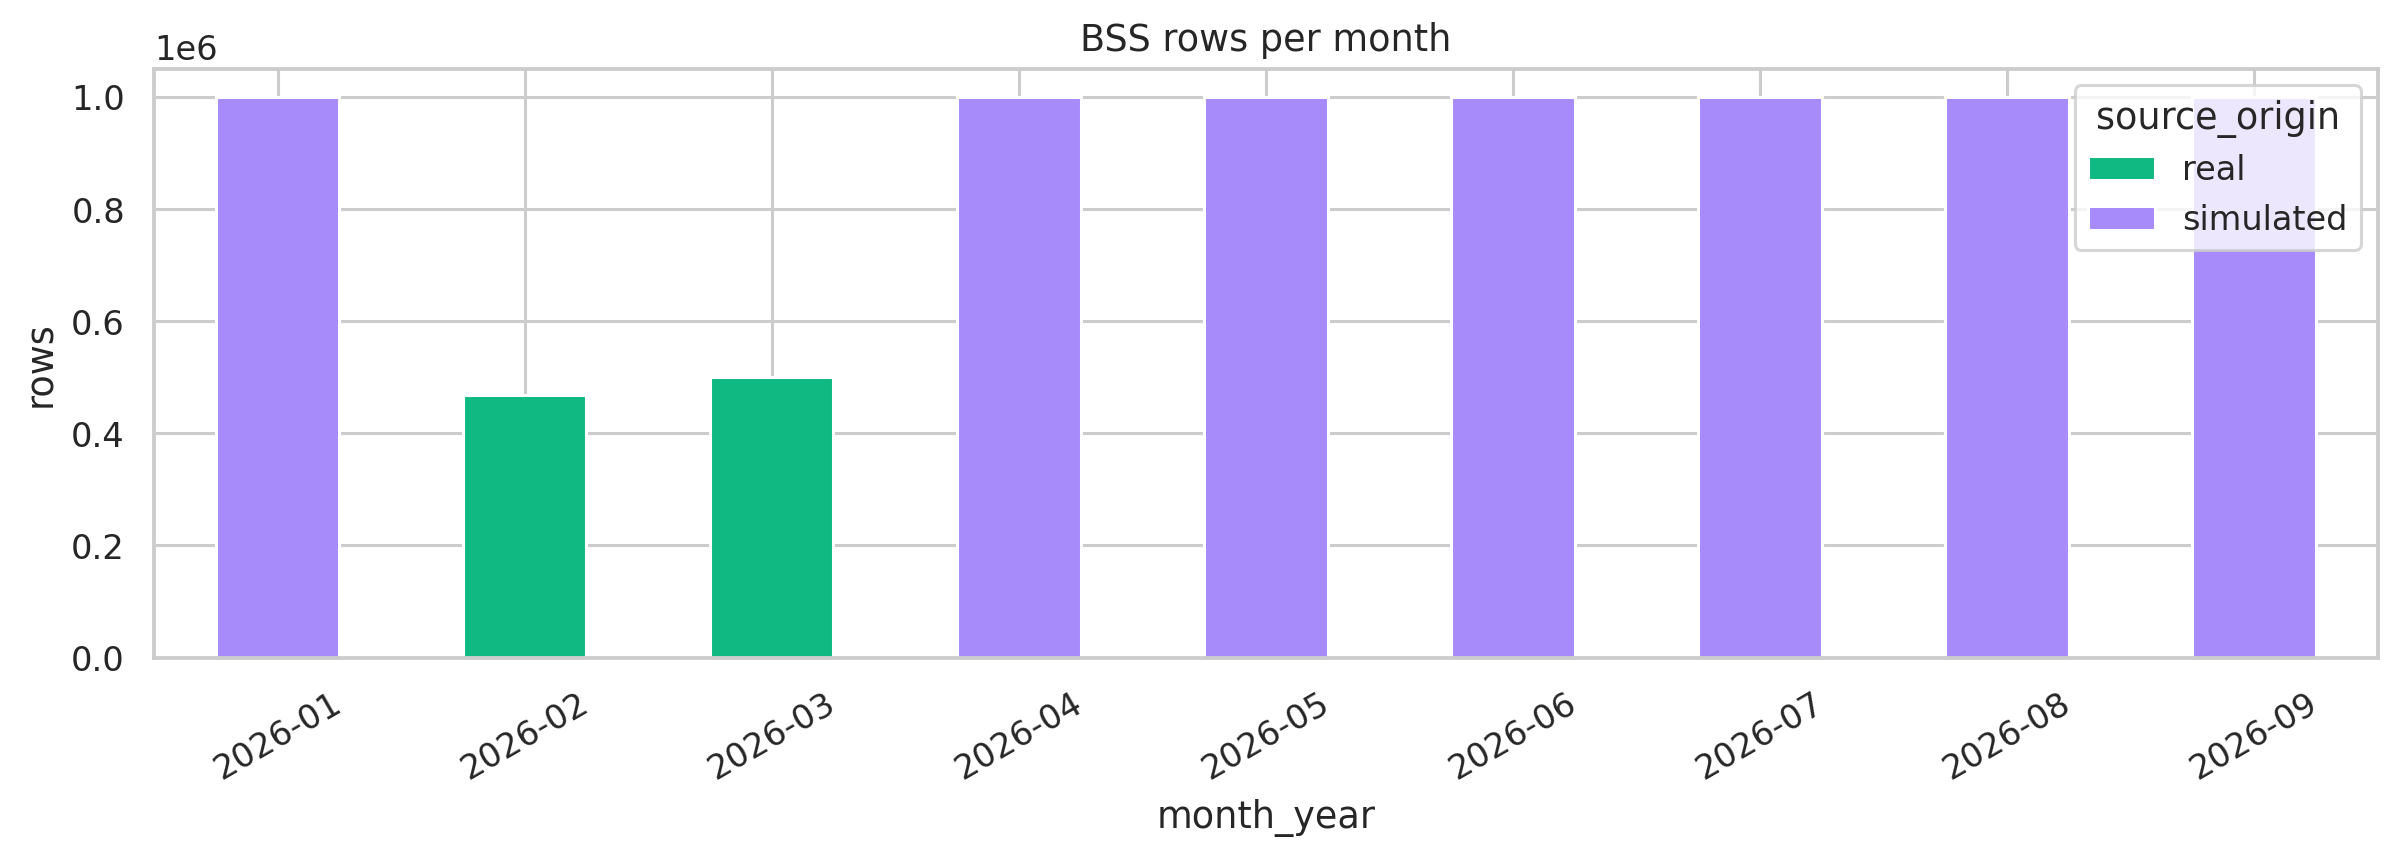

In [6]:
mo = df_bss.groupby(['month_year','source_origin']).size().unstack(fill_value=0)
print(mo)
fig, ax = plt.subplots(figsize=(11,4))
mo.plot(kind='bar', stacked=True, ax=ax, color=['#10b981','#a78bfa'])
ax.set_title('BSS rows per month'); ax.set_ylabel('rows')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

## 6 · BSS numeric summary statistics

In [7]:
display(df_bss.describe().T.round(2))


,count,mean,std,min,25%,50%,75%,max
volte_flag,3584437.0,1.400000e-01,3.400000e-01,0.0,0.0,0.0,0.000000e+00,1.000000e+00
usim_flag,7968077.0,7.500000e-01,4.300000e-01,0.0,0.0,1.0,1.000000e+00,1.000000e+00
dou_total,7968077.0,1.547187e+10,7.947388e+10,0.0,0.0,40163099.0,7.283803e+09,5.838006e+12
traffic_2g,7968077.0,5.293132e+06,5.847068e+07,0.0,0.0,0.0,3.588940e+05,2.195698e+10
traffic_3g,7968077.0,4.513873e+08,2.861479e+09,0.0,0.0,607668.0,1.027603e+08,3.696560e+11
traffic_4g,7968077.0,7.359008e+09,3.675503e+10,0.0,0.0,6554012.0,3.746440e+09,3.755375e+12
traffic_5g,7968077.0,5.259074e+09,6.815902e+10,0.0,0.0,0.0,2.594000e+03,6.339028e+12
duration,7968077.0,9.931620e+03,2.156159e+04,0.0,52.0,2157.0,9.976000e+03,5.827340e+05
voice_onlinetime_3g,7968077.0,8.088090e+03,2.046983e+04,0.0,0.0,306.0,6.569000e+03,6.155220e+05
voice_onlinetime_2g,7968077.0,1.843240e+03,7.835410e+03,0.0,0.0,0.0,2.220000e+02,5.210020e+05


## 7 · BSS missingness — per-column NaN%

In [8]:
nan_pct = (df_bss.isna().mean()*100).round(2).sort_values(ascending=False)
print('Non-zero NaN columns:')
print(nan_pct[nan_pct>0])

Non-zero NaN columns:
sim_slot           60.83
churned            56.07
volte_flag         55.02
area_delegation     5.22
area                4.51
generation          4.39
tertype             4.39
brand               4.39
model               4.39
tac                 2.45
dtype: float64


## 8 · BSS missingness — visual heatmap

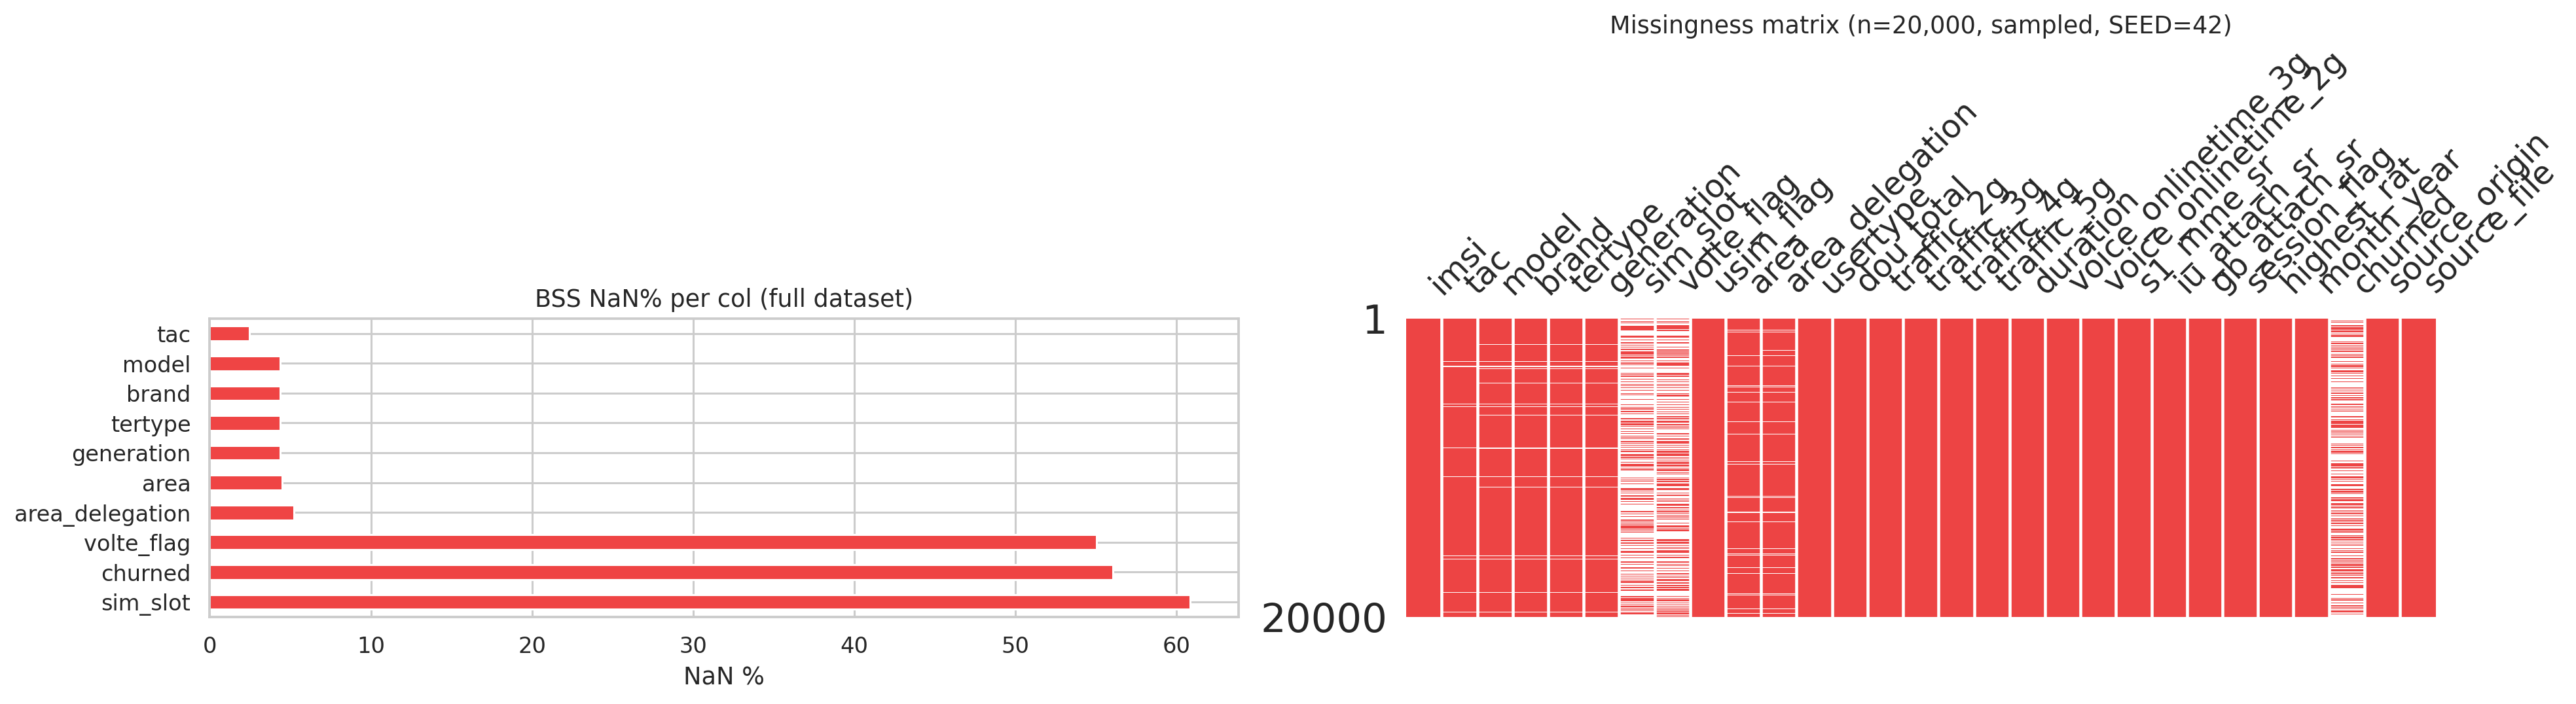

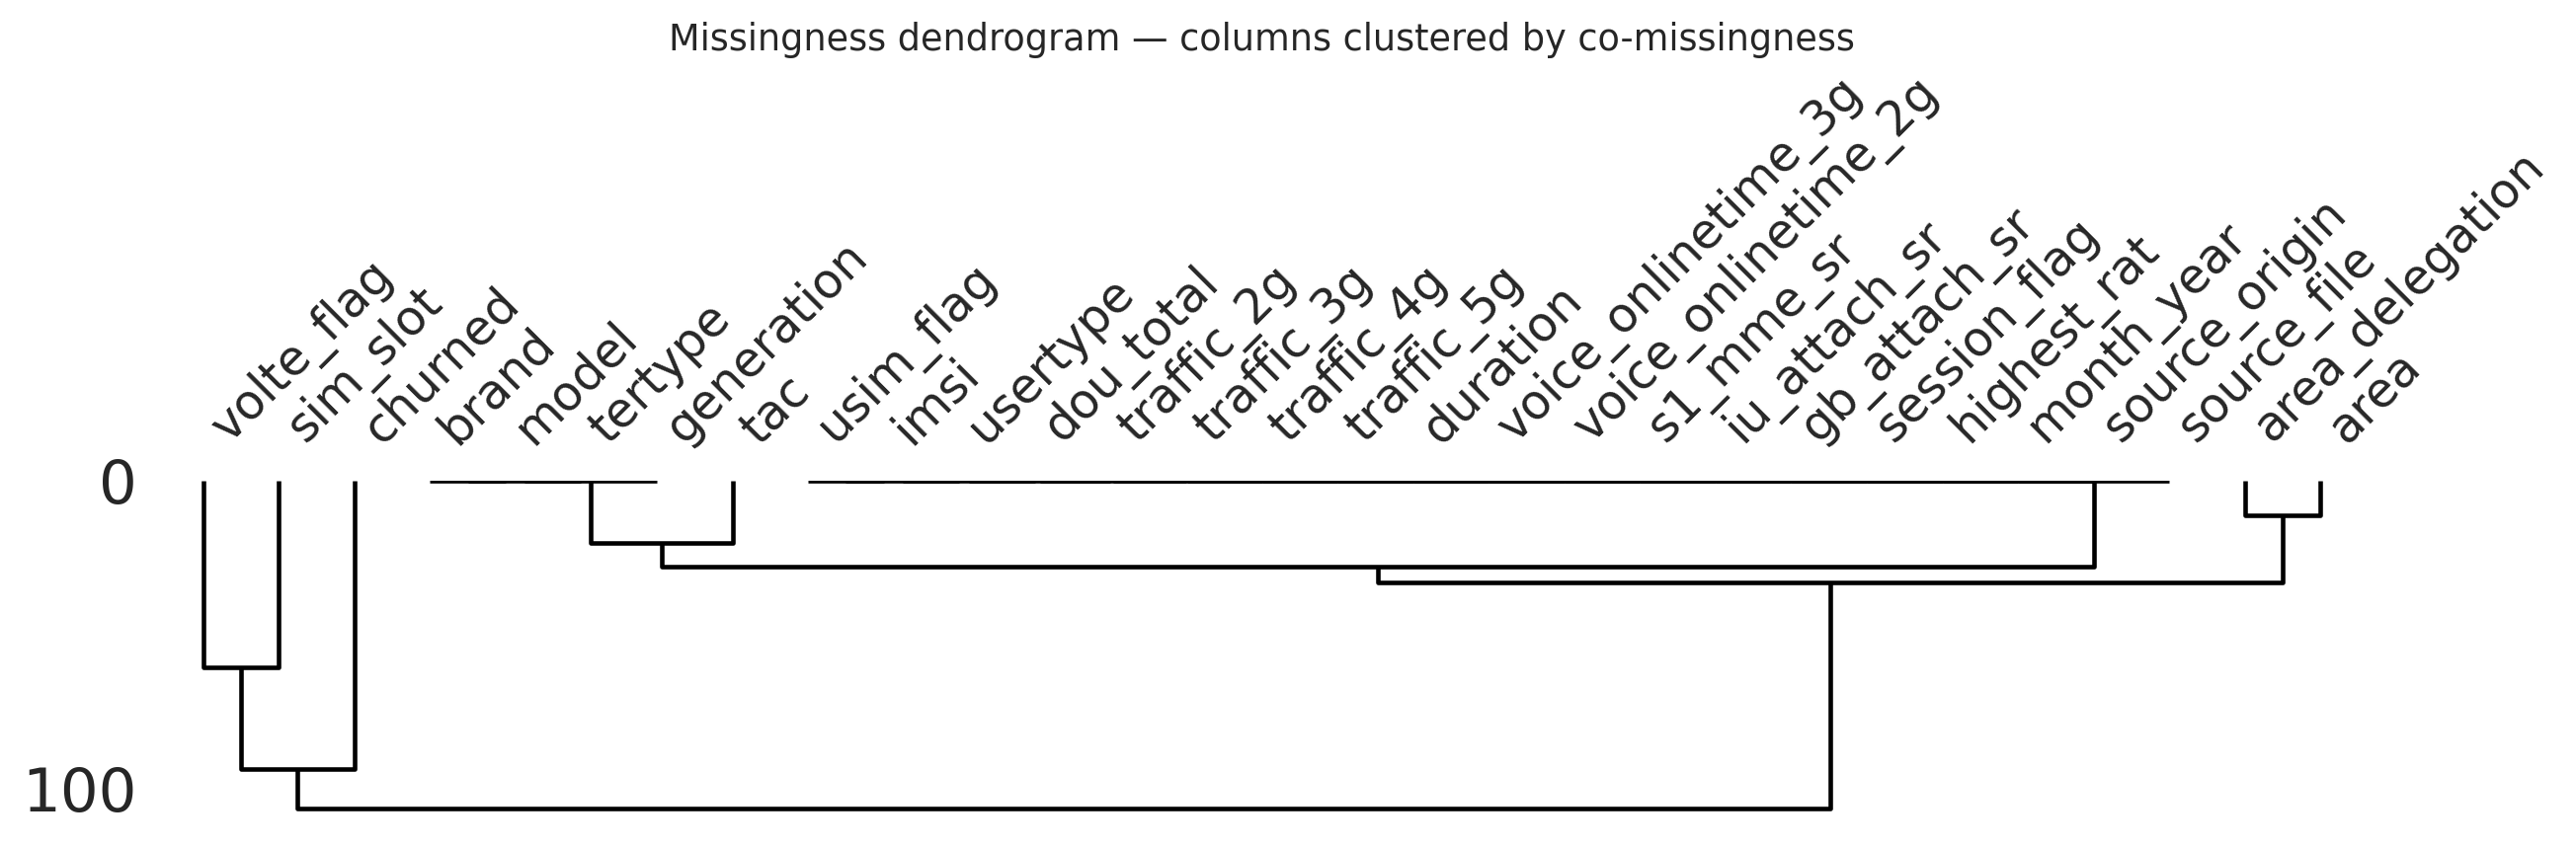

In [9]:
# --- Best-of-best missingness diagnostics (ResidentMario/missingno) ---
# Refs:
#   - https://github.com/ResidentMario/missingno
#   - Little RJA, Rubin DB. Statistical Analysis with Missing Data. Wiley 2002.
# Tools:
#   - msno.bar       — completion count per column
#   - msno.matrix    — row-wise sparkline (reveals block-structured missingness)
#   - msno.dendrogram— hierarchical clustering of co-missingness (reveals MAR groups)
# Sample: 20K rows (deterministic via SEED) to keep render time bounded.

SAMPLE_N_FOR_MISSINGNESS = 20_000
sample = df_bss.sample(n=min(SAMPLE_N_FOR_MISSINGNESS, len(df_bss)), random_state=SEED)

if HAVE_MSNO:
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    nan_pct[nan_pct > 0].plot(kind='barh', ax=axes[0], color='#ef4444')
    axes[0].set_xlabel('NaN %'); axes[0].set_title('BSS NaN% per col (full dataset)')
    msno.matrix(sample, ax=axes[1], color=(0.93, 0.27, 0.27), sparkline=False)
    axes[1].set_title(f'Missingness matrix (n={len(sample):,}, sampled, SEED={SEED})')
    plt.tight_layout(); plt.show()

    # Dendrogram — reveals which columns are MISSING TOGETHER (potential MAR mechanism)
    fig, ax = plt.subplots(figsize=(12, 4))
    msno.dendrogram(sample, ax=ax)
    ax.set_title('Missingness dendrogram — columns clustered by co-missingness')
    plt.tight_layout(); plt.show()
else:
    # Fallback to seaborn heatmap if missingno unavailable
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    nan_pct[nan_pct > 0].plot(kind='barh', ax=axes[0], color='#ef4444')
    axes[0].set_xlabel('NaN %'); axes[0].set_title('BSS NaN% per col')
    sns.heatmap(sample.isna(), cbar=False, ax=axes[1], cmap='rocket_r')
    axes[1].set_title(f'Missingness matrix ({len(sample):,} sampled rows, SEED={SEED})')
    plt.tight_layout(); plt.show()

## 9 · BSS numeric distributions — full grid

Histogram + KDE for every numeric column. `log1p` for heavy-tailed columns.

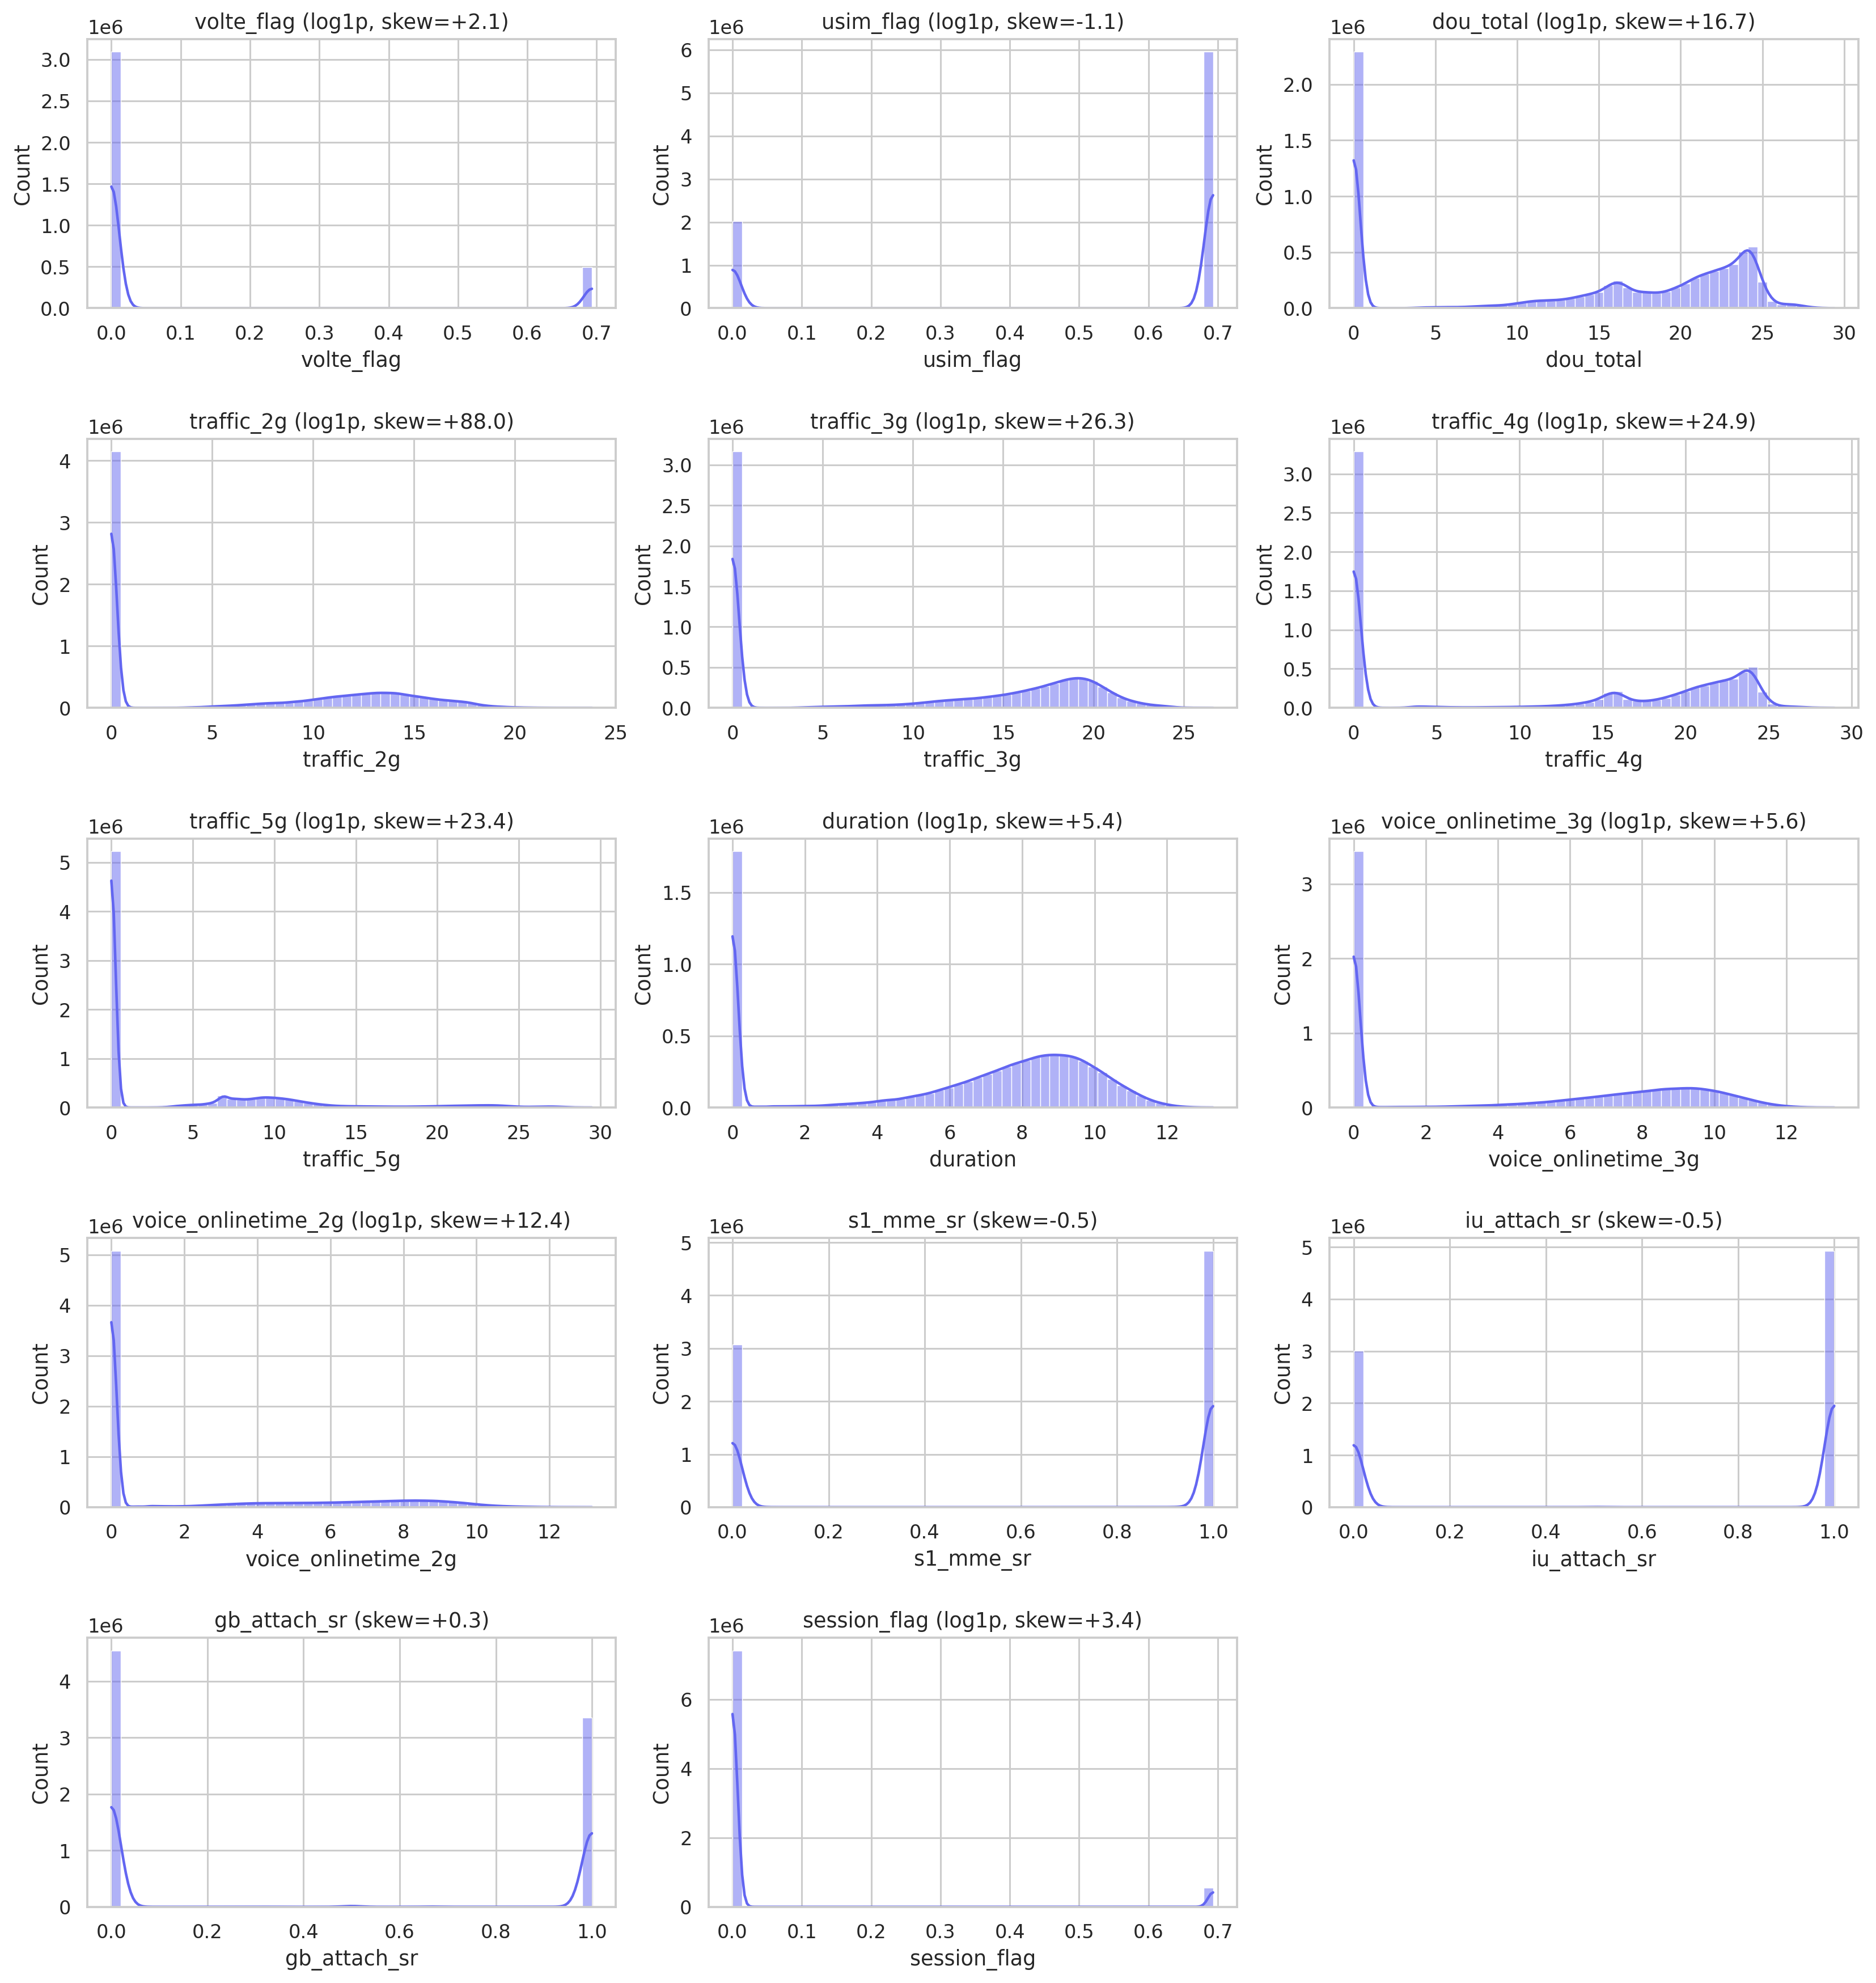

,skew,log1p_applied
traffic_2g,88.01,True
traffic_3g,26.3,True
traffic_4g,24.93,True
traffic_5g,23.41,True
dou_total,16.69,True
voice_onlinetime_2g,12.42,True
voice_onlinetime_3g,5.64,True
duration,5.37,True
session_flag,3.38,True
volte_flag,2.11,True


In [10]:
# Decide log1p per column via **skewness** (Fisher-Pearson) — not a magic ratio.
# Rule: if abs(skew) > LOG1P_SKEW_THRESHOLD and column is non-negative, plot on log1p axis.
# Threshold 1.0 is the standard cutoff for "highly skewed" (Bulmer 1979, Principles of Statistics).
LOG1P_SKEW_THRESHOLD = 1.0

num_cols = df_bss.select_dtypes(include='number').columns.tolist()
ncols = 3
nrows = (len(num_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows))

skew_decisions = {}
for ax, col in zip(axes.flat, num_cols):
    s = df_bss[col].dropna().astype(float)
    if s.empty:
        ax.axis('off'); continue
    skew = float(stats.skew(s)) if len(s) > 1 else 0.0
    use_log = (s.min() >= 0) and (abs(skew) > LOG1P_SKEW_THRESHOLD)
    skew_decisions[col] = (round(skew, 2), use_log)
    if use_log:
        sns.histplot(np.log1p(s), bins=50, kde=True, ax=ax, color='#6366f1')
        ax.set_title(f'{col} (log1p, skew={skew:+.1f})')
    else:
        sns.histplot(s, bins=50, kde=True, ax=ax, color='#6366f1')
        ax.set_title(f'{col} (skew={skew:+.1f})')

for ax in axes.flat[len(num_cols):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

# Audit table: skewness + transform decision per column
skew_df = pd.DataFrame(skew_decisions, index=['skew', 'log1p_applied']).T
skew_df['log1p_applied'] = skew_df['log1p_applied'].astype(bool)
display(skew_df.sort_values('skew', key=lambda s: s.abs(), ascending=False))

## 10 · Real vs simulated overlay (KDE)

Check that bootstrap simulator stays close to real distribution (with intentional drift).

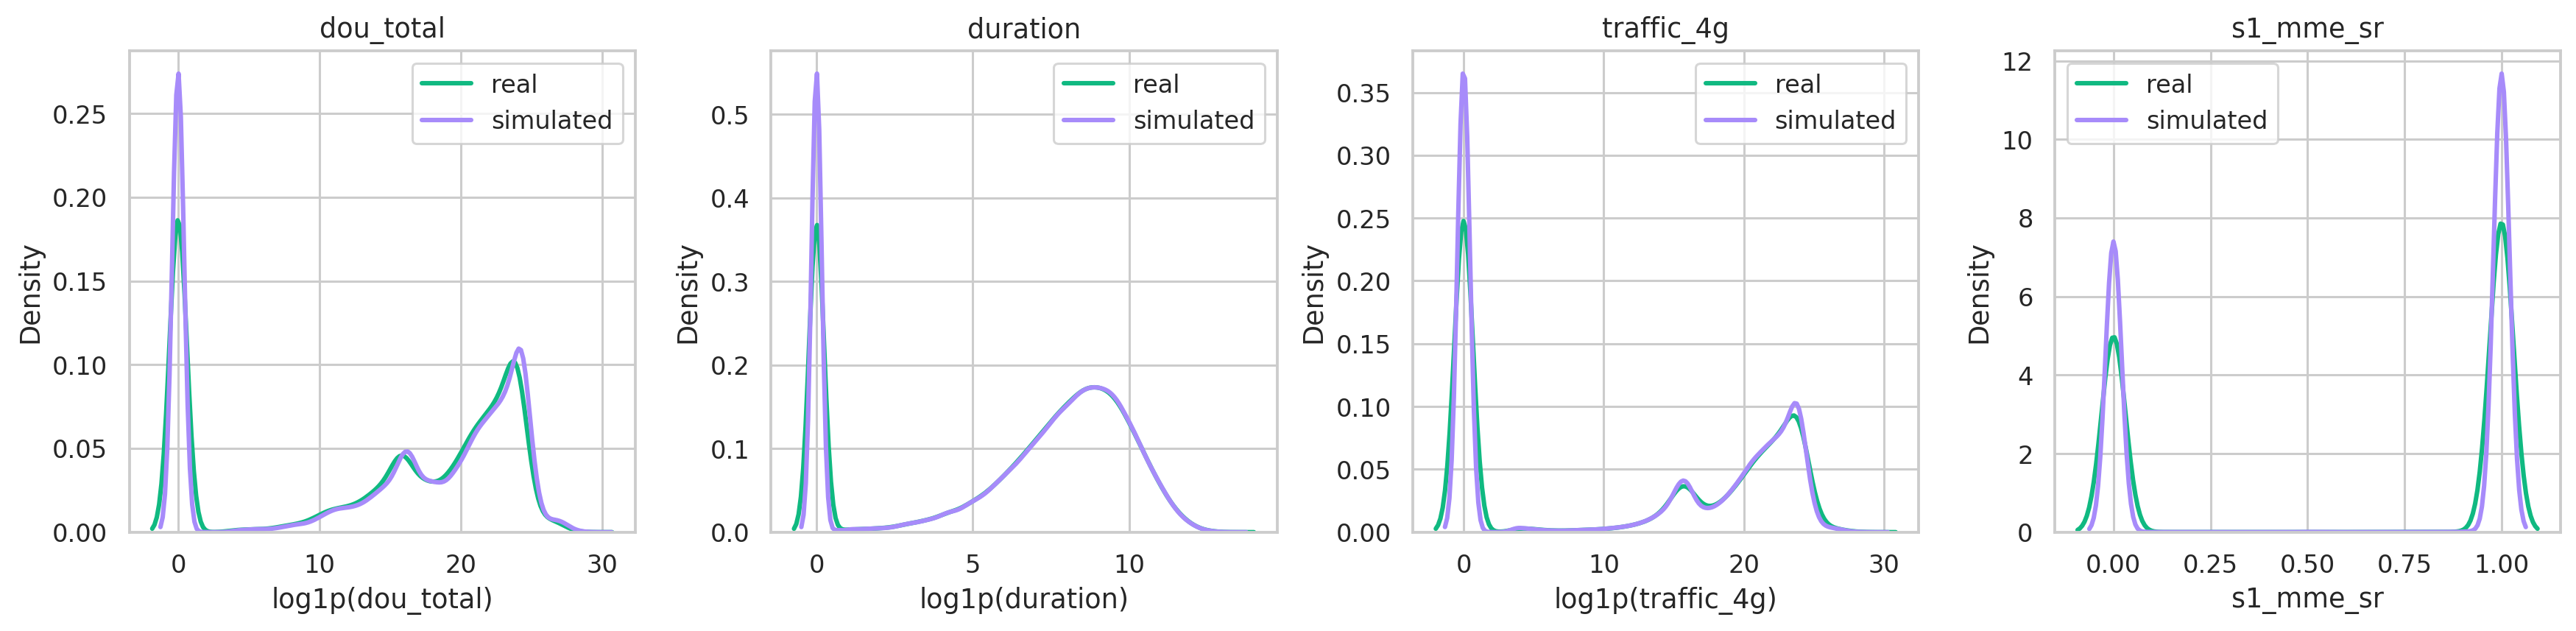

In [11]:
compare = [c for c in ['dou_total','duration','traffic_4g','s1_mme_sr'] if c in df_bss.columns]
fig, axes = plt.subplots(1,len(compare),figsize=(4*len(compare),4))
for ax, col in zip(axes, compare):
    r = df_bss.loc[df_bss.source_origin=='real', col].dropna()
    s = df_bss.loc[df_bss.source_origin=='simulated', col].dropna()
    if r.empty or s.empty: continue
    if col in ('dou_total','duration','traffic_4g'):
        sns.kdeplot(np.log1p(r), label='real', ax=ax, color='#10b981', linewidth=2)
        sns.kdeplot(np.log1p(s), label='simulated', ax=ax, color='#a78bfa', linewidth=2)
        ax.set_xlabel(f'log1p({col})')
    else:
        sns.kdeplot(r, label='real', ax=ax, color='#10b981', linewidth=2)
        sns.kdeplot(s, label='simulated', ax=ax, color='#a78bfa', linewidth=2)
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

## 11 · BSS categorical distributions

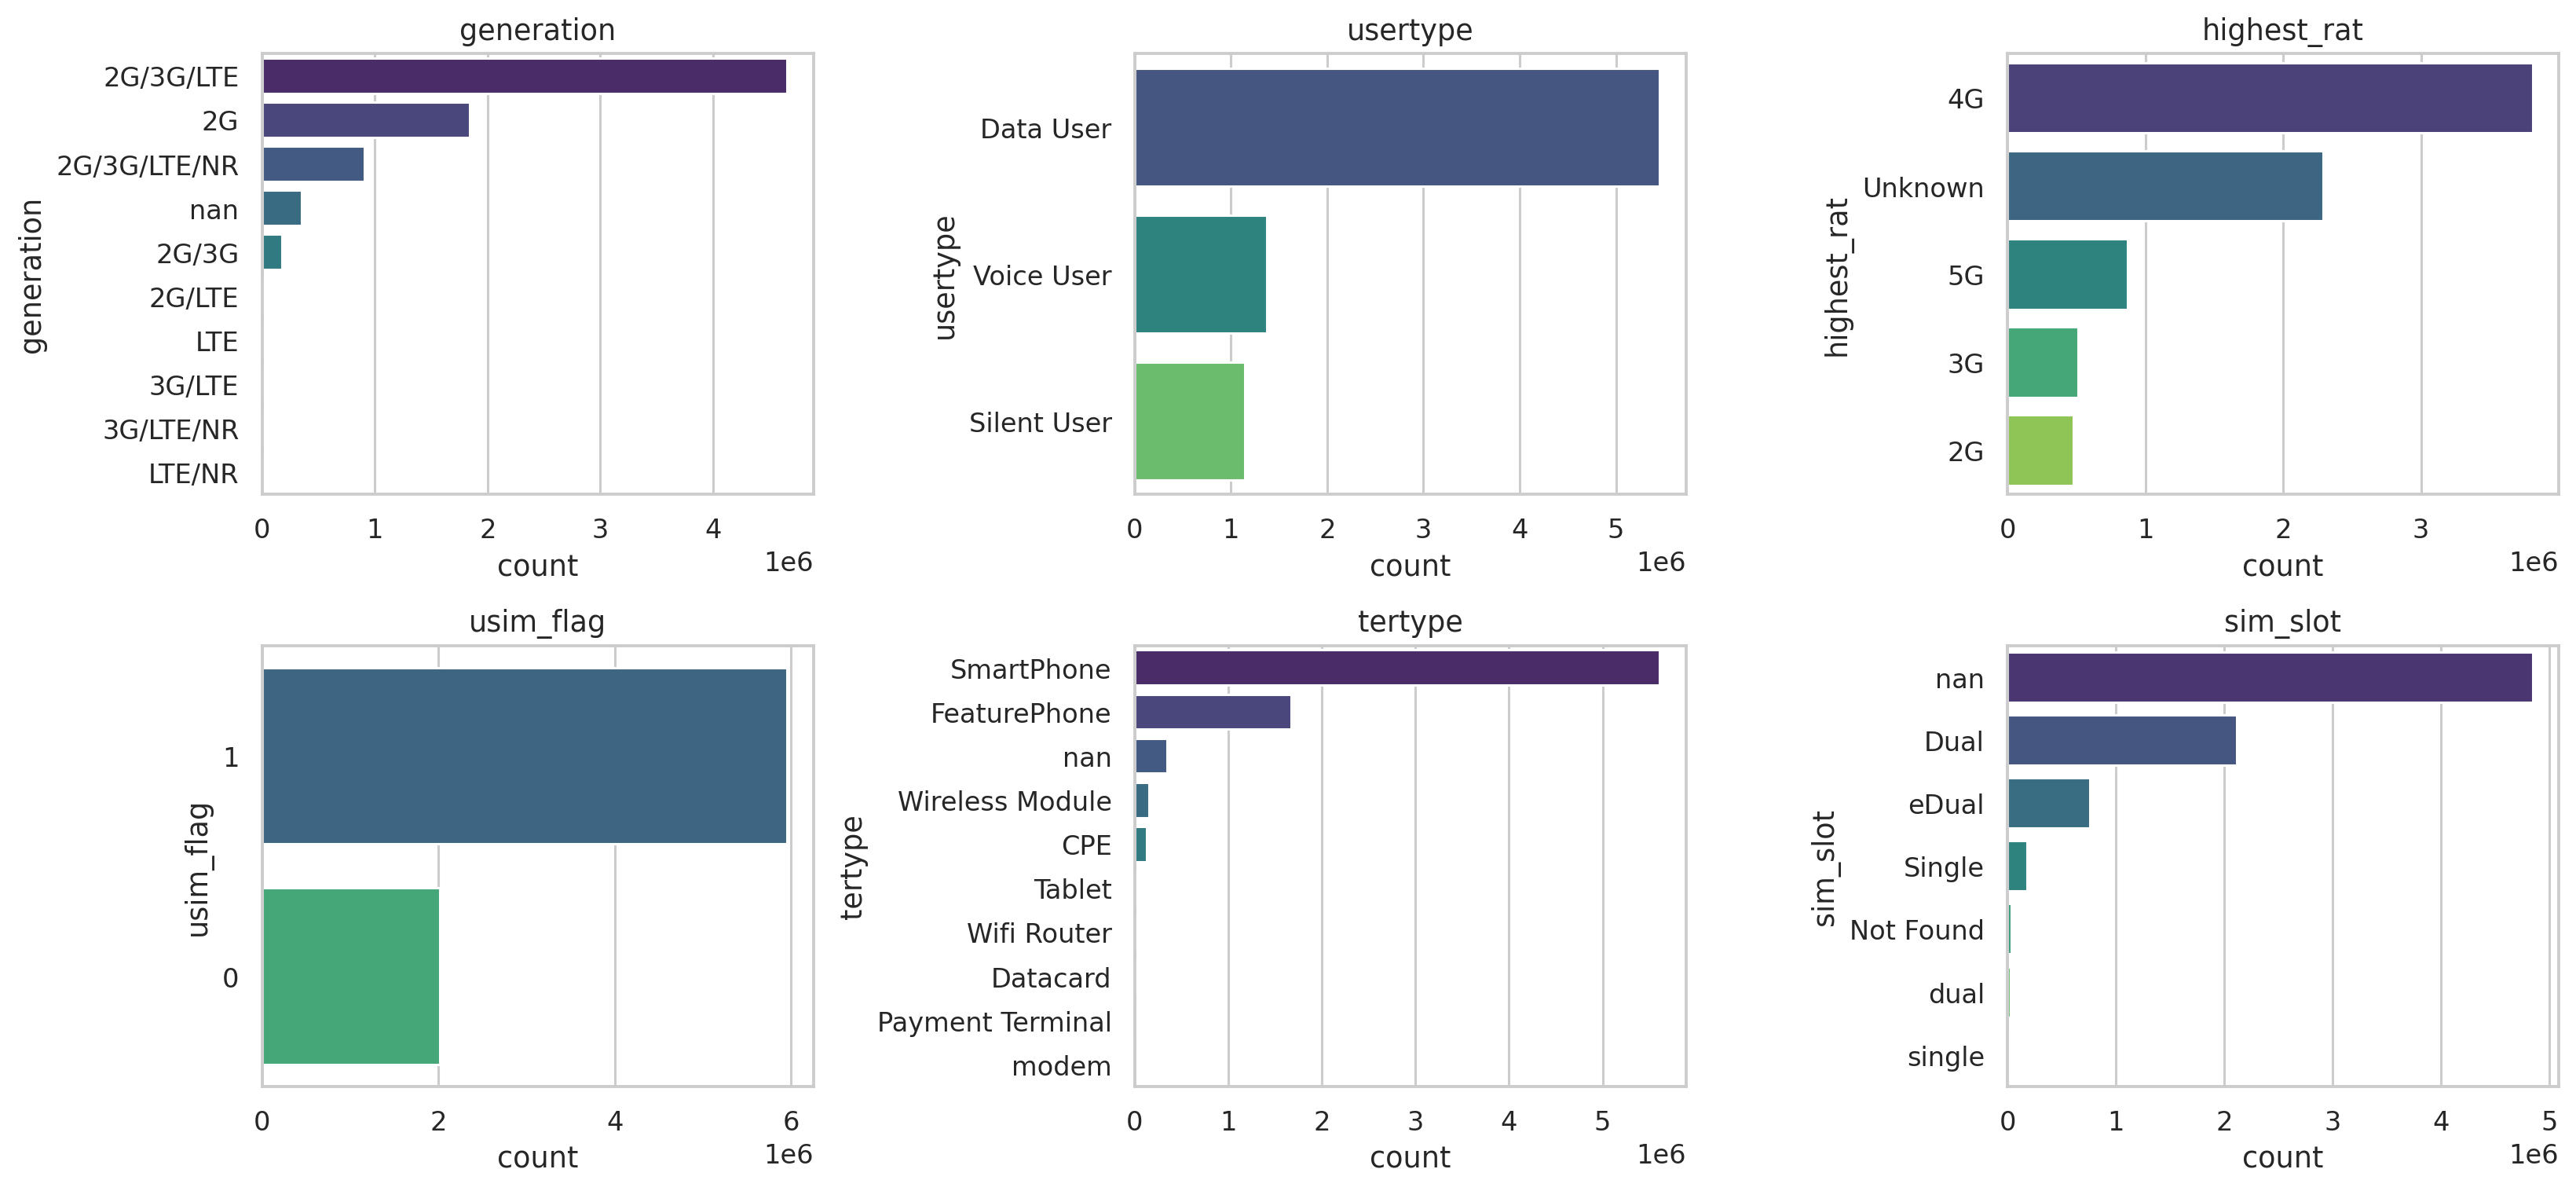

In [12]:
cat_cols = [c for c in ['generation','usertype','highest_rat','usim_flag','tertype','sim_slot'] if c in df_bss.columns]
ncols=3; nrows=(len(cat_cols)+ncols-1)//ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5*nrows))
for ax, col in zip(axes.flat, cat_cols):
    cnt = df_bss[col].astype(str).value_counts().head(10)
    sns.barplot(x=cnt.values, y=cnt.index, ax=ax, palette='viridis', orient='h')
    ax.set_title(col); ax.set_xlabel('count')
for ax in axes.flat[len(cat_cols):]: ax.axis('off')
plt.tight_layout(); plt.show()

## 12 · BSS outlier visualization (no fixes — info only)

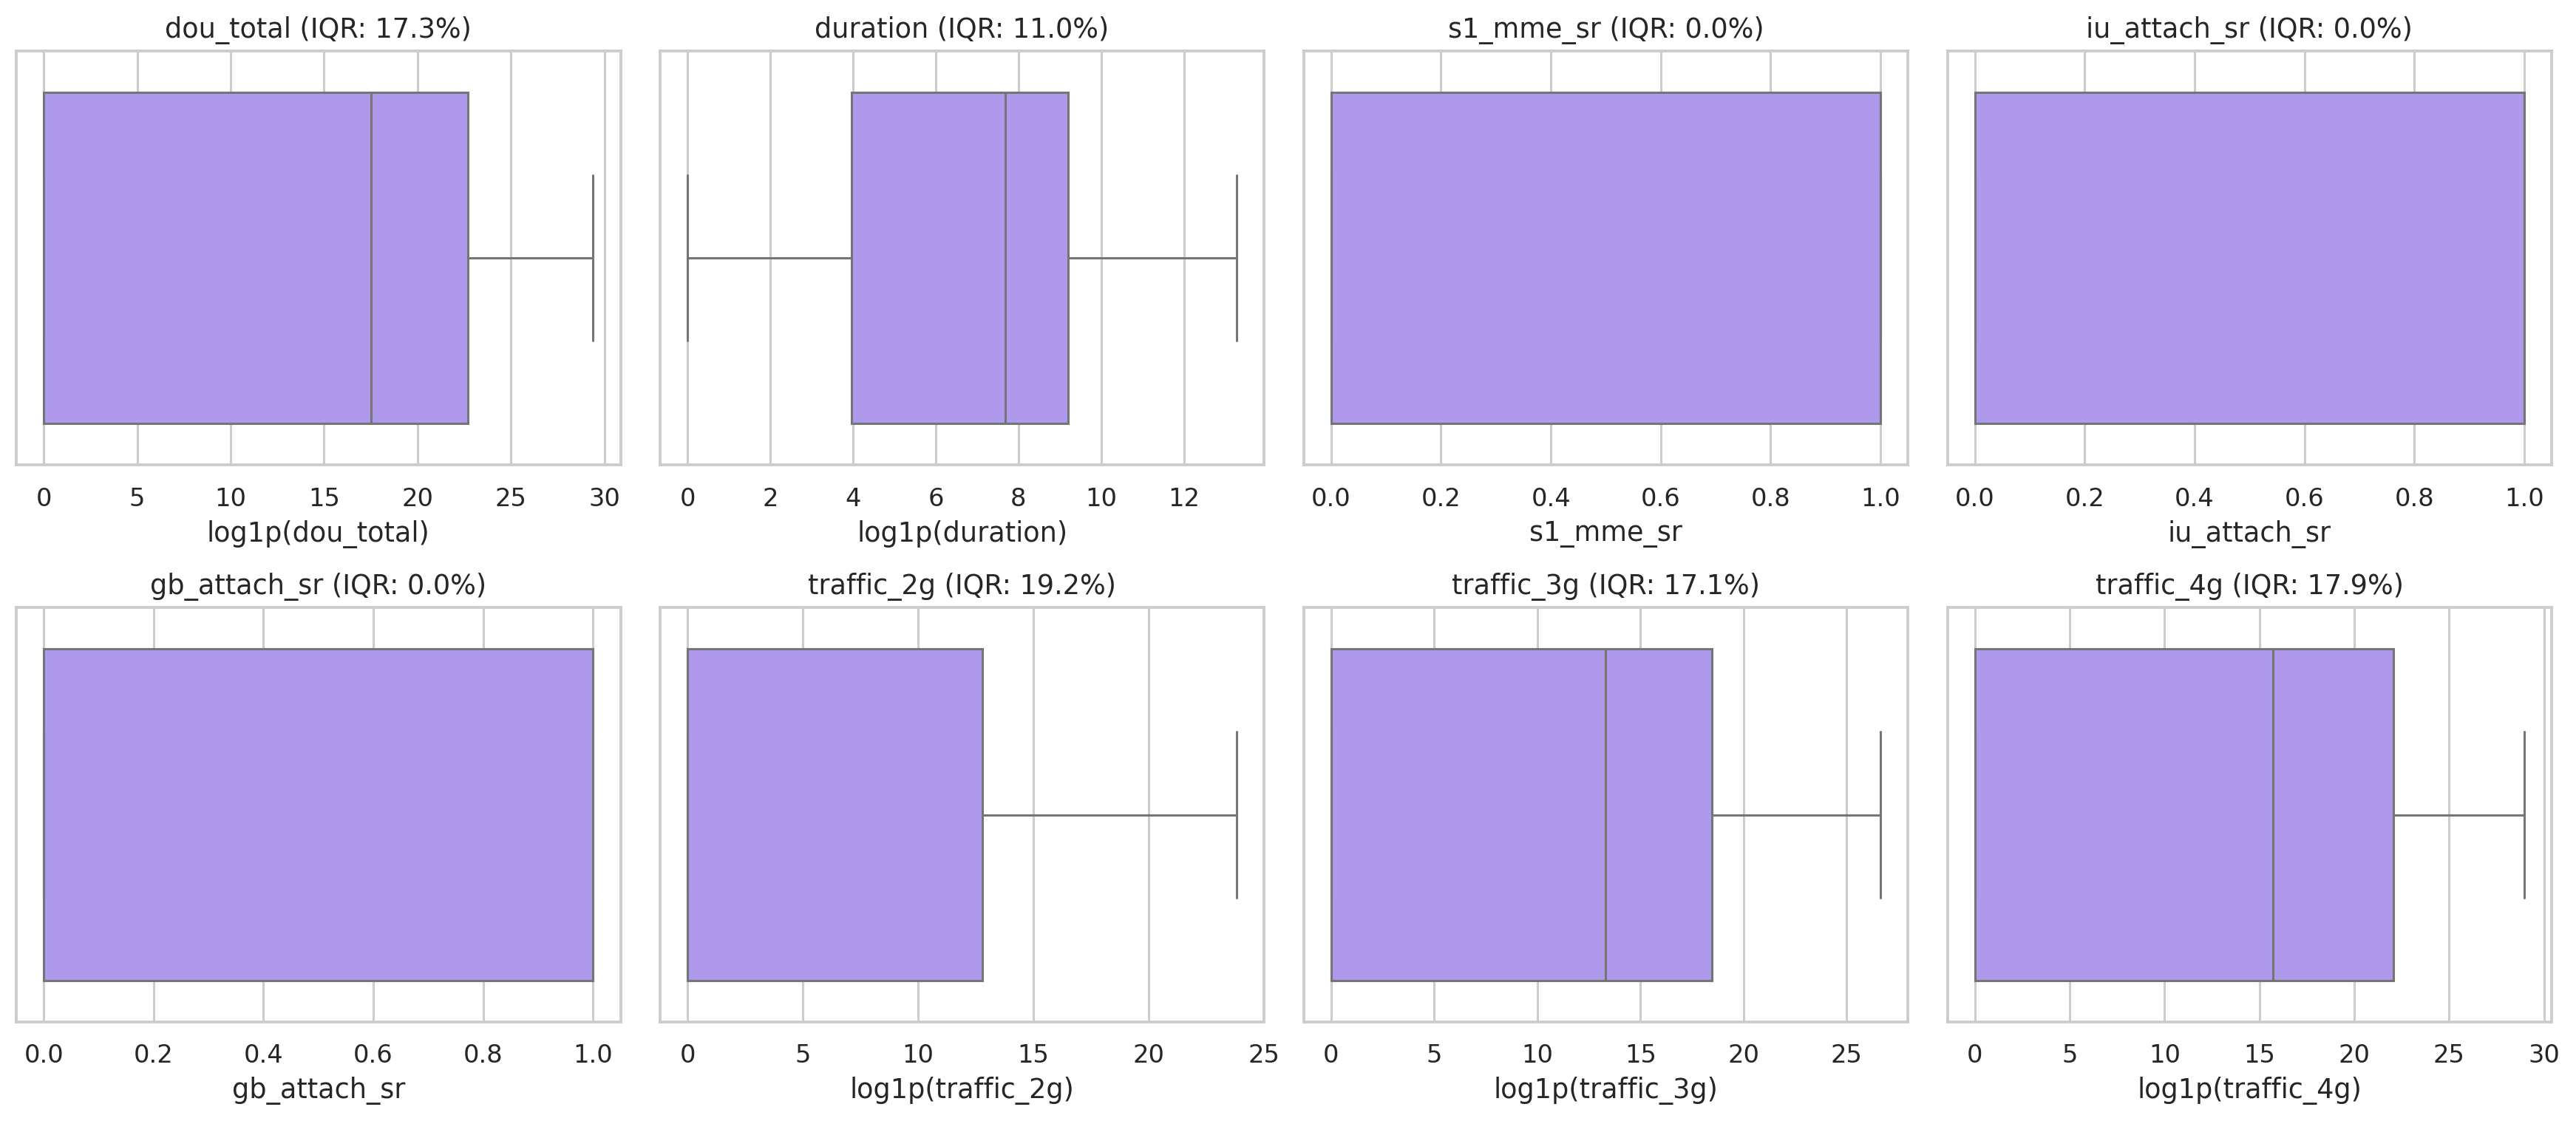

In [13]:
iqr_cols = [c for c in ['dou_total','duration','s1_mme_sr','iu_attach_sr','gb_attach_sr',
                        'traffic_2g','traffic_3g','traffic_4g'] if c in df_bss.columns]
fig, axes = plt.subplots(2,4,figsize=(16,7))
for ax, col in zip(axes.flat, iqr_cols):
    s = df_bss[col].dropna().astype(float)
    if col.startswith('traffic') or col in ('dou_total','duration'):
        sns.boxplot(x=np.log1p(s), ax=ax, color='#a78bfa')
        ax.set_xlabel(f'log1p({col})')
    else:
        sns.boxplot(x=s, ax=ax, color='#a78bfa')
        ax.set_xlabel(col)
    q1,q3 = s.quantile([0.25,0.75]); iqr=q3-q1
    out = ((s<q1-1.5*iqr)|(s>q3+1.5*iqr)).mean()*100
    ax.set_title(f'{col} (IQR: {out:.1f}%)')
for ax in axes.flat[len(iqr_cols):]: ax.axis('off')
plt.tight_layout(); plt.show()

## 12.5 · Violin plots + z-score outliers (distribution shape + symmetric rule)

Two views the box plots above don't give:
- **Violin plot** = box plot + mirrored KDE. The *width* shows where data is dense — it reveals multi-modal shapes (two humps) a box plot hides.
- **z-score rule** (|z| > 3) flags points more than 3 standard deviations from the mean — the *symmetric/Gaussian* outlier rule. The IQR/Tukey rule above is *robust to skew*. Comparing the two %% per column shows how much skew inflates the symmetric count.

,z>3 %,IQR %
column,,
dou_total,1.03,17.32
duration,2.12,11.03
s1_mme_sr,0.00,0.00
iu_attach_sr,0.00,0.00
gb_attach_sr,0.00,0.00
traffic_2g,0.47,19.18
traffic_3g,1.01,17.12
traffic_4g,0.62,17.92


z-score assumes a bell curve; on right-skewed traffic it under/over-counts vs the skew-robust IQR rule.


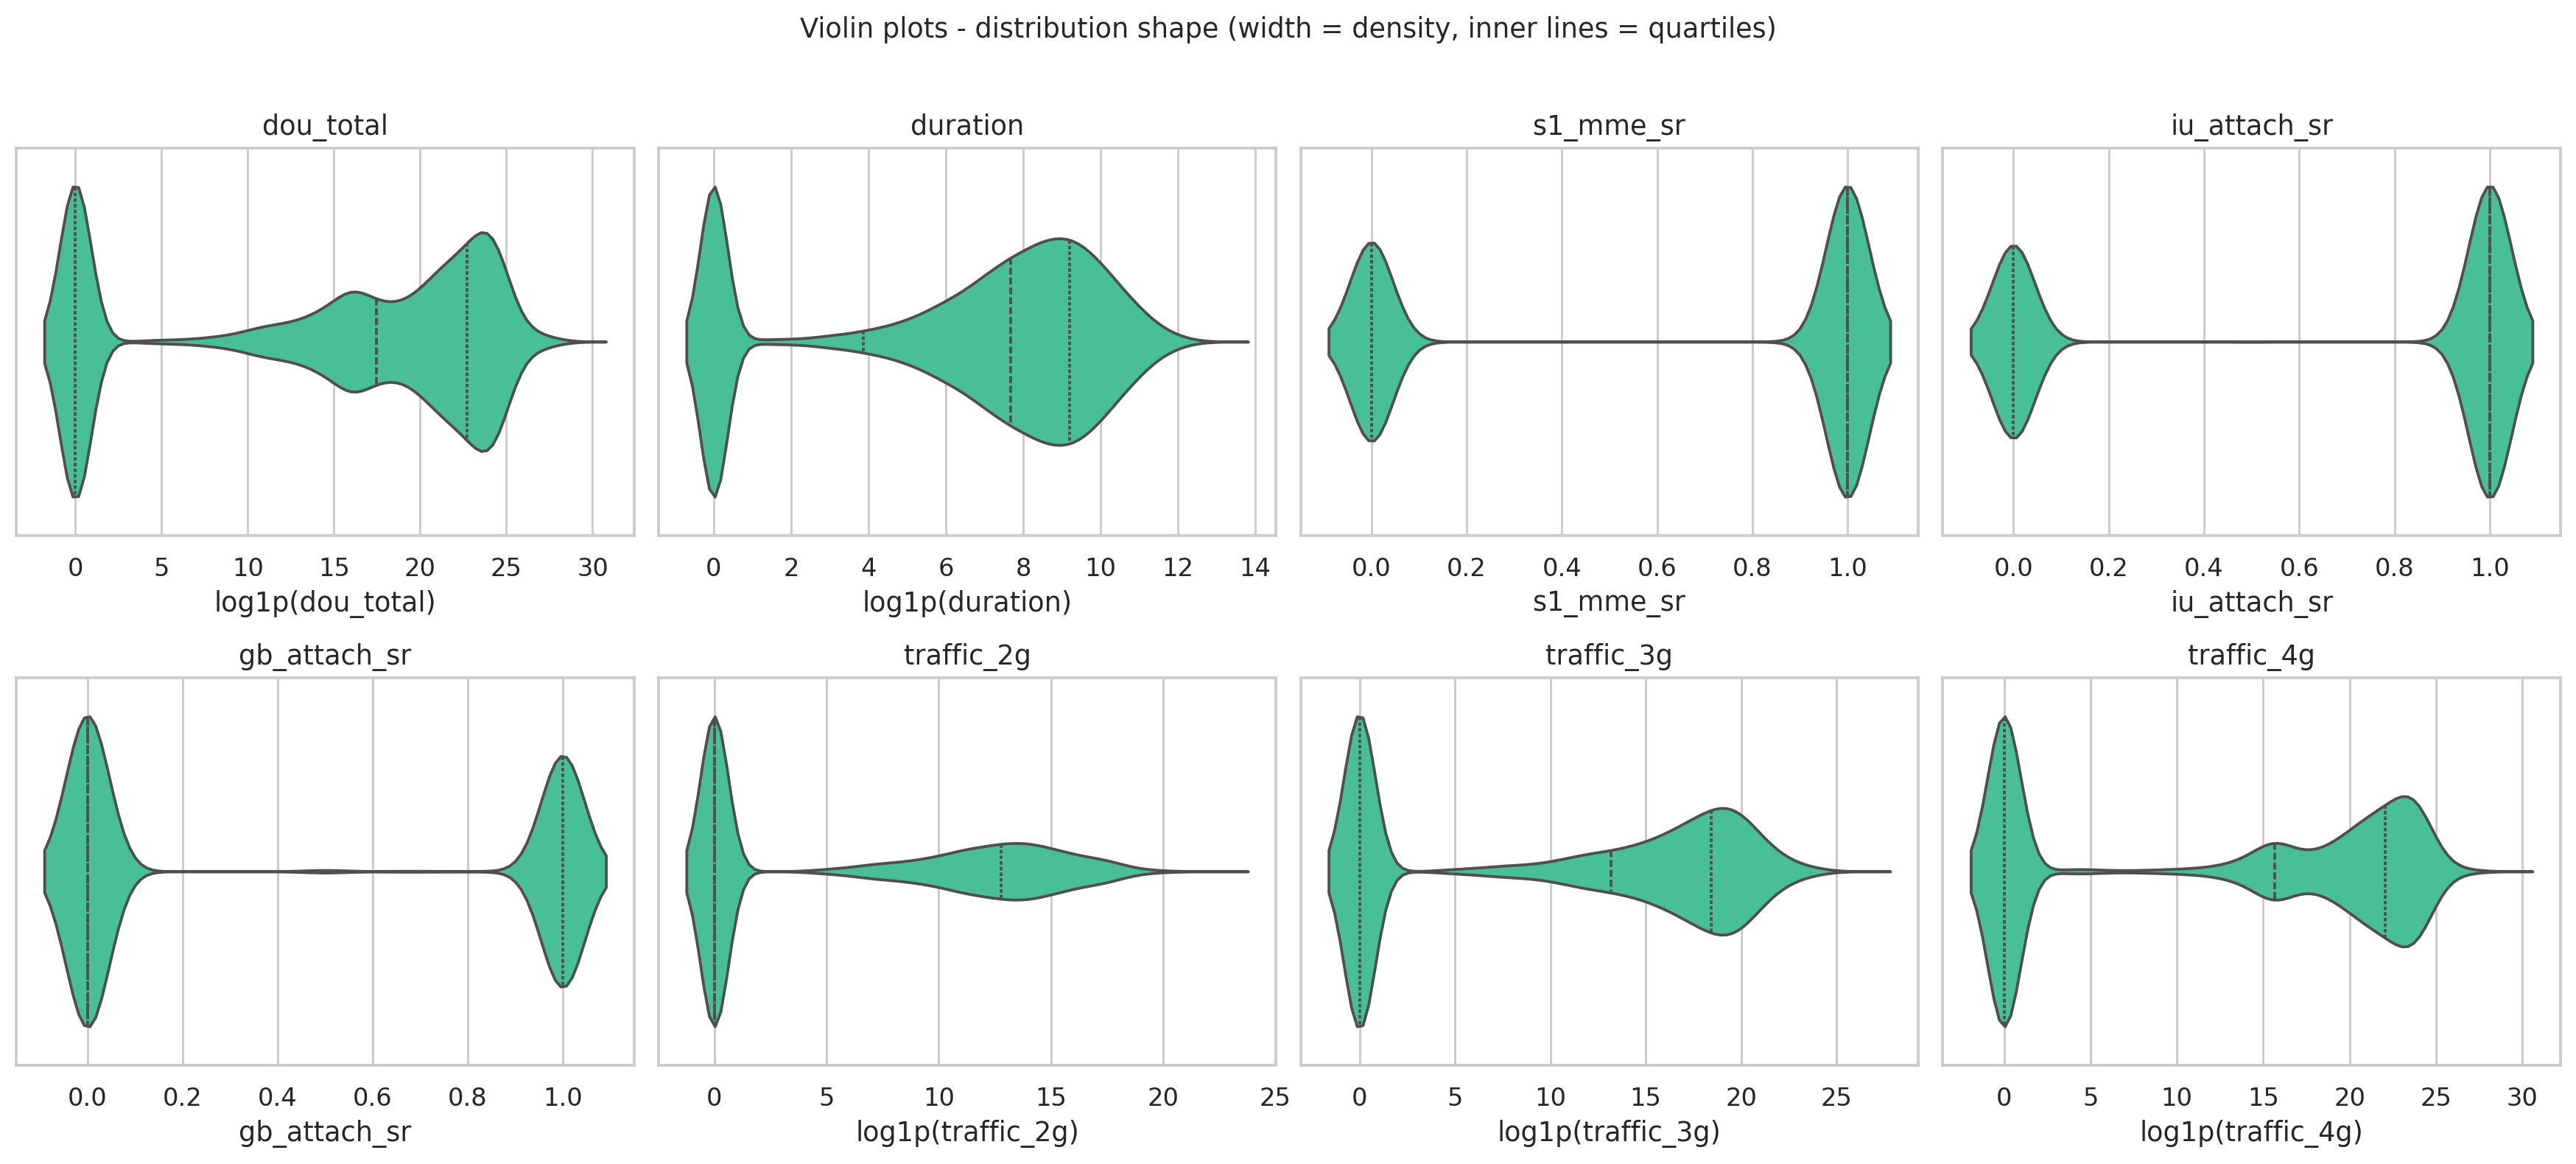

In [14]:
# Violin (full distribution shape) + z-score outlier rule (complements the IQR/Tukey box plots above).
# z-score % uses full column (mean/std are cheap); violins render on a sample for memory safety.
VIOLIN_SAMPLE_N = 150_000
zc_cols = [c for c in ['dou_total','duration','s1_mme_sr','iu_attach_sr','gb_attach_sr',
                       'traffic_2g','traffic_3g','traffic_4g'] if c in df_bss.columns]

# --- z-score (|z|>3, symmetric/Gaussian) vs IQR (robust to skew) side by side ---
zrows = []
for col in zc_cols:
    s = df_bss[col].dropna().astype(float)
    mu, sd = s.mean(), s.std()
    z_out = (((s - mu) / sd).abs() > 3).mean() * 100 if sd > 0 else 0.0
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    iqr_out = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).mean() * 100
    zrows.append({'column': col, 'z>3 %': round(z_out, 2), 'IQR %': round(iqr_out, 2)})
display(pd.DataFrame(zrows).set_index('column'))
print('z-score assumes a bell curve; on right-skewed traffic it under/over-counts vs the skew-robust IQR rule.')

# --- violin plots on a sample (width = density; reveals multi-modal shapes a box plot hides) ---
samp = df_bss[zc_cols].dropna(how='all')
if len(samp) > VIOLIN_SAMPLE_N:
    samp = samp.sample(VIOLIN_SAMPLE_N, random_state=SEED)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, zc_cols):
    s = samp[col].dropna().astype(float)
    if col.startswith('traffic') or col in ('dou_total', 'duration'):
        sns.violinplot(x=np.log1p(s), ax=ax, color='#34d399', inner='quartile')
        ax.set_xlabel(f'log1p({col})')
    else:
        sns.violinplot(x=s, ax=ax, color='#34d399', inner='quartile')
        ax.set_xlabel(col)
    ax.set_title(col)
for ax in axes.flat[len(zc_cols):]:
    ax.axis('off')
plt.suptitle('Violin plots - distribution shape (width = density, inner lines = quartiles)', y=1.02)
plt.tight_layout(); plt.show()

## 13 · BSS correlation matrix

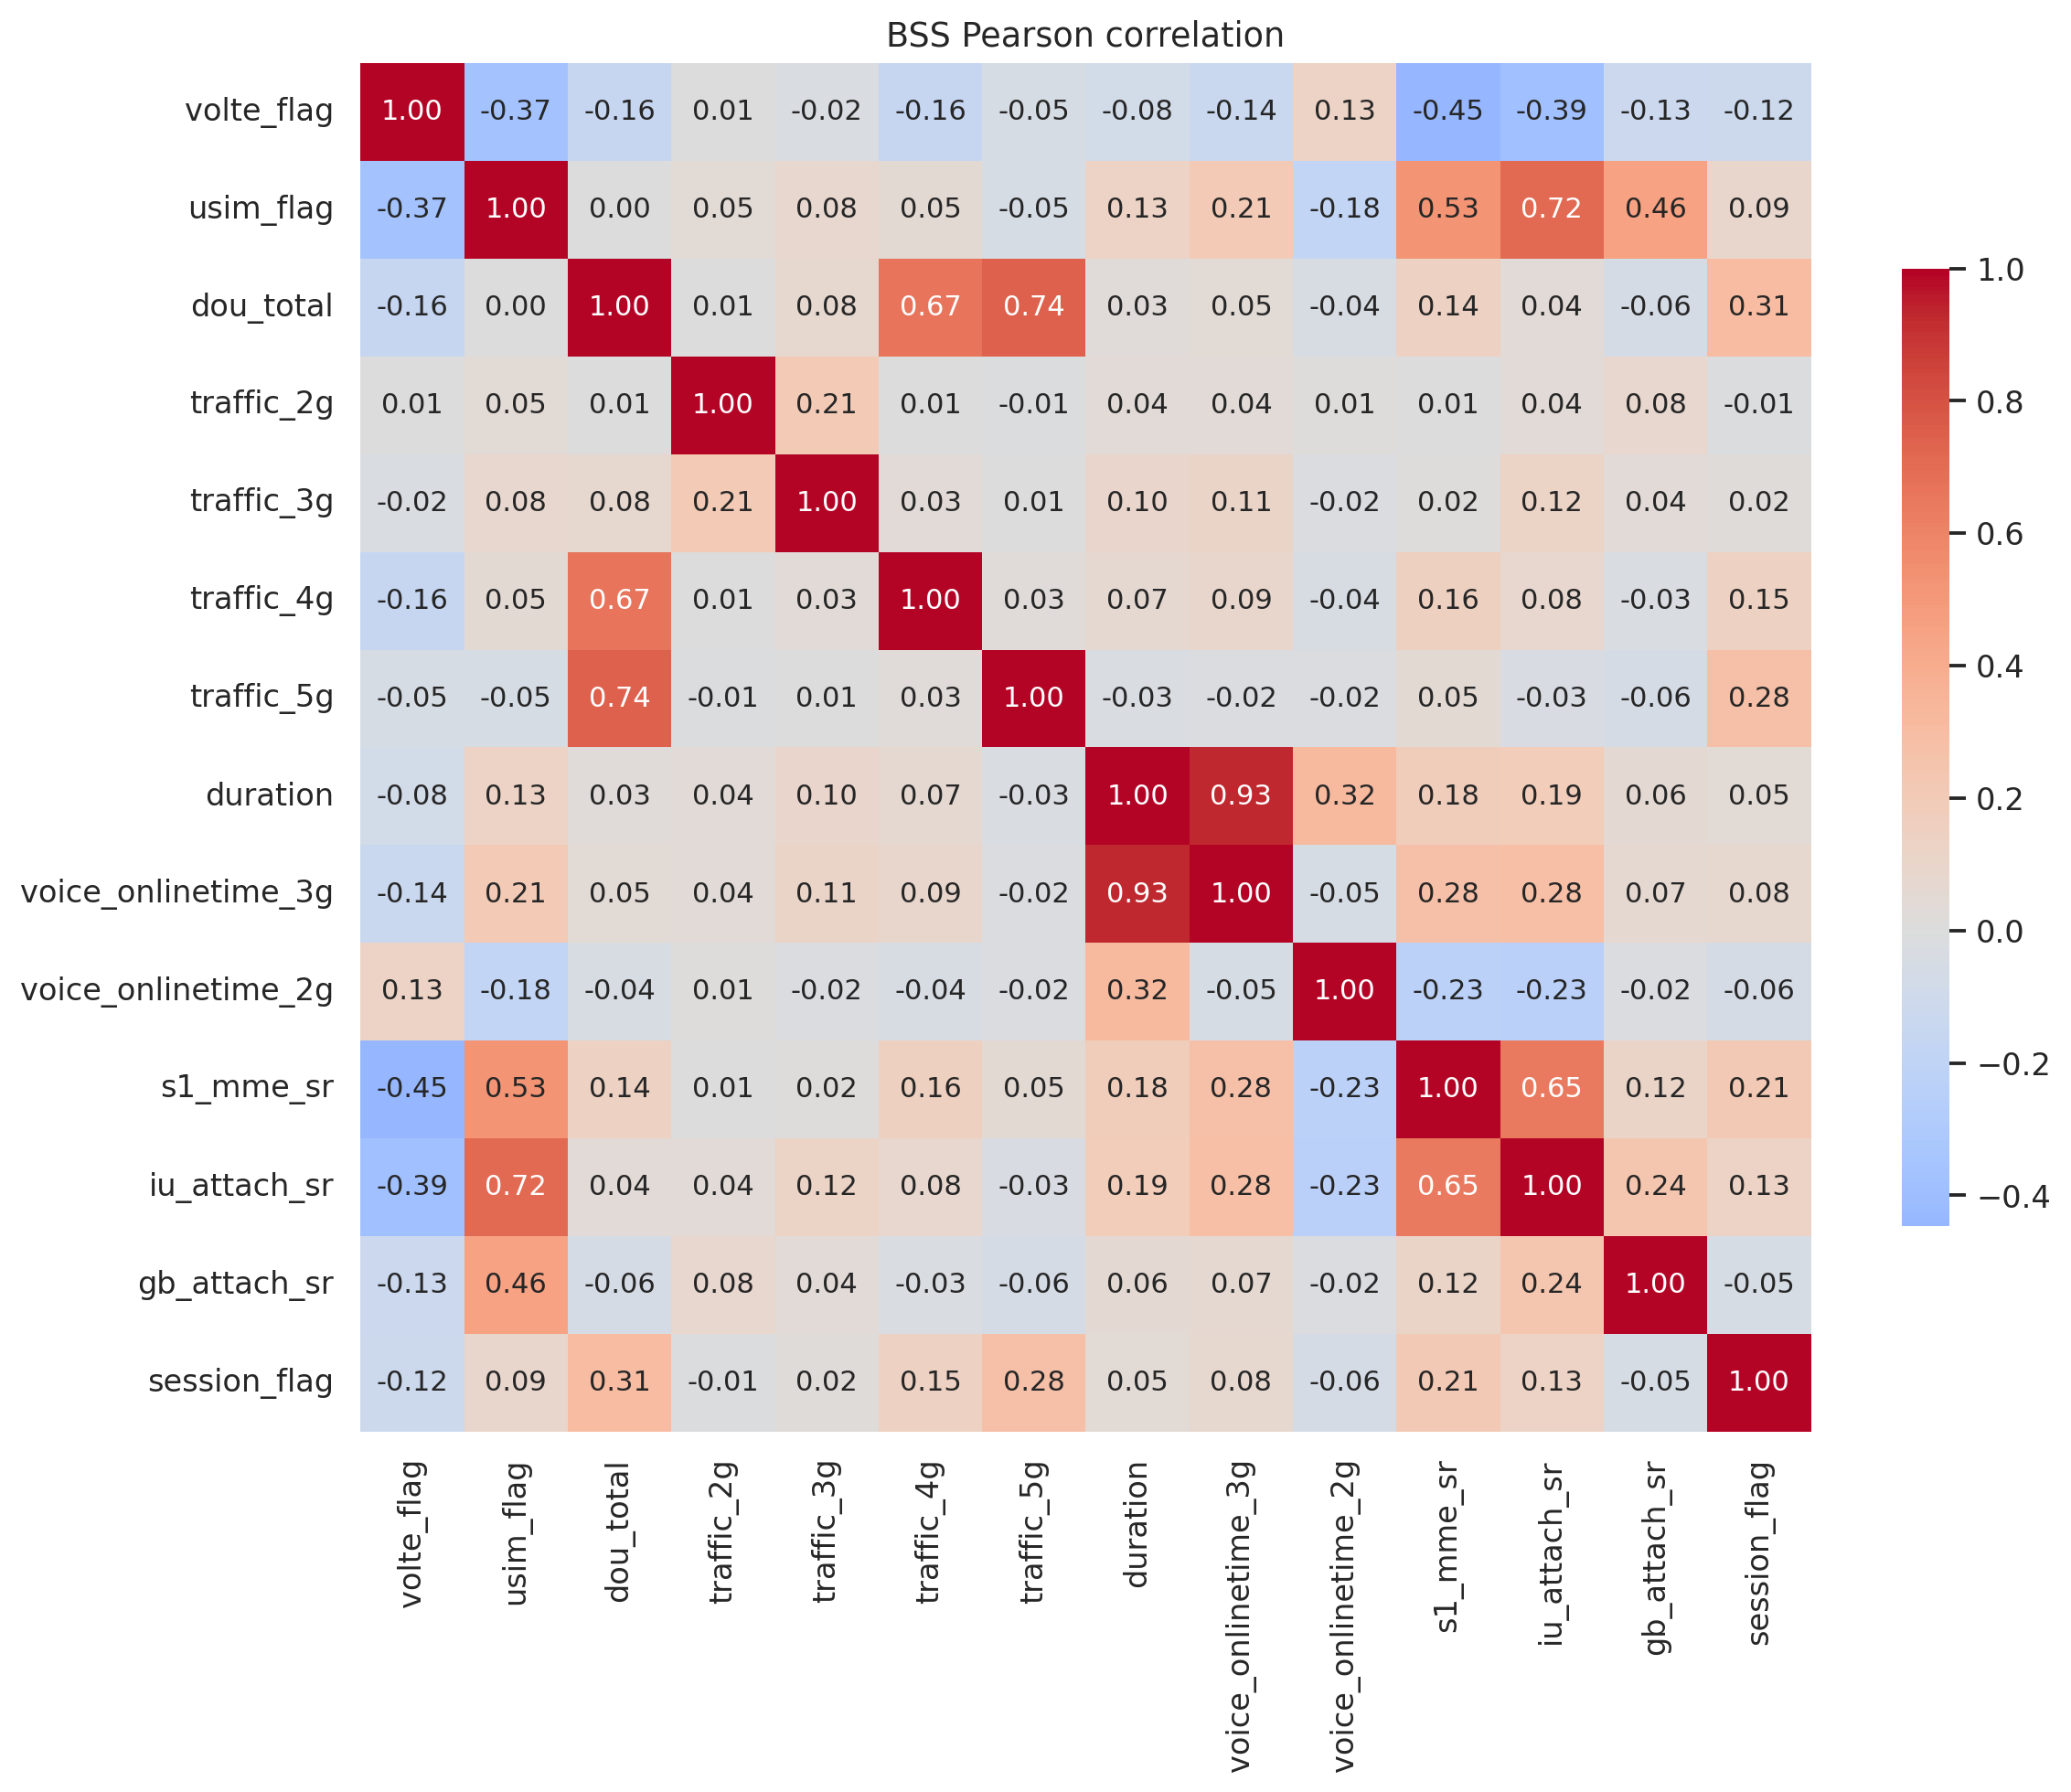

In [15]:
corr = df_bss[num_cols].corr(method='pearson')
fig, ax = plt.subplots(figsize=(11,9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, cbar_kws={'shrink':0.7})
ax.set_title('BSS Pearson correlation'); plt.tight_layout(); plt.show()

### 13.5 · Spearman correlation + Mutual Information (non-linear)

**What this shows:** Three views of feature relationships — Pearson (linear), Spearman (monotonic, rank-based), Mutual Information (any statistical dependence including non-linear).
**What to look for:** Cells where |Pearson - Spearman| is large indicate non-linear monotonic relationships. High MI values reveal features that LightGBM/XGBoost will exploit even when Pearson is low.

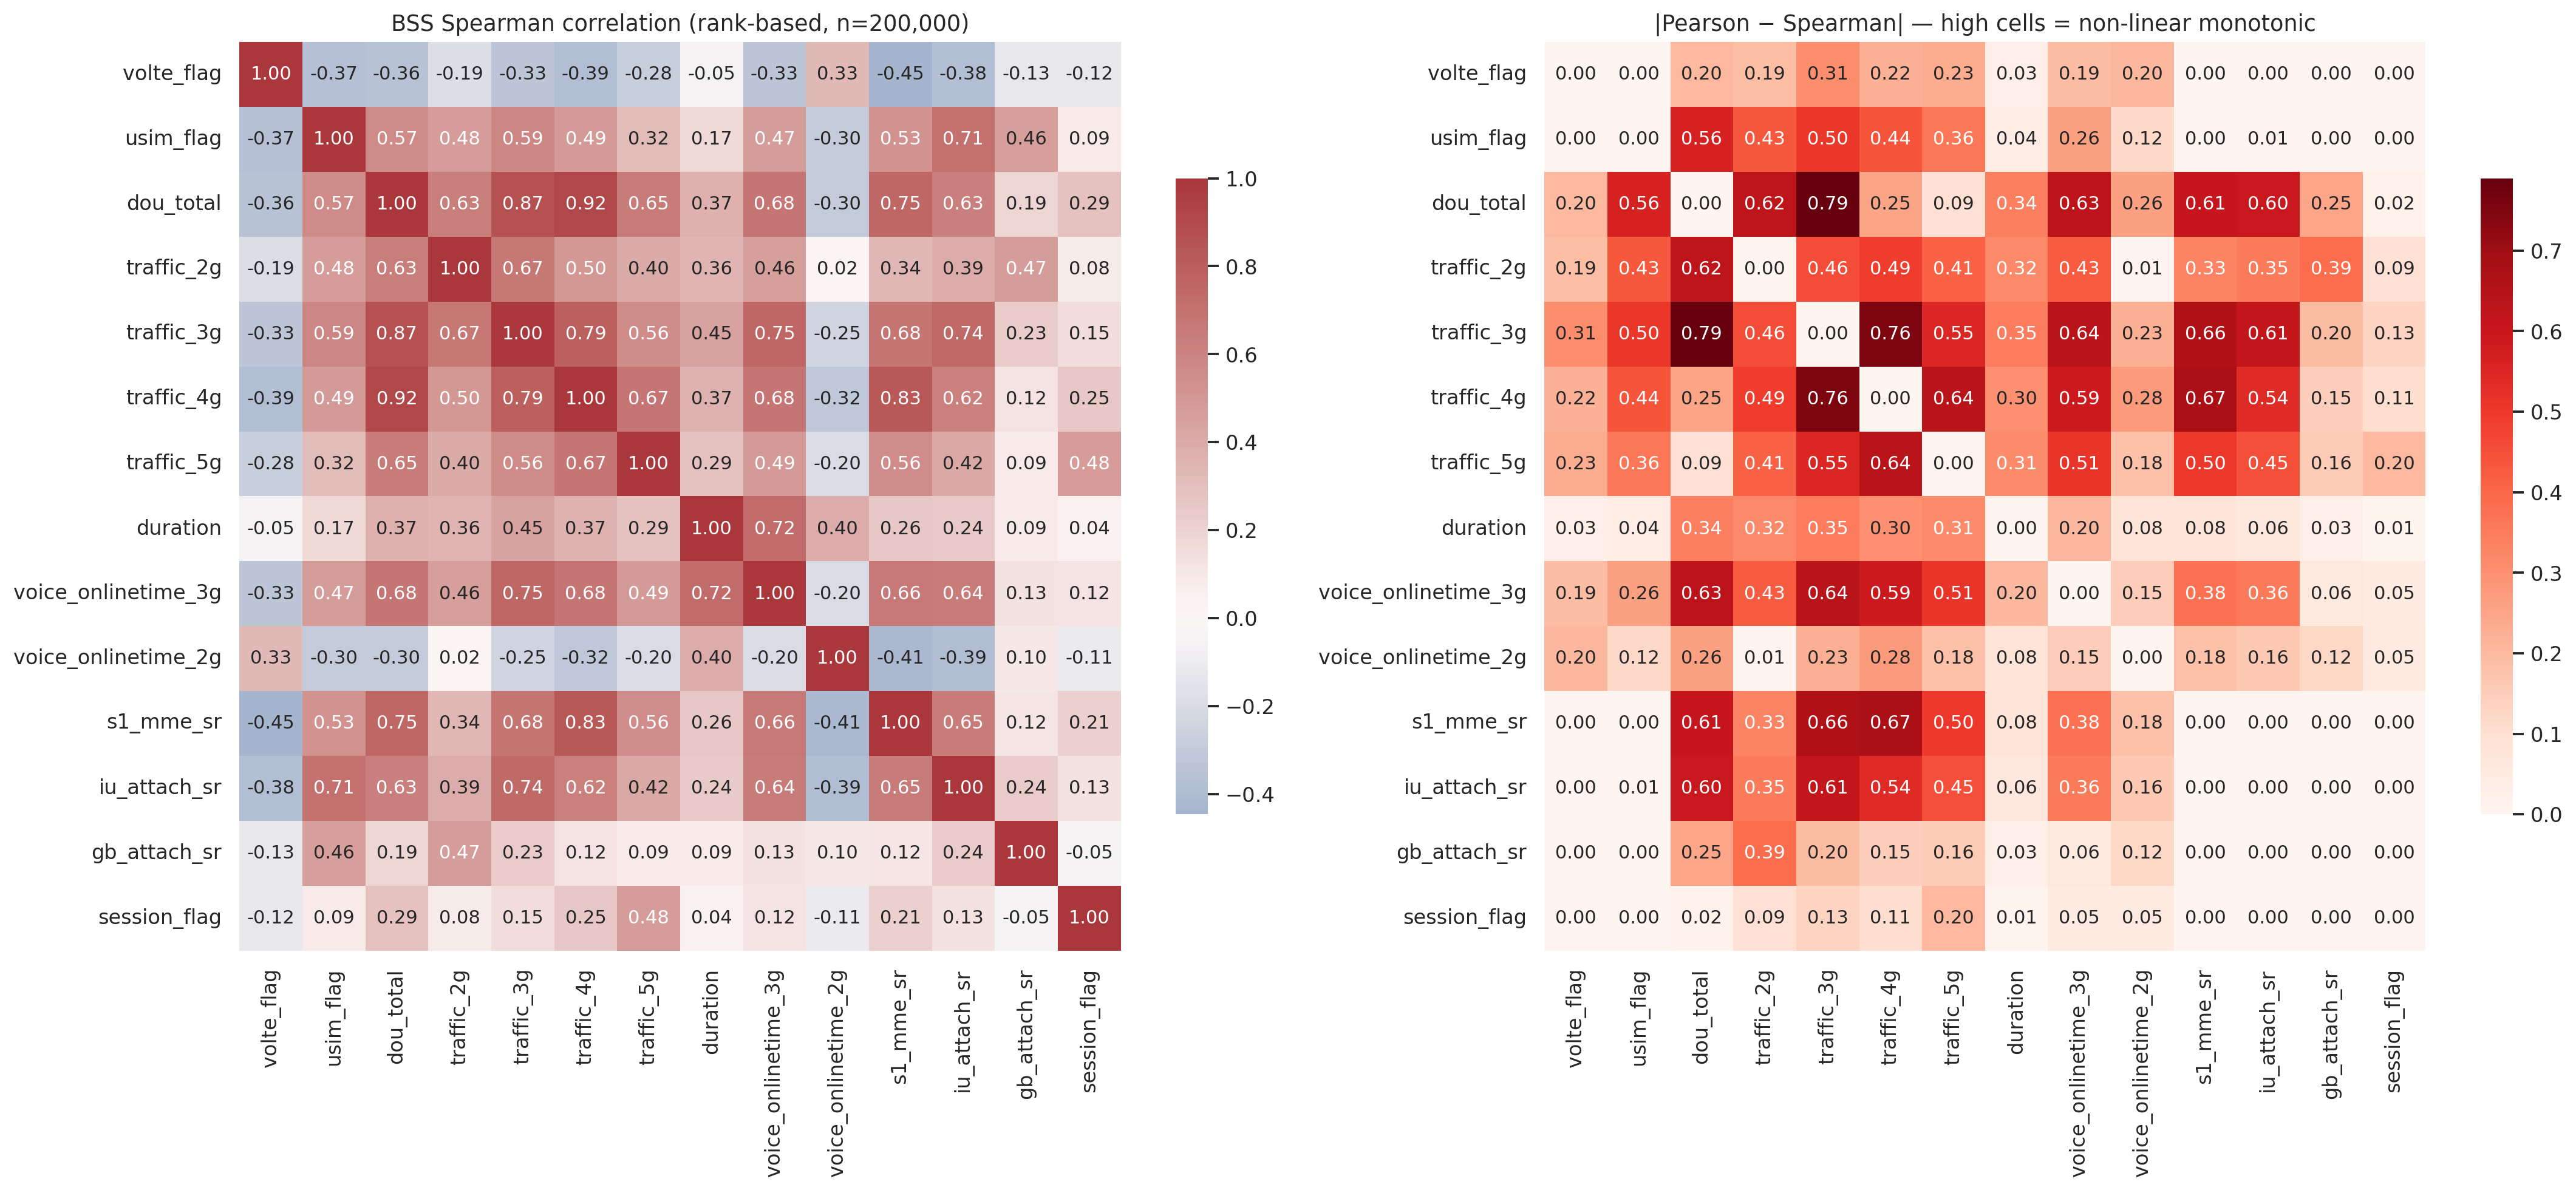

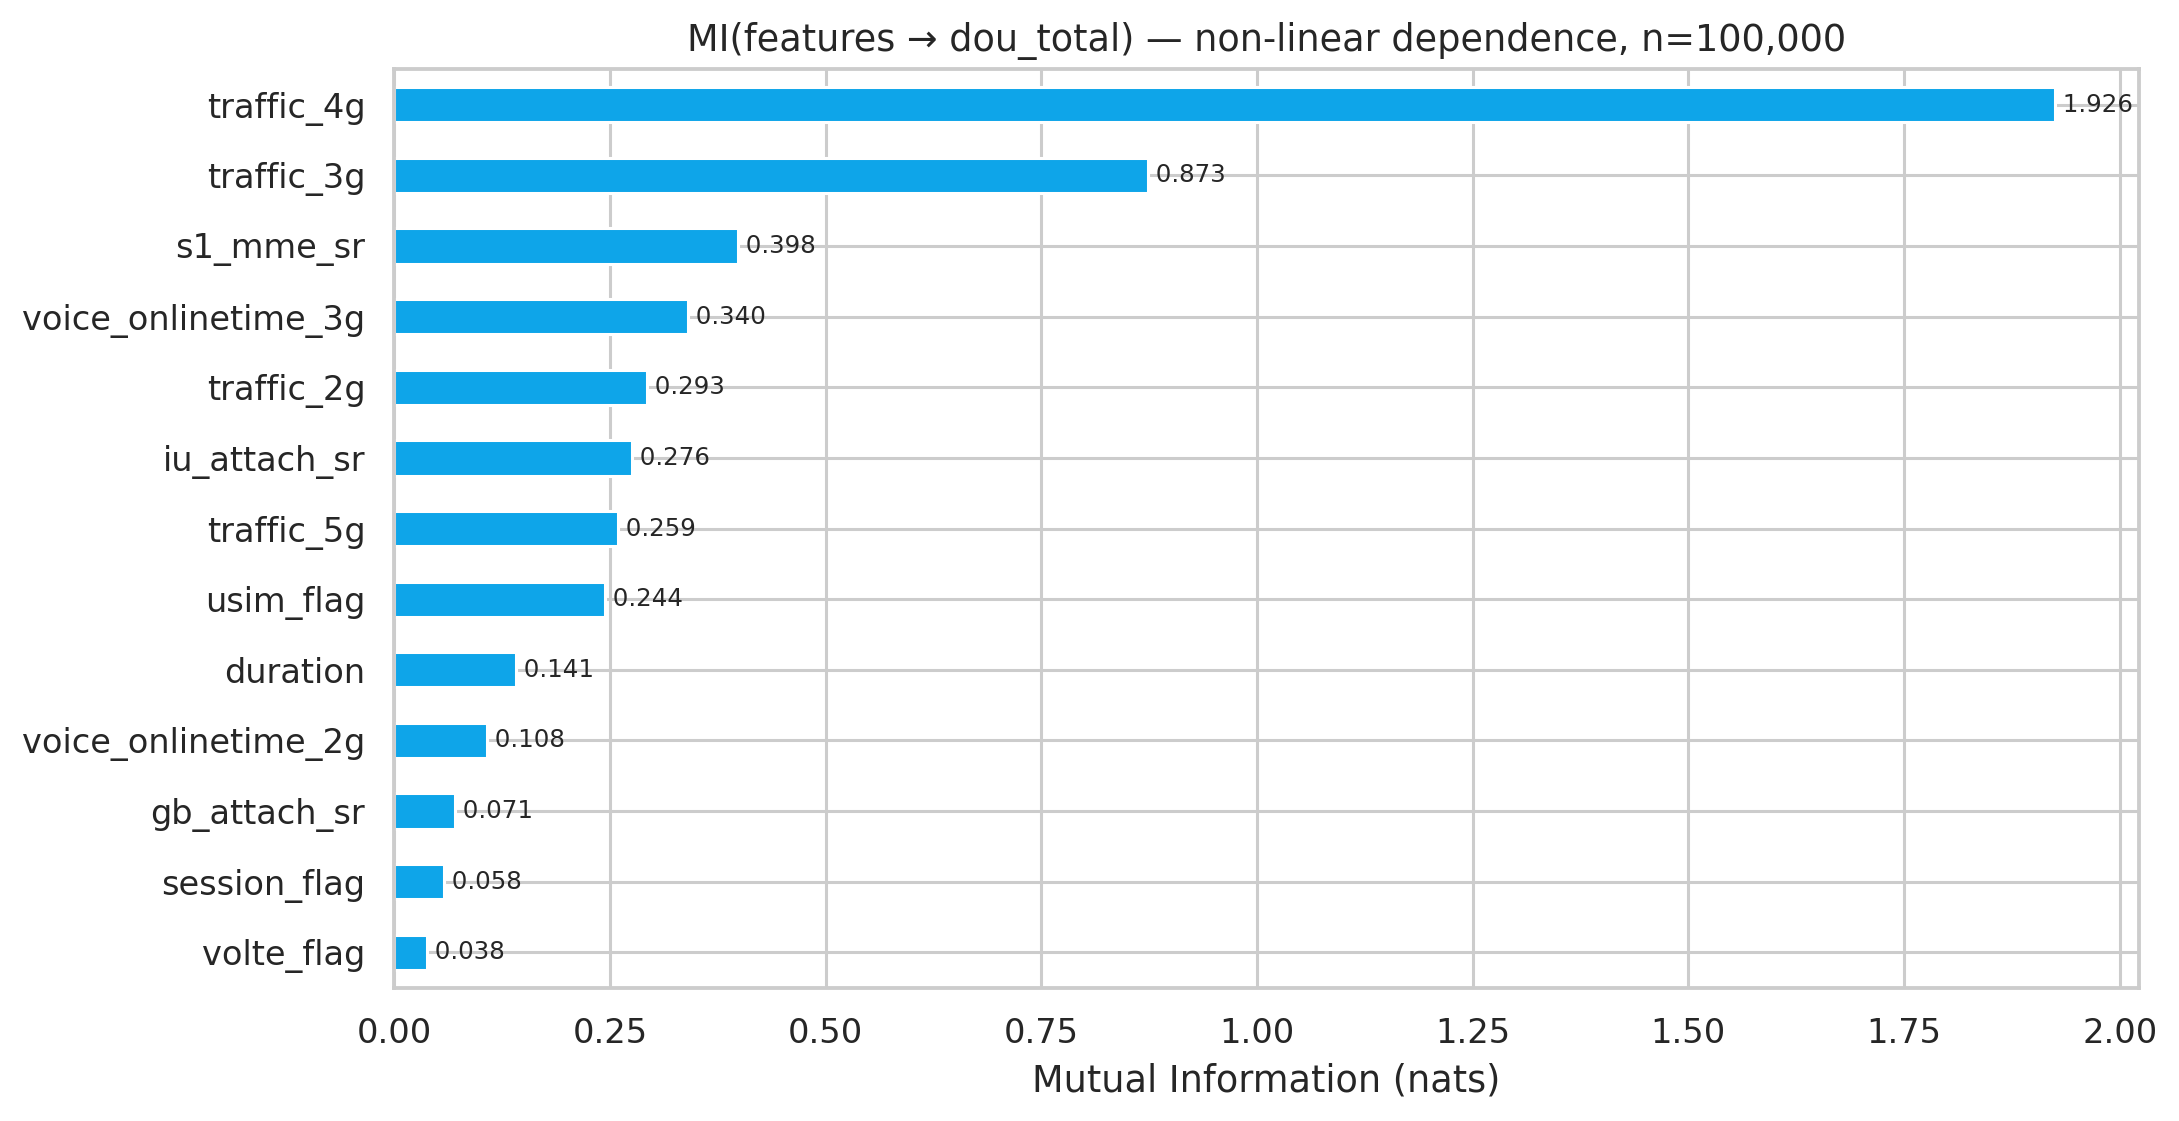

,mi_score
traffic_4g,1.9256
traffic_3g,0.8734
s1_mme_sr,0.3980
voice_onlinetime_3g,0.3403
traffic_2g,0.2926
iu_attach_sr,0.2761
traffic_5g,0.2593
usim_flag,0.2439
duration,0.1411
voice_onlinetime_2g,0.1076


In [16]:
# --- Beyond Pearson: Spearman (rank-based, monotonic) + Mutual Information (non-linear) ---
# Refs:
#   - Spearman (1904) — robust to outliers, captures monotonic non-linear
#   - Reshef DN et al. (2011) — MI captures any statistical dependence
#   - sklearn.feature_selection.mutual_info_regression
# Sample to 100K rows for speed (MI is O(n log n) per pair).
MI_SAMPLE_N = 100_000

# Sample stratified by source_origin so real + simulated both represented
sample_for_mi = (
    df_bss.groupby('source_origin', group_keys=False)
          .sample(n=min(MI_SAMPLE_N // 2, len(df_bss) // 2), random_state=SEED)
)
X_mi  = sample_for_mi[num_cols].fillna(0).astype(float)

# Use dou_total (the proxy CEM target) as the y variable for MI
y_target_col = TARGET_QUARTILE_COL if TARGET_QUARTILE_COL in num_cols else num_cols[0]
y_mi = X_mi[y_target_col].values
X_mi = X_mi.drop(columns=[y_target_col])

# --- Spearman correlation matrix ---
spear = df_bss[num_cols].sample(n=min(200_000, len(df_bss)), random_state=SEED).corr(method='spearman')
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
sns.heatmap(spear, annot=True, fmt='.2f', cmap='vlag', center=0, ax=axes[0], cbar_kws={'shrink': 0.7})
axes[0].set_title(f'BSS Spearman correlation (rank-based, n={min(200_000, len(df_bss)):,})')

# --- Pearson vs Spearman delta (where they disagree = non-linear monotonic relationship) ---
delta = (corr - spear).abs()
sns.heatmap(delta, annot=True, fmt='.2f', cmap='Reds', ax=axes[1], cbar_kws={'shrink': 0.7})
axes[1].set_title('|Pearson − Spearman| — high cells = non-linear monotonic')
plt.tight_layout(); plt.show()

# --- Mutual Information (non-linear dependence on dou_total) ---
mi_scores = mutual_info_regression(X_mi.values, y_mi, random_state=SEED)
mi_series = pd.Series(mi_scores, index=X_mi.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, 0.4 * len(mi_series))))
mi_series.plot(kind='barh', ax=ax, color='#0ea5e9')
ax.set_xlabel('Mutual Information (nats)')
ax.set_title(f'MI(features → {y_target_col}) — non-linear dependence, n={len(X_mi):,}')
for i, v in enumerate(mi_series.values):
    ax.text(v, i, f' {v:.3f}', va='center', fontsize=8)
plt.tight_layout(); plt.show()

display(mi_series.sort_values(ascending=False).round(4).to_frame('mi_score'))

## 14 · Load ALL OSS (per RAT)

Headers start at line 8 (lines 1-7 = Huawei metadata).

In [17]:
# --- OSS load: ALL months × ALL RAT, RAT-stratified sample with 4G focus ---
# Before: 3 hardcoded single-file paths (one CSV per RAT).
# After:  glob all 48 generated CSVs (16 months × 3 RAT), stratify-sample for EDA speed.
#
# Sampling policy (defense rationale):
#   - 2G : 80K  rows  — legacy network, dropping subscriber base, low analytical priority
#   - 3G : 80K  rows  — transitional RAT
#   - 4G : 240K rows  — 3× weight — primary growth RAT, richest KPI set
#                       (throughput, RSRP, active users avg/max) which the VAE needs
#   - 5G : N/A in OSS — Tunisie Telecom did NOT provide 5G OSS exports.
#                       5G analysis lives in BSS (`traffic_5g` = subscriber device capability).
#
# Inside each RAT we stratify by source filename (≈ month) so all 16 months represented.

import re

OSS_GEN_DIR = OSS_DIR / 'generated'
RAT_RE = re.compile(r'oss_(\w{2})_([a-z_]+)\.csv$')
RAT_SAMPLE_N = {'2G': 80_000, '3G': 80_000, '4G': 240_000}   # 4G triple-weighted

# Group files by RAT
files_by_rat = {'2G': [], '3G': [], '4G': []}
for p in sorted(OSS_GEN_DIR.glob('oss_*.csv')):
    m = RAT_RE.search(p.name)
    if not m: continue
    rat = m.group(1).upper()
    if rat in files_by_rat: files_by_rat[rat].append(p)

if not any(files_by_rat.values()):
    # Fallback to legacy hardcoded paths (one-shot April export) if generated/ missing.
    print(f'[warn] {OSS_GEN_DIR} empty — falling back to legacy single-file OSS load')
    LEGACY = {
        '2G': OSS_DIR/'KPI Analysis Result_Query_Result_20260427105204494(KPI Analysis Result).csv',
        '3G': OSS_DIR/'KPI Analysis Result_Query_Result_2026042710520899(KPI Analysis Result).csv',
        '4G': OSS_DIR/'KPI Analysis Result_Query_Result_20260427105212826(KPI Analysis Result).csv',
    }
    oss_raw = {}
    for rat, p in LEGACY.items():
        df = pd.read_csv(p, skiprows=6, encoding='utf-8-sig')
        df.columns = df.columns.str.strip()
        df['rat_type'] = rat
        oss_raw[rat] = df
        print(f'  {rat}: {df.shape[0]:,} rows × {df.shape[1]} cols (legacy single-file)')
else:
    oss_raw = {}
    for rat, paths in files_by_rat.items():
        if not paths:
            oss_raw[rat] = pd.DataFrame()
            continue
        parts = []
        for p in paths:
            df = pd.read_csv(p, skiprows=6, encoding='utf-8-sig')
            df.columns = df.columns.str.strip()
            df['rat_type'] = rat
            df['_src_file'] = p.name
            parts.append(df)
        full = pd.concat(parts, ignore_index=True)
        # Stratified sample by source file (≈ month) — all 16 months represented inside RAT
        n_target = min(RAT_SAMPLE_N[rat], len(full))
        per_file = max(1, n_target // len(paths))
        sampled = (
            full.groupby('_src_file', group_keys=False)
                .apply(lambda g: g.sample(n=min(len(g), per_file), random_state=SEED))
                .reset_index(drop=True)
        )
        oss_raw[rat] = sampled.drop(columns='_src_file')
        print(f'  {rat}: loaded {len(full):,} rows from {len(paths)} files → sampled {len(oss_raw[rat]):,} (target {n_target:,})')

    totals = {rat: len(df) for rat, df in oss_raw.items()}
    print(f"\nTotals: 2G={totals['2G']:,}  3G={totals['3G']:,}  4G={totals['4G']:,}  (4G ×3 — primary RAT)")
    print('Note: OSS has no 5G — only BSS exposes 5G device-capability via `traffic_5g`.')

  2G: loaded 800,000 rows from 16 files → sampled 80,000 (target 80,000)
  3G: loaded 800,000 rows from 16 files → sampled 80,000 (target 80,000)
  4G: loaded 800,000 rows from 16 files → sampled 240,000 (target 240,000)

Totals: 2G=80,000  3G=80,000  4G=240,000  (4G ×3 — primary RAT)
Note: OSS has no 5G — only BSS exposes 5G device-capability via `traffic_5g`.


## 15 · OSS columns per RAT

In [18]:
for rat, df in oss_raw.items():
    print(f'\n=== {rat} ===')
    for i,c in enumerate(df.columns,1): print(f'  [{i:2d}] {c}')


=== 2G ===
  [ 1] Time
  [ 2] GBSC
  [ 3] Site Name
  [ 4] Cell Name
  [ 5] Cell CI
  [ 6] CellIndex
  [ 7] Integrity
  [ 8] ZTR304A:Call Drop Rate on TCH per cell(Excluding Handover)(%)
  [ 9] rat_type

=== 3G ===
  [ 1] Time
  [ 2] RNC
  [ 3] NodeB Name
  [ 4] Cell Name
  [ 5] Cell ID
  [ 6] Integrity
  [ 7] HSDPA Thp 2
  [ 8] Opt_NPM_PS Call Drop (PCH)(%)
  [ 9] Opt_NPM_CS Call Drop(%)
  [10] rat_type

=== 4G ===
  [ 1] Time
  [ 2] eNodeB Name
  [ 3] eNodeB Function Name
  [ 4] Cell Name
  [ 5] LocalCell Id
  [ 6] Cell FDD TDD Indication
  [ 7] Integrity
  [ 8] HW_Call Drop Rate(all)[%](%)
  [ 9] User DL Throughput(Protocol)(Mbps)
  [10] Avg RSRP(dBm)
  [11] L.Traffic.User.Avg
  [12] L.Traffic.User.Max
  [13] rat_type


## 16 · OSS missingness audit

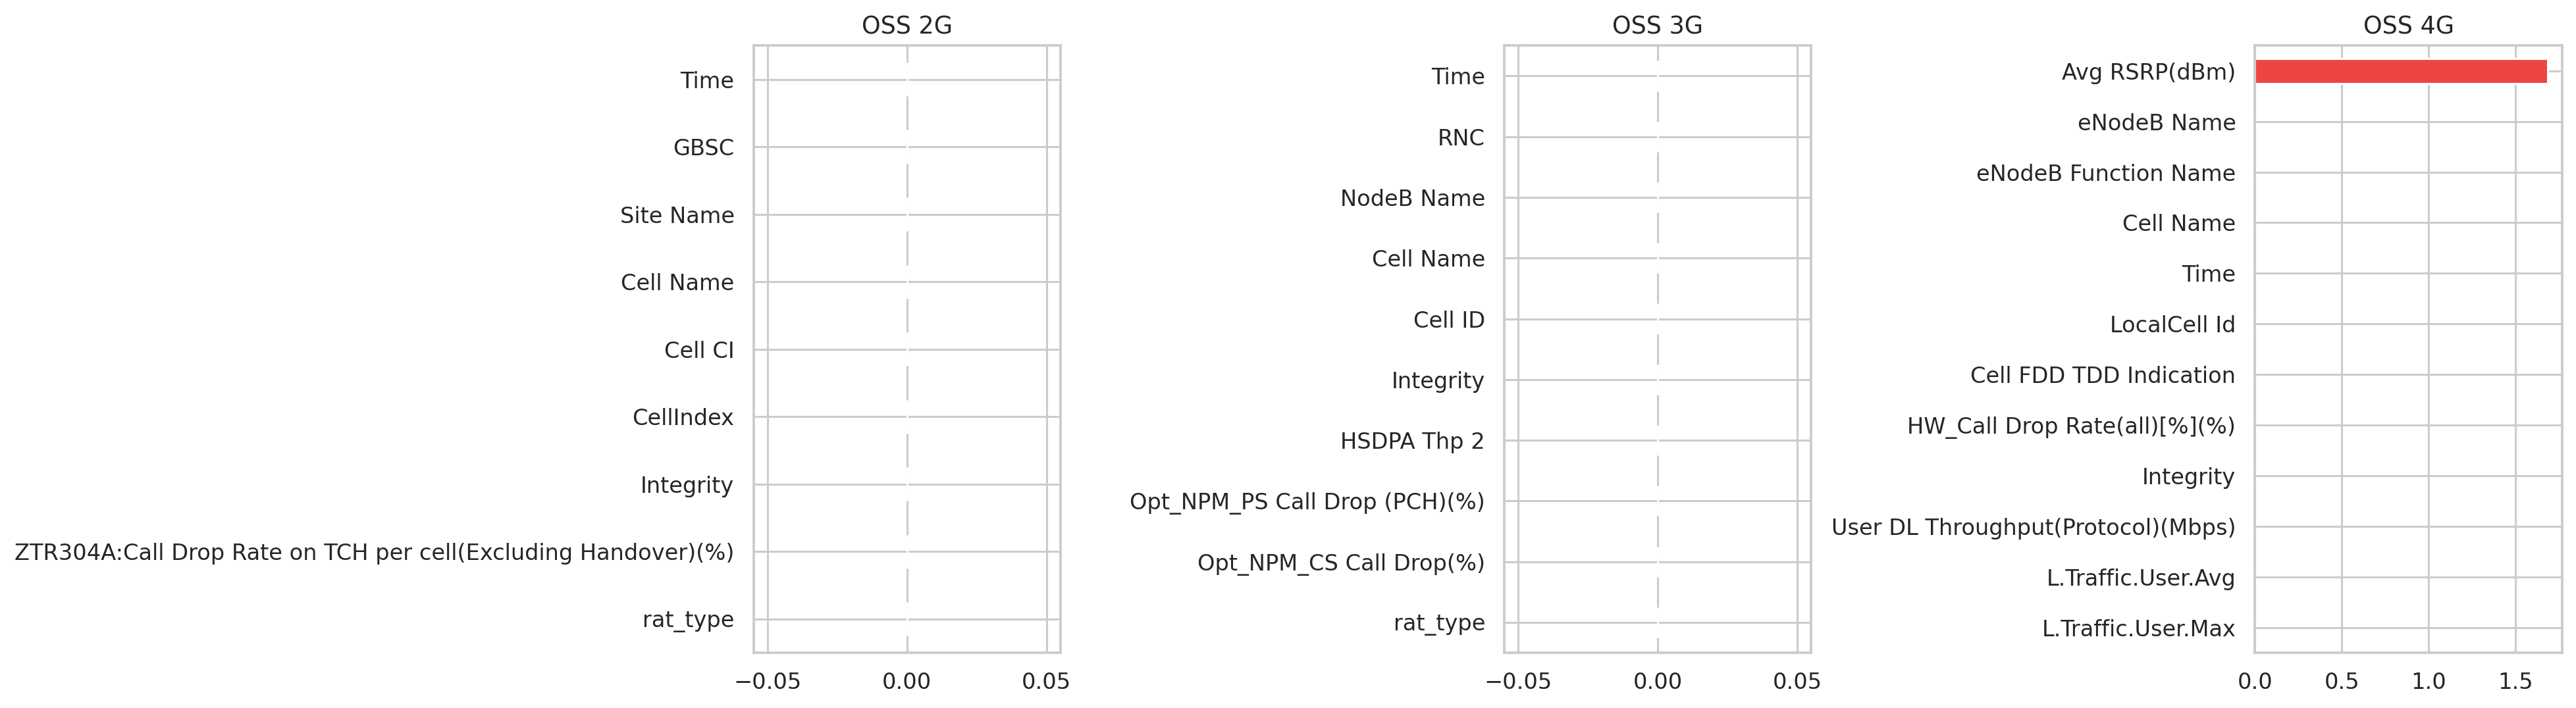

In [19]:
fig, axes = plt.subplots(1,3,figsize=(18,5))
for ax, (rat, df) in zip(axes, oss_raw.items()):
    pct = (df.isna().mean()*100).sort_values(ascending=False).head(12)
    pct.plot(kind='barh', ax=ax, color='#ef4444')
    ax.set_title(f'OSS {rat}'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 17 · OSS integrity distribution per RAT (% target = 98)

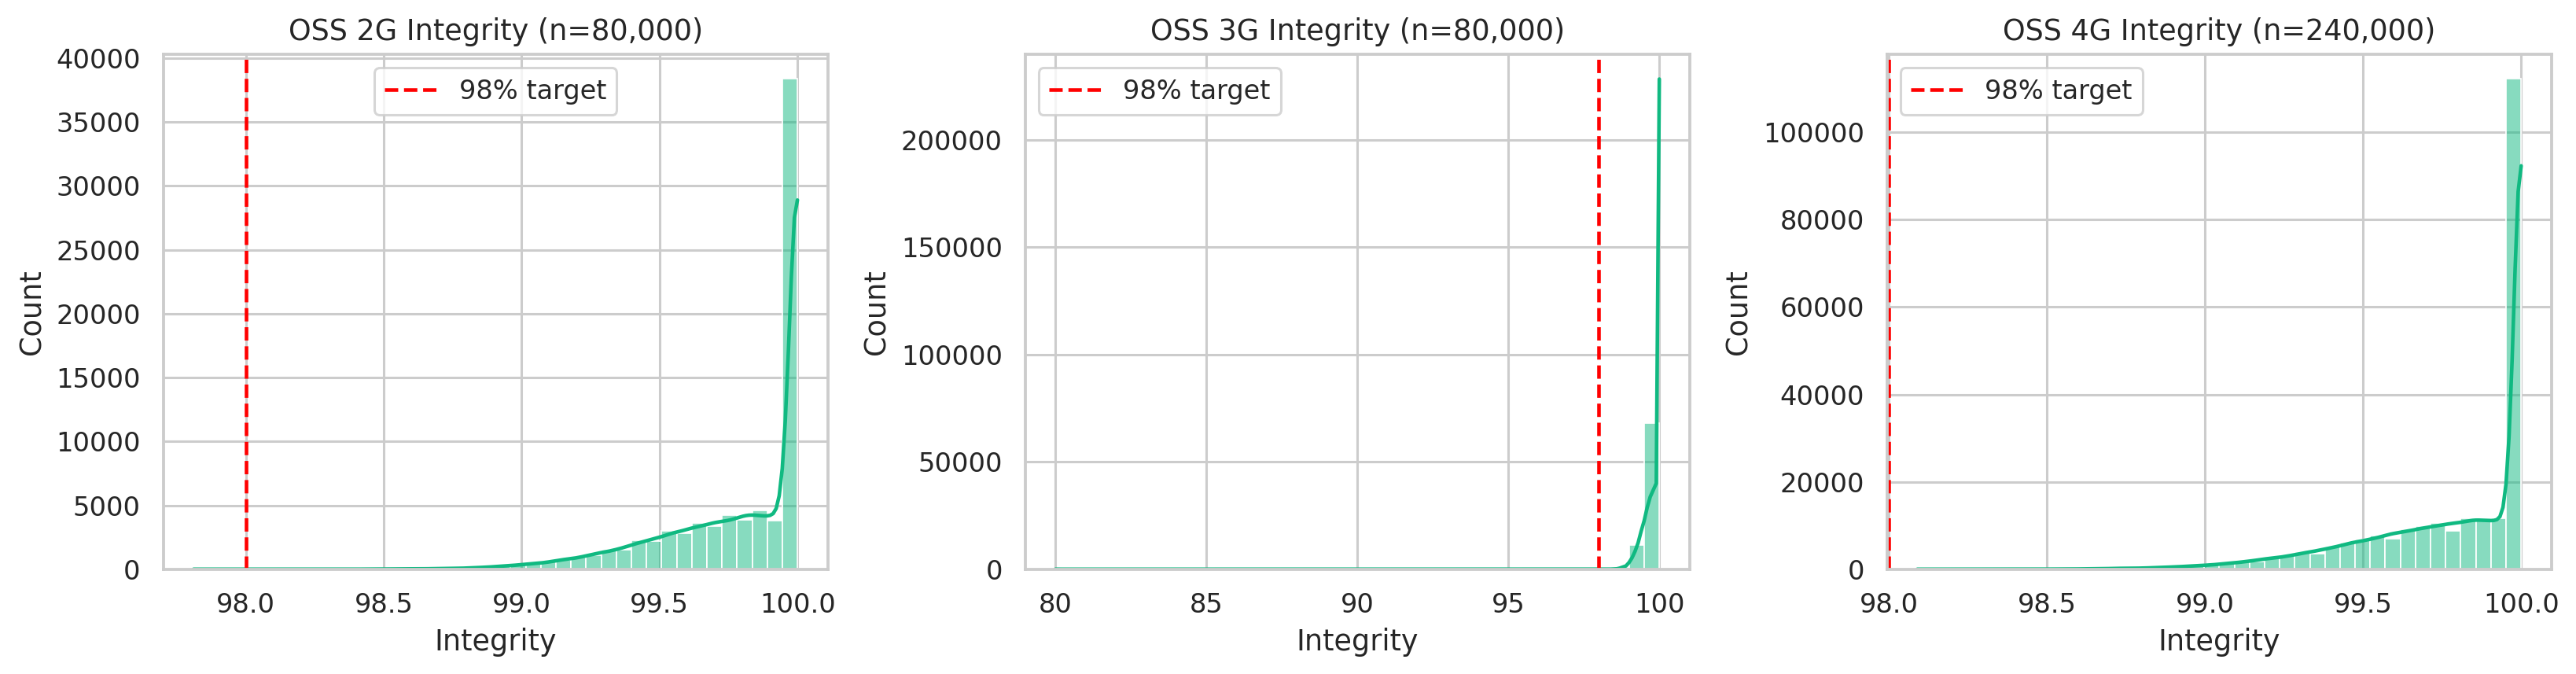

In [20]:
def integ(df):
    for c in df.columns:
        if c.lower().startswith('integrity'): return c
    return None
fig, axes = plt.subplots(1,3,figsize=(15,4))
for ax, (rat, df) in zip(axes, oss_raw.items()):
    s = df[integ(df)].astype(str).str.rstrip('%').replace('', np.nan).astype(float).dropna()
    sns.histplot(s, bins=40, kde=True, ax=ax, color='#10b981')
    ax.set_title(f'OSS {rat} Integrity (n={len(s):,})')
    ax.axvline(98, color='red', linestyle='--', label='98% target'); ax.legend()
plt.tight_layout(); plt.show()

## 18 · OSS call-drop-rate per RAT (% SLA = 2)

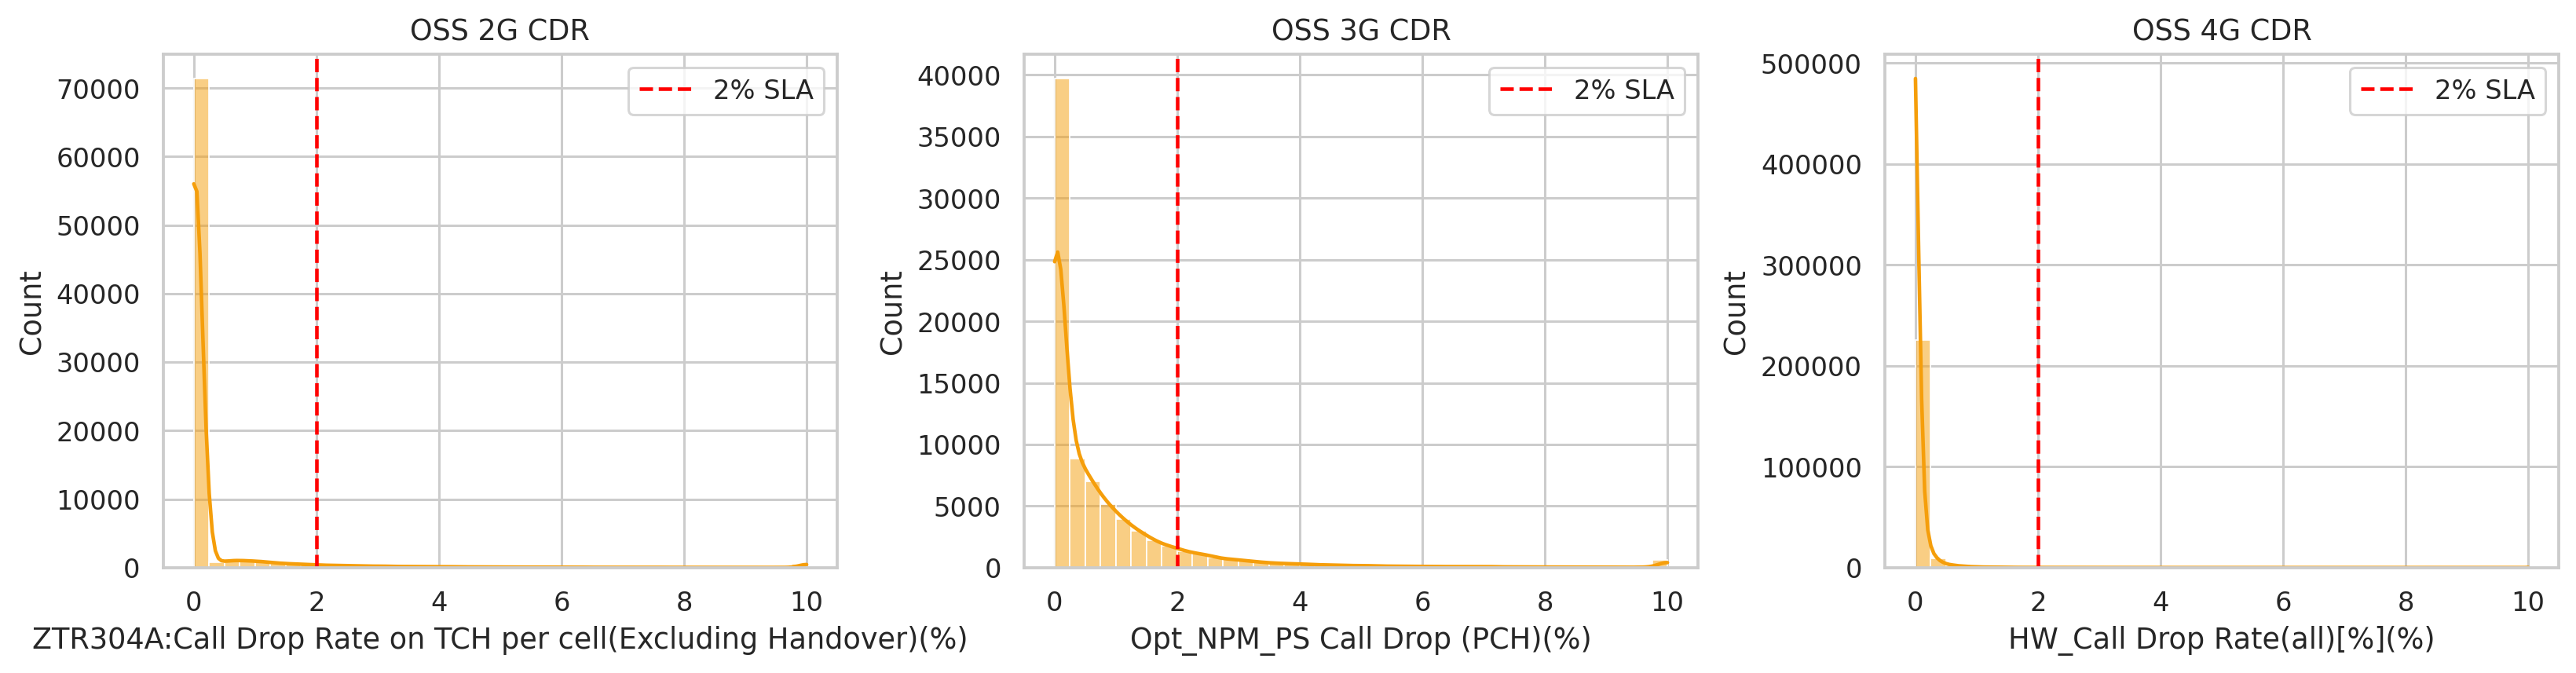

In [21]:
def cdr(df):
    for c in df.columns:
        if 'call drop' in c.lower(): return c
    return None
fig, axes = plt.subplots(1,3,figsize=(15,4))
for ax, (rat, df) in zip(axes, oss_raw.items()):
    c = cdr(df)
    if not c: ax.set_title(f'{rat} no CDR'); continue
    s = pd.to_numeric(df[c], errors='coerce').dropna()
    sns.histplot(s.clip(upper=10), bins=40, kde=True, ax=ax, color='#f59e0b')
    ax.set_title(f'OSS {rat} CDR'); ax.axvline(2, color='red', linestyle='--', label='2% SLA'); ax.legend()
plt.tight_layout(); plt.show()

## 19 · 4G throughput + RSRP + users (rich RAT)

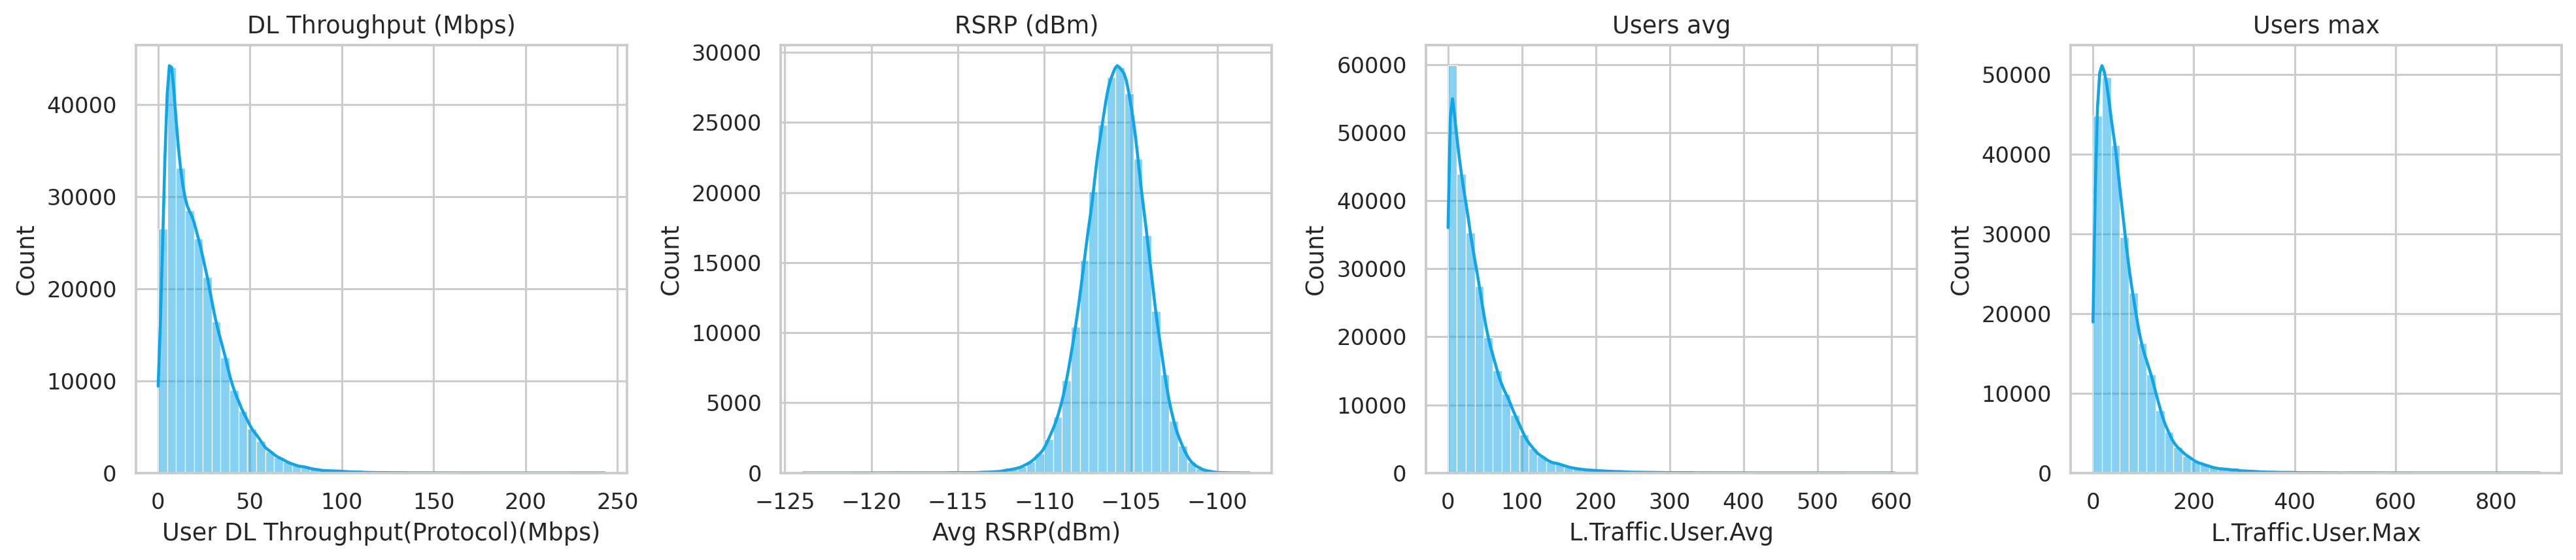

In [22]:
df4 = oss_raw['4G']
def find(df, frag):
    for c in df.columns:
        if frag.lower() in c.lower(): return c
    return None
tput = find(df4,'throughput'); rsrp = find(df4,'rsrp'); ua = find(df4,'user.avg'); um = find(df4,'user.max')
fig, axes = plt.subplots(1,4,figsize=(18,4))
for ax, c, lab in zip(axes, [tput,rsrp,ua,um], ['DL Throughput (Mbps)','RSRP (dBm)','Users avg','Users max']):
    s = pd.to_numeric(df4[c], errors='coerce').dropna()
    sns.histplot(s, bins=50, kde=True, ax=ax, color='#0ea5e9')
    ax.set_title(lab)
plt.tight_layout(); plt.show()

## 19.5 · OSS correlation analysis (Pearson per RAT + MI on 4G)

**What this shows:** Mirror of §13 / §13.5 BSS workflow, adapted for OSS. Per-RAT Pearson heatmap because each RAT has a different KPI schema (2G: integrity/CDR; 3G: + throughput; 4G: + RSRP + active users avg/max). Forcing all RATs into one matrix would create NaN-dominated cells with no statistical meaning.

**What to look for:**
- **2G/3G:** integrity ↔ CDR strongly NEGATIVE expected (low integrity ⇒ more drops) — sanity check.
- **4G:** RSRP ↔ throughput POSITIVE (better signal ⇒ more bits). active_users ↔ throughput NEGATIVE (congestion). user.avg vs user.max ratio is the *busy-hour* proxy.
- **MI plot (4G only):** non-linear contributors to integrity. RSRP + CDR should dominate. MI captures dependencies LightGBM/XGBoost will exploit even when Pearson misses them.

**Why no 5G:** Tunisie Telecom did not provide 5G OSS exports (see §14 note).

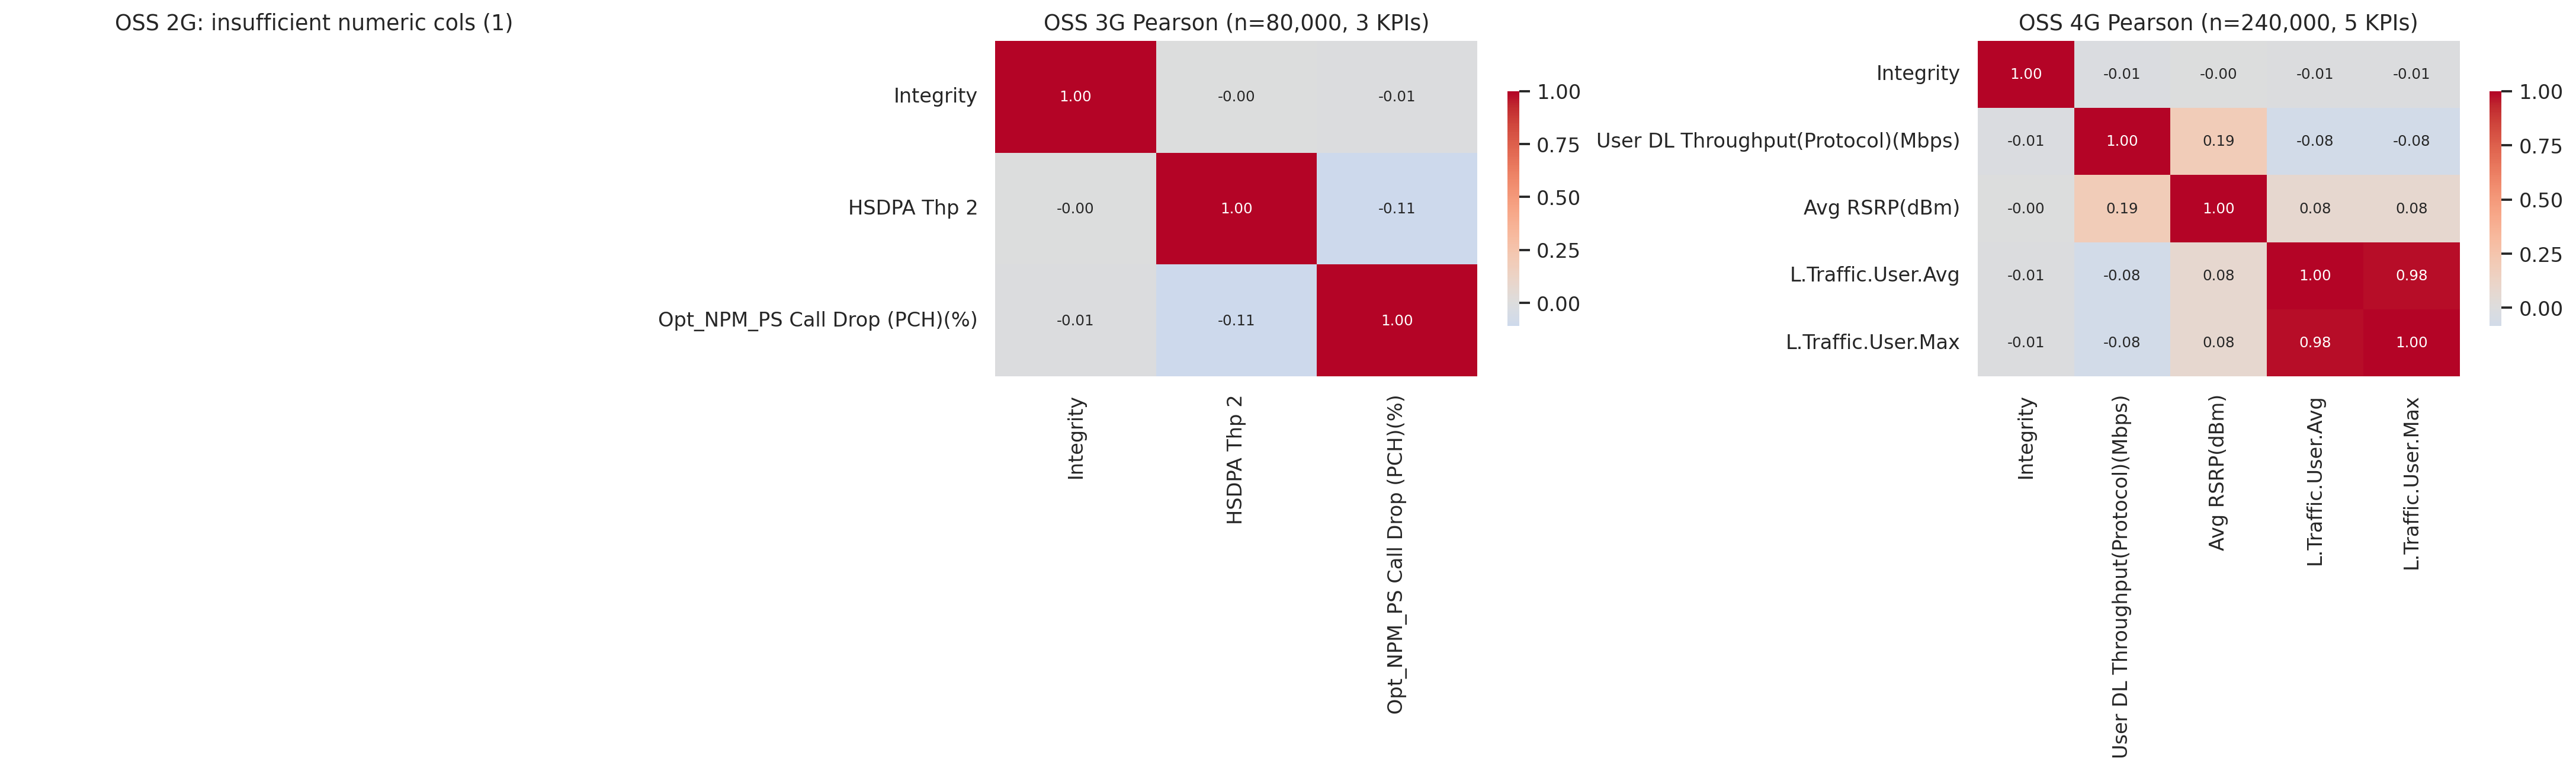

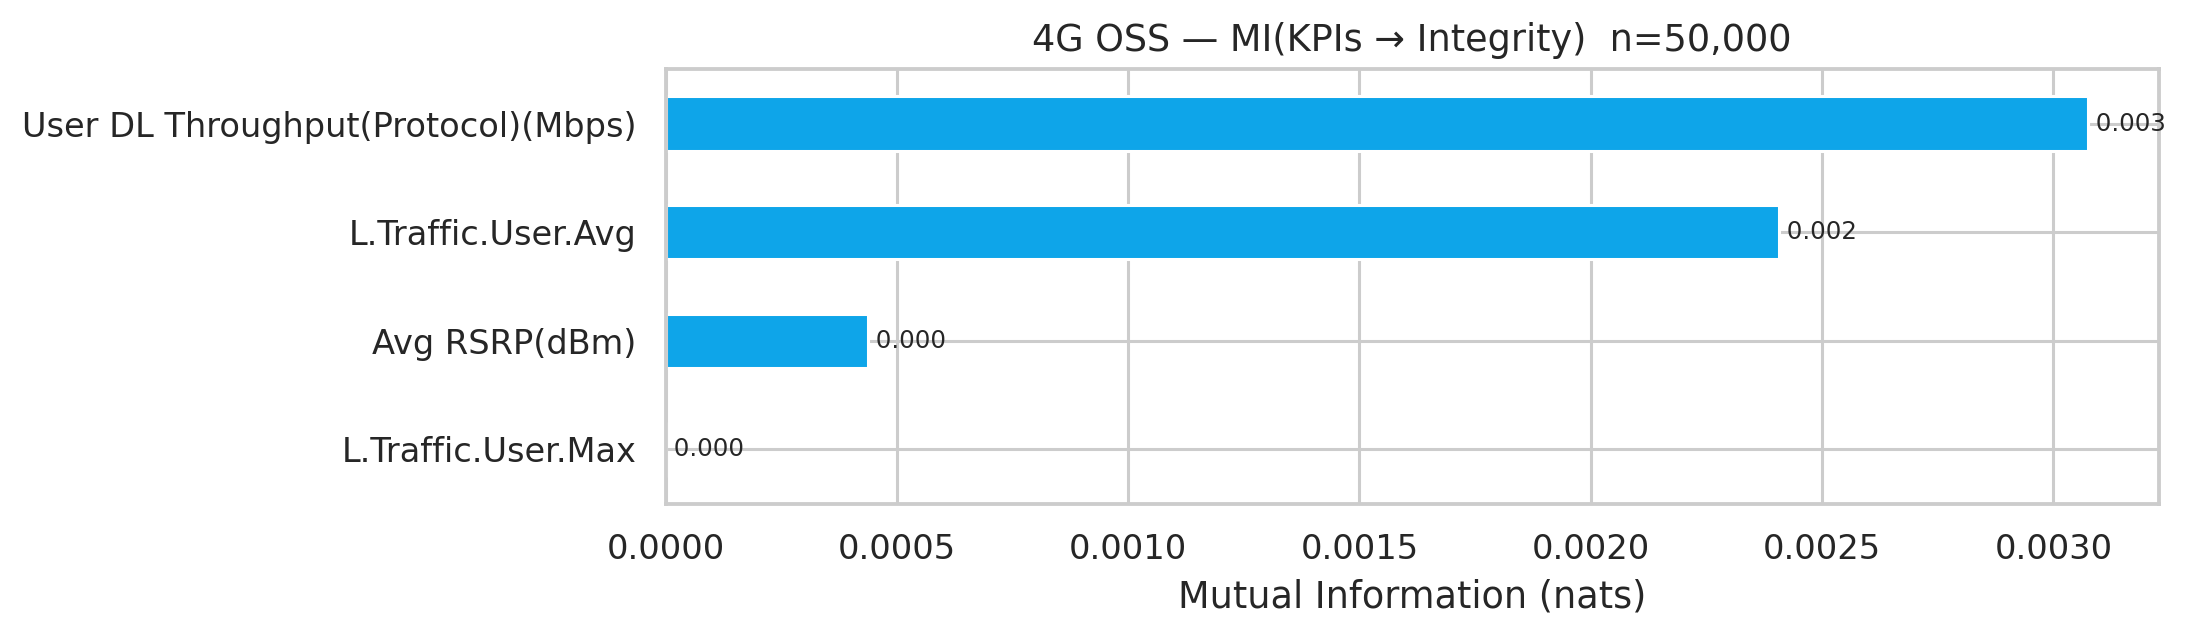

,mi_score
User DL Throughput(Protocol)(Mbps),0.0031
L.Traffic.User.Avg,0.0024
Avg RSRP(dBm),0.0004
L.Traffic.User.Max,0.0000



Interpretation: high-MI KPIs strongly drive integrity even when Pearson is weak.
These are the features the VAE (notebook 03) should reconstruct most accurately.


In [23]:
# --- OSS correlation analysis (mirror of BSS §13 / §13.5) ---
# Per-RAT Pearson heatmap + MI for 4G (richest KPI surface).
# Helpers `integ()`, `cdr()`, `find()` defined in earlier OSS cells (§17 / §18 / §19).

OSS_NUMERIC_CANDIDATES = [
    'integrity', 'call_drop_rate', 'throughput', 'rsrp',
    'user.avg', 'user.max', 'thp', 'opt_npm',
]

def _oss_numeric_view(df):
    """Coerce OSS columns to clean numeric DataFrame. Strips '%' from integrity."""
    out = pd.DataFrame(index=df.index)
    for frag in OSS_NUMERIC_CANDIDATES:
        col = find(df, frag)
        if col is None or col in out.columns:
            continue
        s = df[col].astype(str).str.rstrip('%').replace('', np.nan)
        s = pd.to_numeric(s, errors='coerce')
        if s.notna().sum() == 0:
            continue
        out[col] = s
    return out

# --- (a) Per-RAT Pearson heatmaps ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (rat, df) in zip(axes, oss_raw.items()):
    nv = _oss_numeric_view(df)
    if nv.shape[1] < 2:
        ax.set_title(f'OSS {rat}: insufficient numeric cols ({nv.shape[1]})')
        ax.axis('off'); continue
    corr_rat = nv.corr(method='pearson')
    sns.heatmap(
        corr_rat, annot=True, fmt='.2f', cmap='coolwarm', center=0,
        ax=ax, cbar_kws={'shrink': 0.7}, annot_kws={'size': 8}
    )
    ax.set_title(f'OSS {rat} Pearson (n={len(nv):,}, {nv.shape[1]} KPIs)')
plt.tight_layout(); plt.show()

# --- (b) MI for 4G — non-linear dependence of every other KPI on Integrity ---
df4 = oss_raw['4G']
nv4 = _oss_numeric_view(df4).dropna()
integ_col_4g = find(df4, 'integrity')

if nv4.shape[0] < 1000 or integ_col_4g not in nv4.columns or nv4.shape[1] < 2:
    print(f'[skip] 4G MI requires integrity + ≥2 KPIs + ≥1K complete rows (got {nv4.shape}, integ={integ_col_4g})')
else:
    OSS_MI_SAMPLE_N = 50_000
    nv4_samp = nv4.sample(n=min(OSS_MI_SAMPLE_N, len(nv4)), random_state=SEED)
    y_oss = nv4_samp[integ_col_4g].astype(float).values
    X_oss = nv4_samp.drop(columns=[integ_col_4g]).astype(float)

    mi_oss = mutual_info_regression(X_oss.values, y_oss, random_state=SEED)
    mi_oss_series = pd.Series(mi_oss, index=X_oss.columns).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(3, 0.5 * len(mi_oss_series))))
    mi_oss_series.plot(kind='barh', ax=ax, color='#0ea5e9')
    ax.set_xlabel('Mutual Information (nats)')
    ax.set_title(f'4G OSS — MI(KPIs → Integrity)  n={len(X_oss):,}')
    for i, v in enumerate(mi_oss_series.values):
        ax.text(v, i, f' {v:.3f}', va='center', fontsize=8)
    plt.tight_layout(); plt.show()

    display(mi_oss_series.sort_values(ascending=False).round(4).to_frame('mi_score'))
    print('\nInterpretation: high-MI KPIs strongly drive integrity even when Pearson is weak.')
    print('These are the features the VAE (notebook 03) should reconstruct most accurately.')

## 22.5 · Distribution-vs-Target overlay (engagement quartile)

**What this shows:** KDE of each feature split by `dou_total` quartile (Q1=low usage, Q4=heavy users). `dou_total` is the proxy for CEM-score since the true `cem_score` column is computed only in notebook 01.
**What to look for:** Cleanly-separated quartile KDEs ⇒ strong predictor for CEM downstream. Overlapping KDEs ⇒ feature does not discriminate engagement.

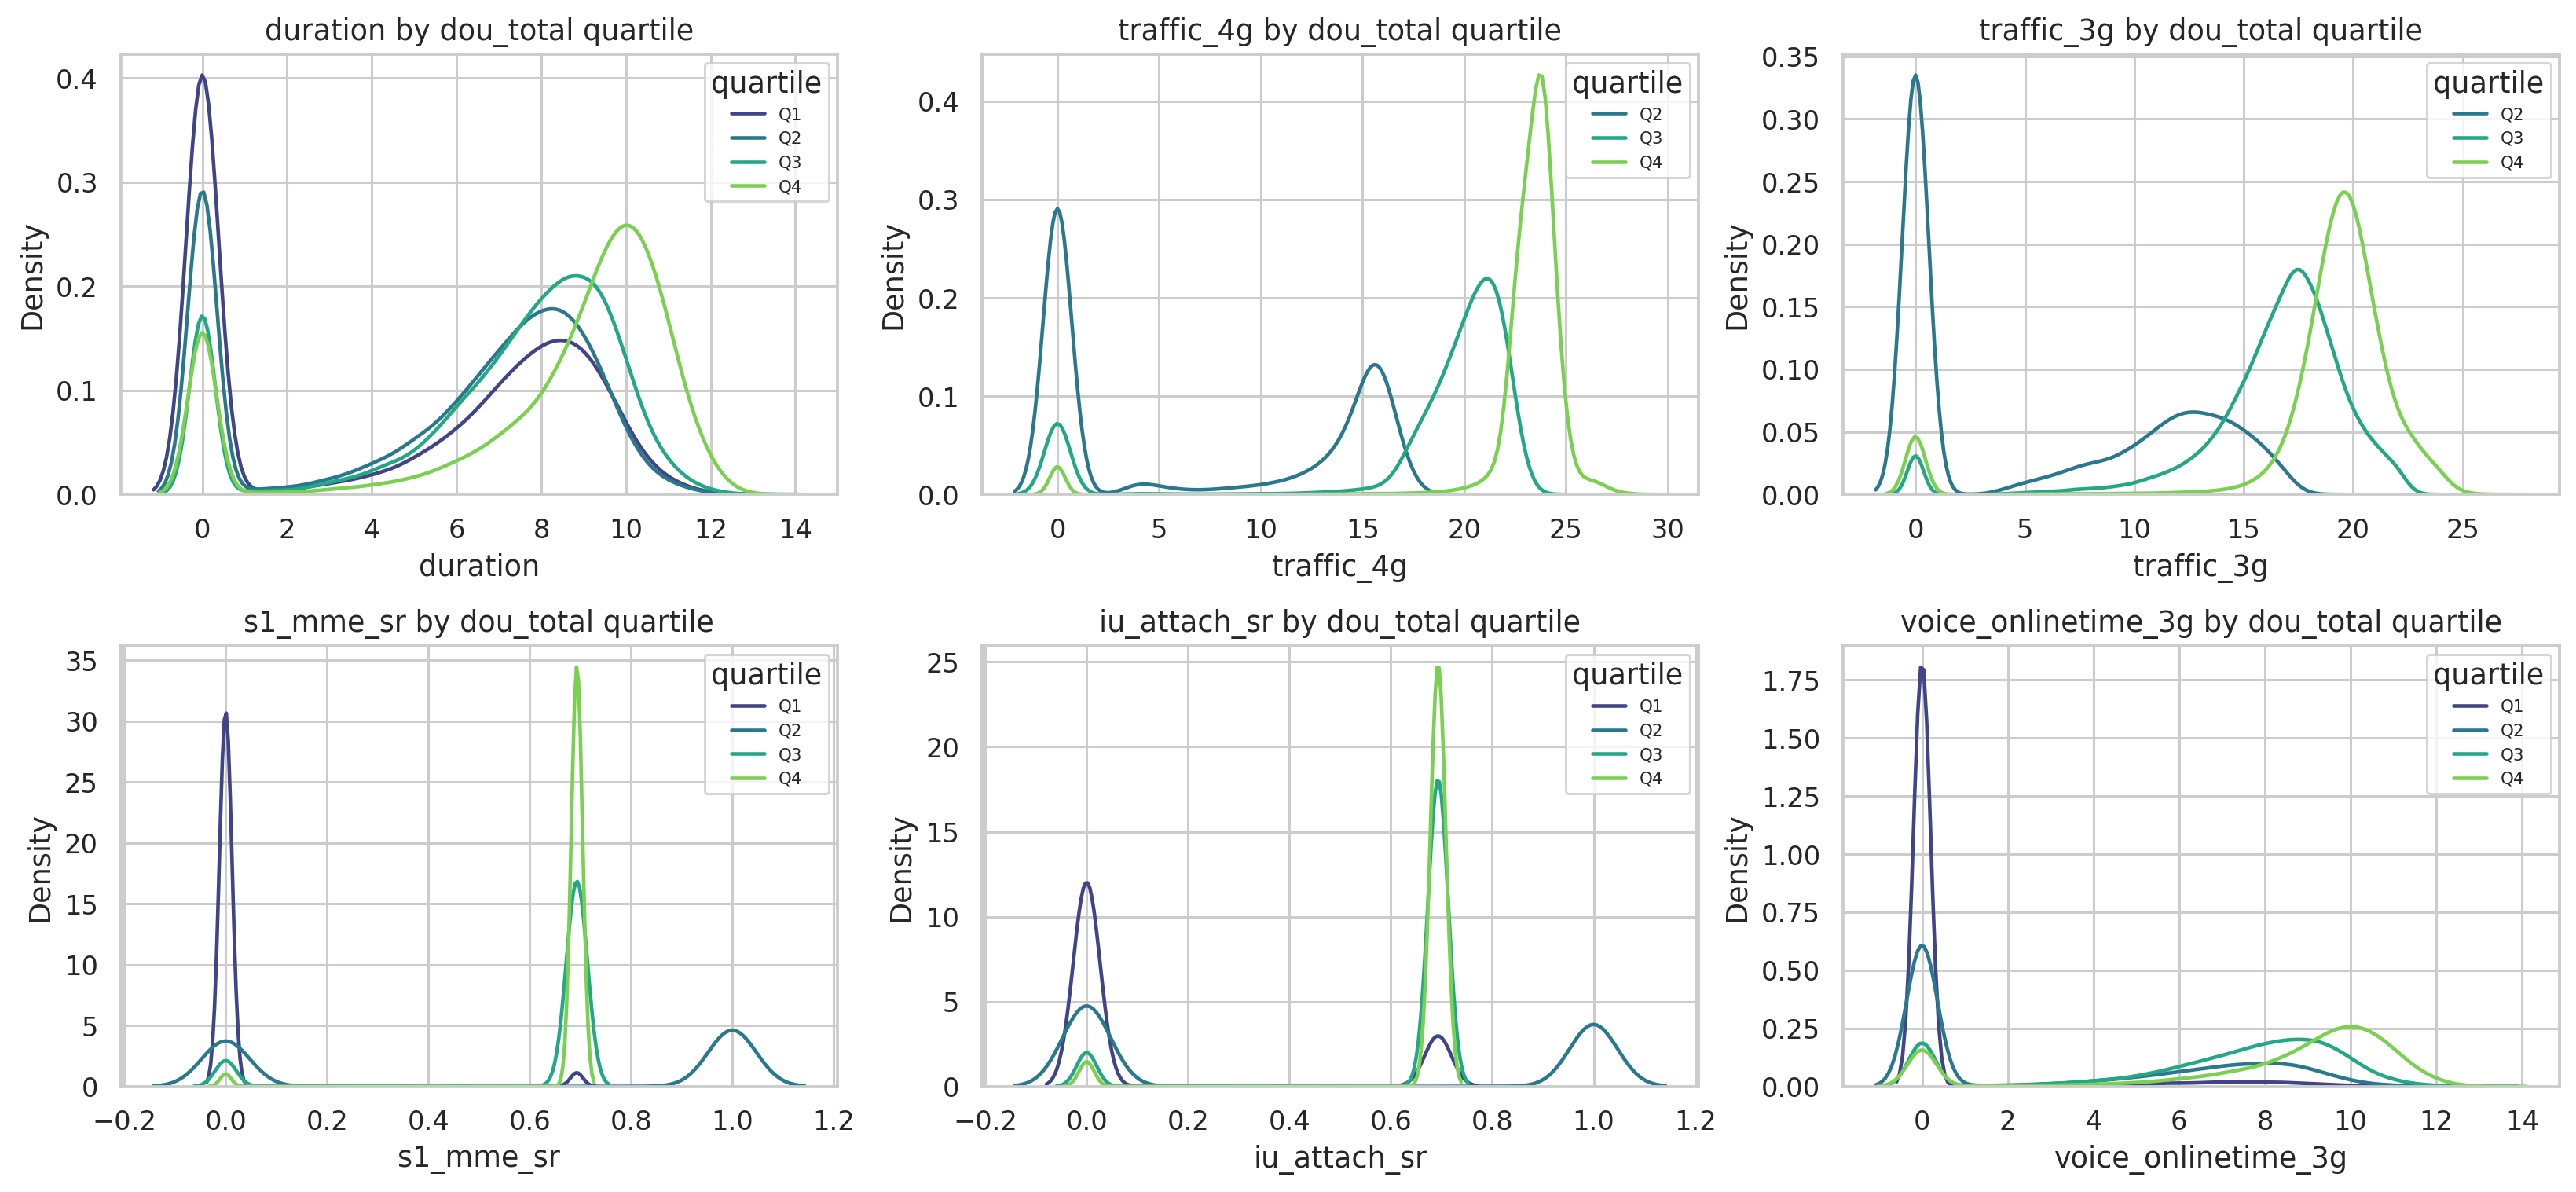


Interpretation: cleanly-separated quartile KDEs => strong CEM-score predictor.
Overlapping KDEs => feature does not discriminate engagement level.


In [24]:
# --- Distribution-vs-Target KDE overlays ---
# Goal: reveal which features SEPARATE high-engagement from low-engagement subscribers.
# Target proxy: dou_total quartile (Q1 = lowest 25% data usage, Q4 = highest 25%).
# Inspired by Kaggle Grandmaster pattern (vbmokin/eda-for-tabular-data-advanced-techniques).
# A feature with cleanly-separated quartile KDEs => strong predictor for CEM score.

target_col = TARGET_QUARTILE_COL
if target_col not in df_bss.columns:
    print(f'[skip] target column {target_col!r} not in BSS — distribution-vs-target overlay not produced')
else:
    # FIX: dedupe column list. target_col is usually inside num_cols already; without dedup
    # `sample_q[target_col]` returns a 2-column DataFrame which breaks pd.qcut with
    # "ValueError: Input array must be 1 dimensional".
    cols_for_sample = list(dict.fromkeys([target_col, *num_cols]))
    sample_q = df_bss[cols_for_sample].sample(
        n=min(500_000, len(df_bss)), random_state=SEED
    ).copy()
    # Belt-and-suspenders: squeeze guards against any residual 2-D return.
    raw = sample_q[target_col]
    target_series = raw.squeeze('columns') if isinstance(raw, pd.DataFrame) else raw
    sample_q['quartile'] = pd.qcut(
        target_series.rank(method='first'),
        q=N_QUARTILES,
        labels=[f'Q{i+1}' for i in range(N_QUARTILES)],
    )

    # Plot a curated subset of features (most likely to separate by engagement)
    feature_subset = [c for c in [
        'duration', 'traffic_4g', 'traffic_3g', 's1_mme_sr',
        'iu_attach_sr', 'voice_onlinetime_3g',
    ] if c in num_cols and c != target_col]

    ncols = 3
    nrows = (len(feature_subset) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
    palette = sns.color_palette('viridis', N_QUARTILES)
    for ax, col in zip(axes.flat, feature_subset):
        for i, q in enumerate(sorted(sample_q['quartile'].dropna().unique())):
            s = sample_q.loc[sample_q['quartile'] == q, col].dropna().astype(float)
            if s.empty:
                continue
            sk = float(stats.skew(s)) if len(s) > 1 else 0.0
            data = np.log1p(s) if (s.min() >= 0 and abs(sk) > HEAVY_TAIL_LOG1P_SKEW) else s
            sns.kdeplot(data, label=str(q), ax=ax, color=palette[i], linewidth=1.5)
        ax.set_title(f'{col} by {target_col} quartile')
        ax.legend(title='quartile', fontsize=7, loc='best')
    for ax in axes.flat[len(feature_subset):]:
        ax.axis('off')
    plt.tight_layout(); plt.show()

    print('\nInterpretation: cleanly-separated quartile KDEs => strong CEM-score predictor.')
    print('Overlapping KDEs => feature does not discriminate engagement level.')

## 20 · BSS top 20 areas by subscriber count

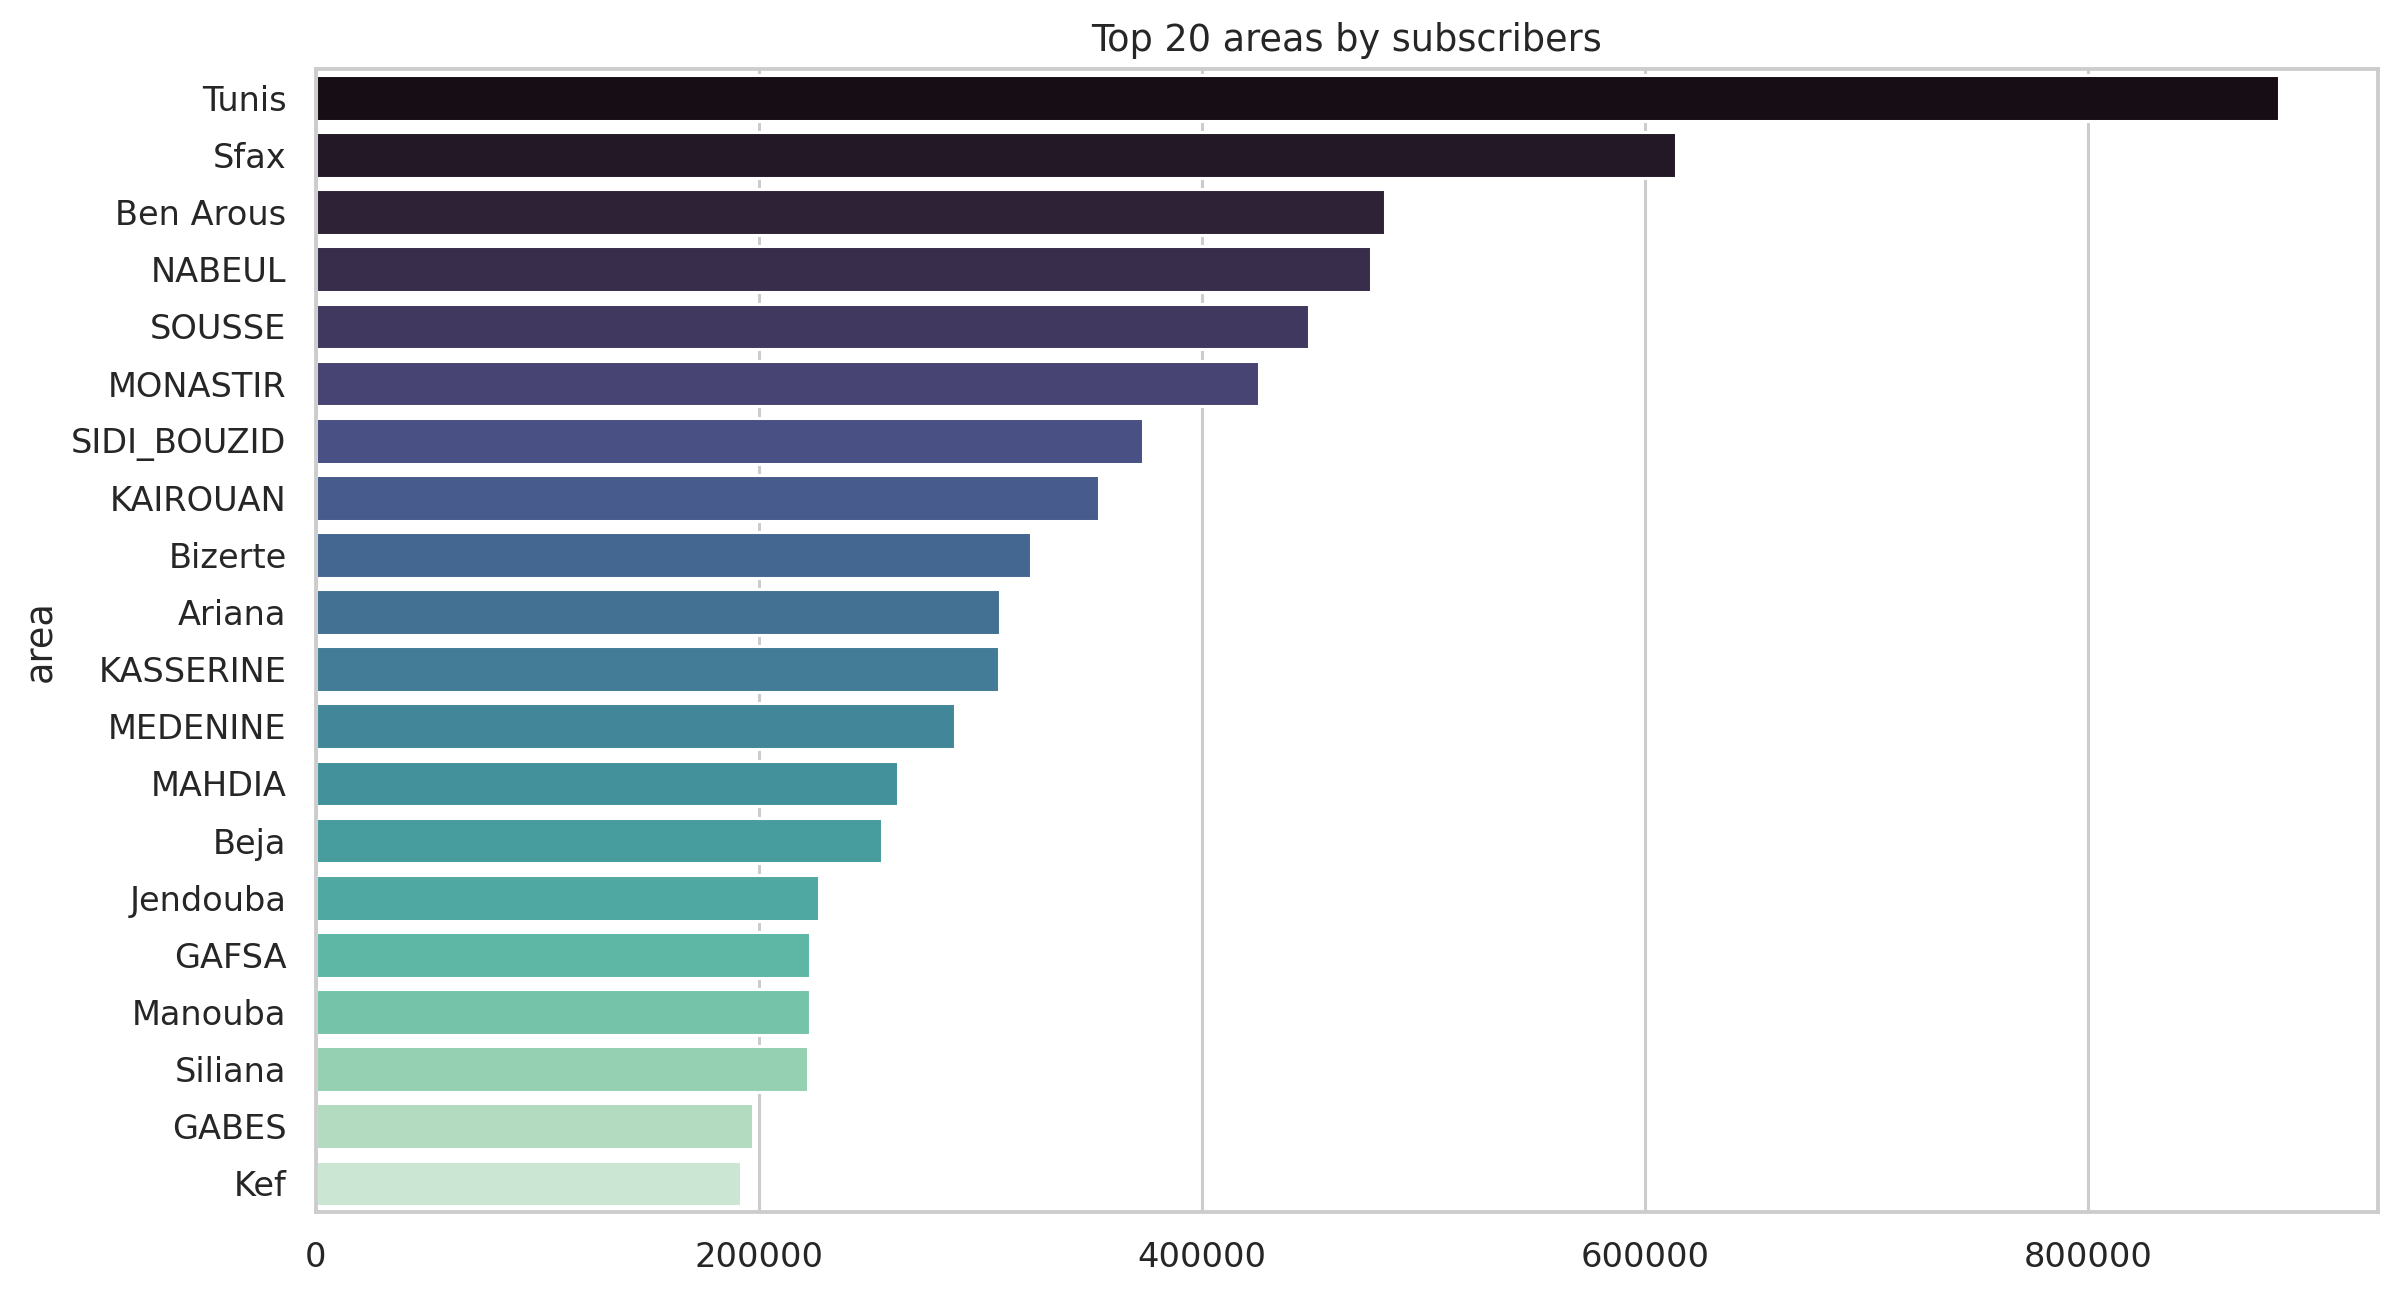

In [25]:
if 'area' in df_bss.columns:
    top = df_bss['area'].value_counts().head(20)
    fig, ax = plt.subplots(figsize=(11,6))
    sns.barplot(x=top.values, y=top.index, palette='mako', ax=ax, orient='h')
    ax.set_title('Top 20 areas by subscribers'); plt.tight_layout(); plt.show()

## 23 · Geographic Intelligence — Tunisia Governorate Choropleth

**What this shows:** Subscriber density mapped onto Tunisia's 24 ADM1 governorates using `dashboard/lib/tunisia-geojson.json`.
**What to look for:** Highest-density governorates (Tunis, Sfax, Sousse) are priority intervention zones. Light-colored governorates have low TT footprint.

[ok] tunisia-geojson loaded: 24 governorate polygons
    columns: ['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType', 'geometry']


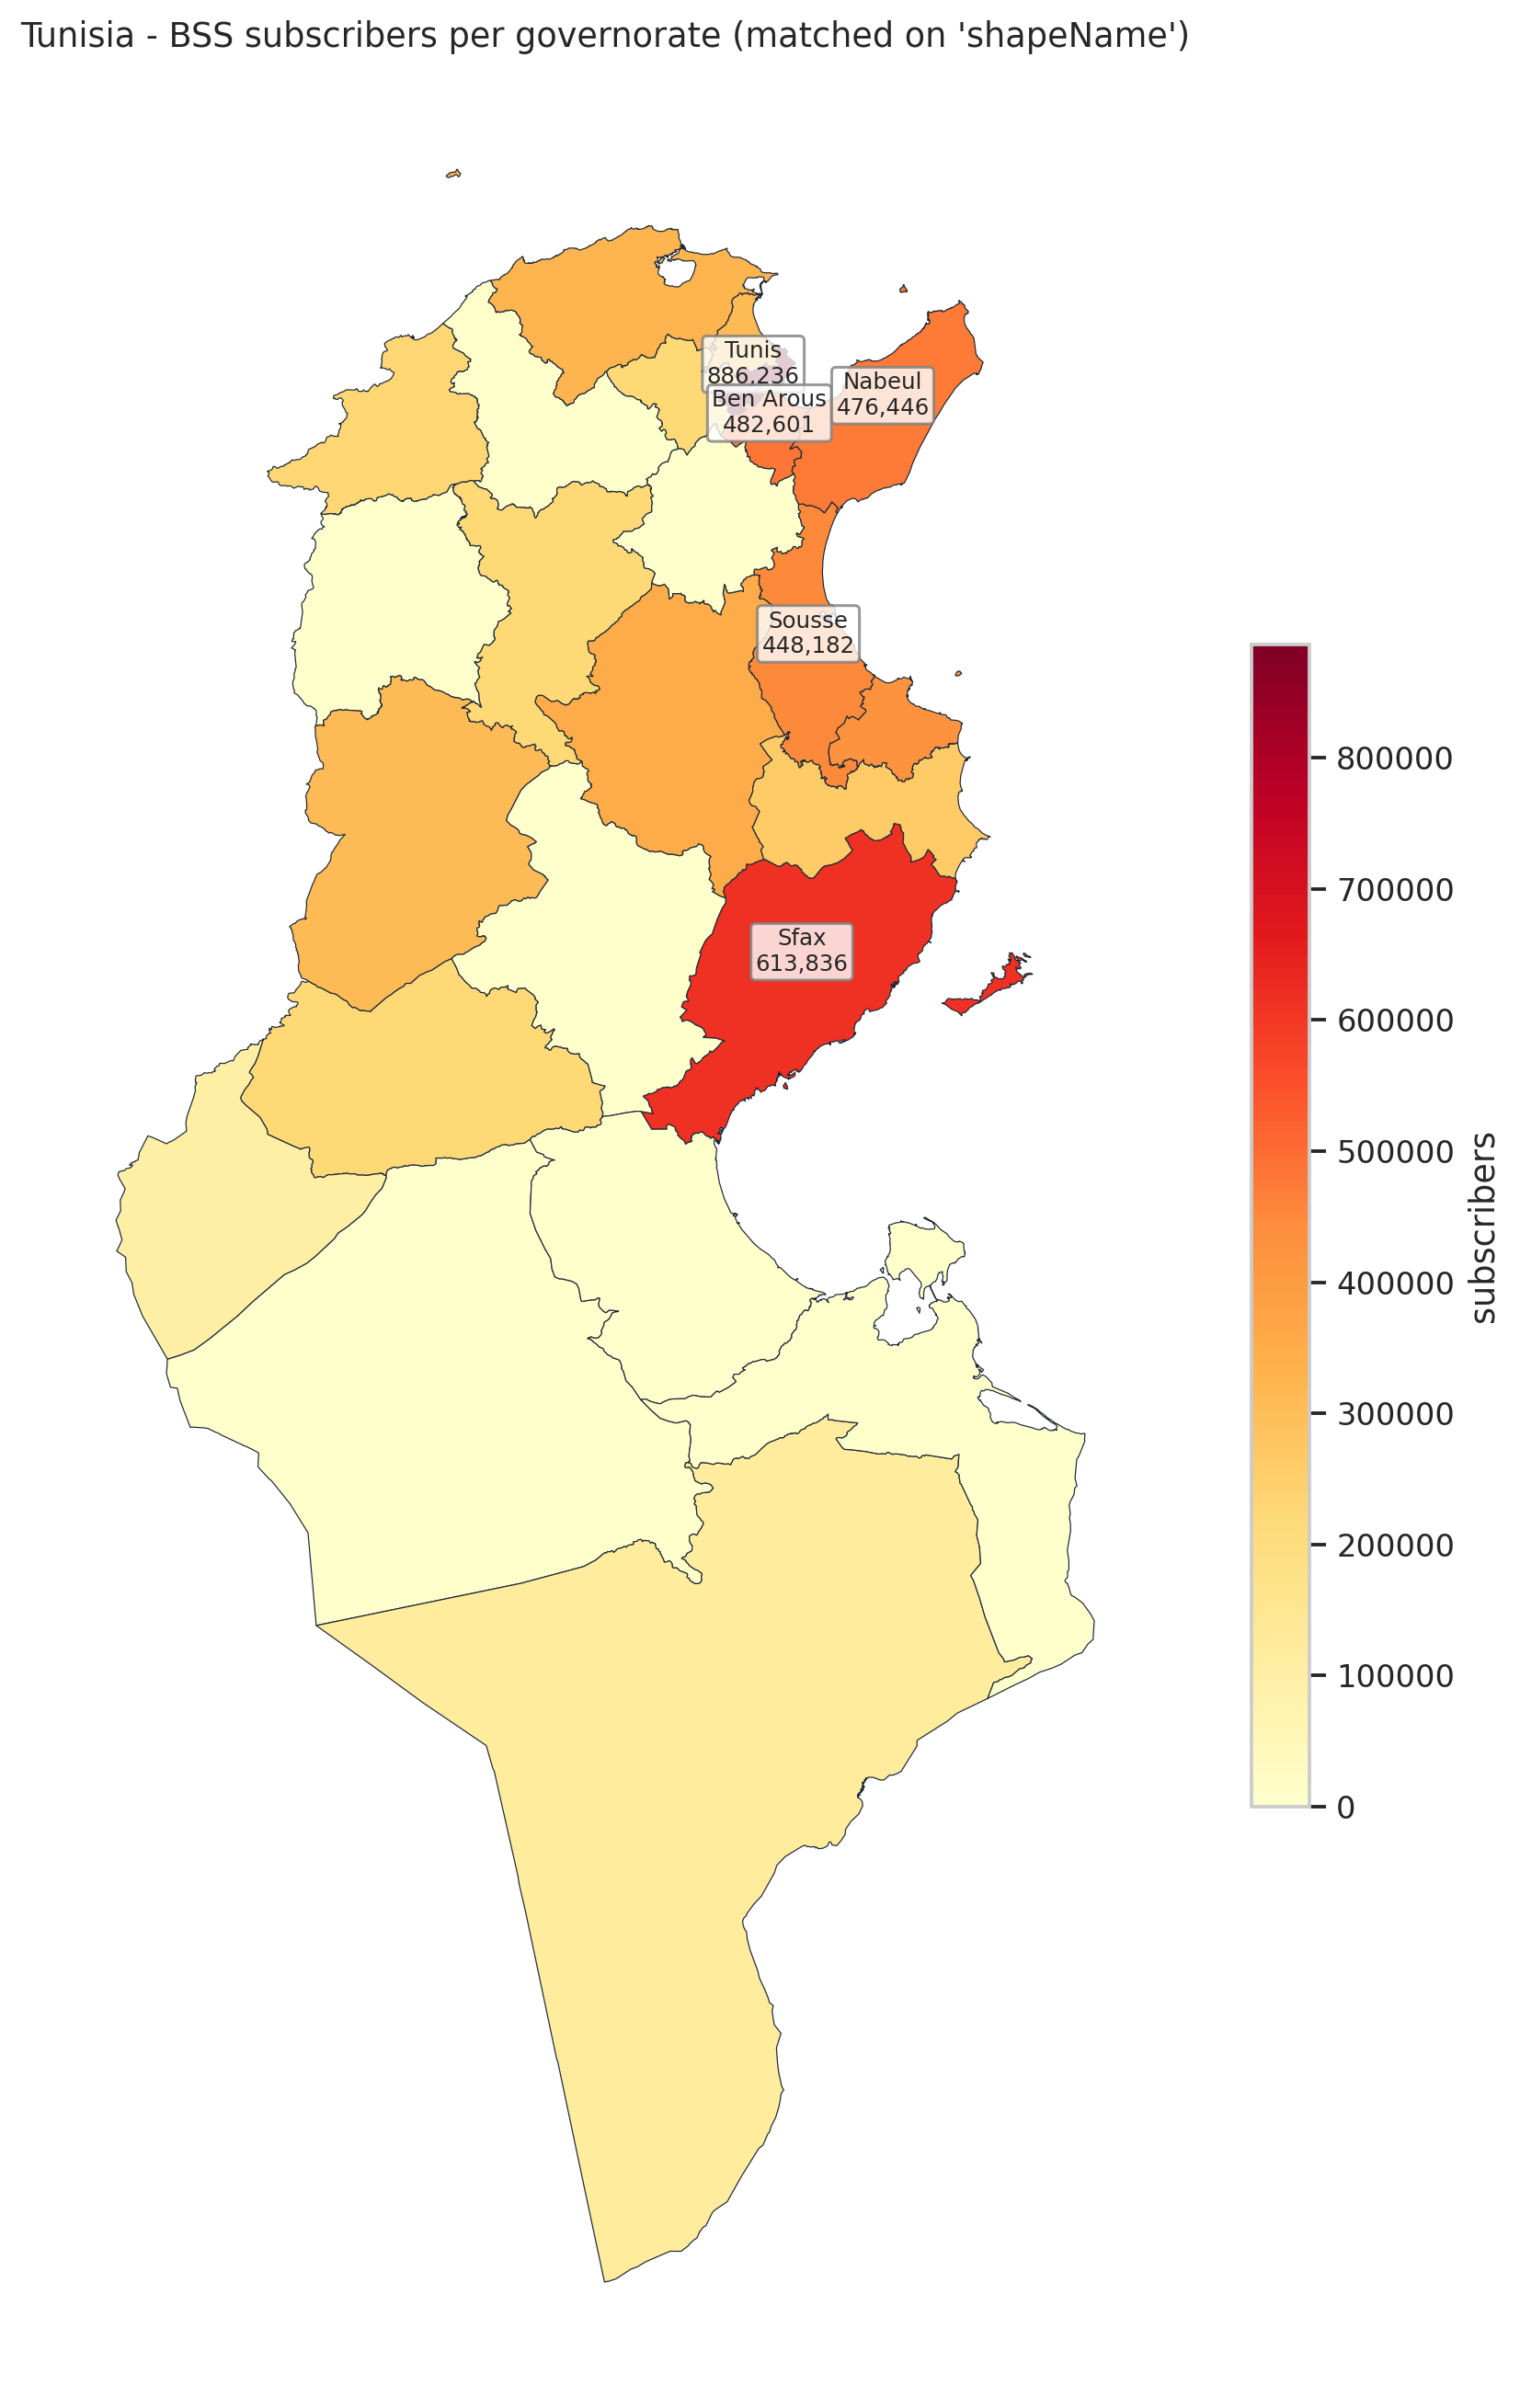


[match-rate] 17/24 governorates matched to BSS area column.


In [26]:
# --- Tunisia Governorate Choropleth ---
# Uses dashboard/lib/tunisia-geojson.json (24 governorates, ADM1 boundaries).
# Ref: https://geopandas.org/en/stable/docs/user_guide/mapping.html
# Defense relevance: spatial pattern of subscriber density reveals where churn / CEM
# interventions matter most (Tunis, Sfax, Sousse = highest density).

geojson_path = Path(TUNISIA_GEOJSON_PATH)
if not geojson_path.exists():
    project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
    geojson_path = project_root / 'dashboard' / 'lib' / 'tunisia-geojson.json'

if 'area' not in df_bss.columns or not HAVE_GEOPANDAS or not geojson_path.exists():
    print('[skip] choropleth requires: area column + geopandas + tunisia-geojson.json')
    print(f'   area:      {"area" in df_bss.columns}')
    print(f'   geopandas: {HAVE_GEOPANDAS}')
    print(f'   geojson:   {geojson_path.exists()} ({geojson_path})')
else:
    gdf = gpd.read_file(geojson_path)
    print(f'[ok] tunisia-geojson loaded: {len(gdf)} governorate polygons')
    print(f'    columns: {list(gdf.columns)}')

    area_counts = df_bss['area'].value_counts().to_dict()
    name_col = next(
        (c for c in gdf.columns if c.lower() in ('name', 'name_1', 'shapename', 'admin1name', 'gov')),
        gdf.columns[0],
    )
    gdf['subscribers'] = gdf[name_col].astype(str).str.lower().map(
        {a.lower(): n for a, n in area_counts.items()}
    ).fillna(0).astype(int)

    fig, ax = plt.subplots(figsize=(11, 12))
    gdf.plot(
        column='subscribers', ax=ax, legend=True, cmap='YlOrRd',
        edgecolor='#1f2937', linewidth=0.4,
        legend_kwds={'label': 'subscribers', 'shrink': 0.5},
        missing_kwds={'color': '#e5e7eb', 'edgecolor': '#9ca3af', 'hatch': '///', 'label': 'no data'},
    )
    top5 = gdf.nlargest(5, 'subscribers')
    for _, row in top5.iterrows():
        c = row.geometry.centroid
        ax.annotate(
            f"{row[name_col]}\n{row['subscribers']:,}",
            xy=(c.x, c.y), ha='center', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.8),
        )
    ax.set_title(f'Tunisia - BSS subscribers per governorate (matched on {name_col!r})', fontsize=12)
    ax.set_axis_off()
    plt.tight_layout(); plt.show()

    matched = (gdf['subscribers'] > 0).sum()
    print(f'\n[match-rate] {matched}/{len(gdf)} governorates matched to BSS area column.')
    if matched < len(gdf) // 2:
        print('   -> low match rate; in production, use dashboard/lib/tunisia-areas.ts mapping.')

## 23.5 · Telecom Cell Topology Graph

**What this shows:** A graph where each node is an area (governorate/region) and each
edge connects two areas whose OSS KPI profiles correlate strongly (Pearson r ≥ 0.7 on
integrity + call-drop-rate). Reveals geographic clusters of co-occurring network quality.

**What to look for:** Dense clusters = areas where network issues propagate together.
Isolated nodes = areas with unique KPI profiles needing individual attention.

**Method:** Spring layout (Fruchterman-Reingold 1991) — edge weight = Pearson r.
Reference: https://networkx.org/documentation/stable/reference/generated/networkx.drawing.layout.spring_layout.html

**Consumed by:** Granger causality panel in notebook 10.

In [27]:
# --- Telecom Cell Topology Graph ---
# Nodes = areas, edges = geographic KPI similarity (Pearson r >= TOPO_CORR_THRESHOLD)
# Ref: networkx spring_layout https://networkx.org/documentation/stable/reference/generated/networkx.drawing.layout.spring_layout.html
# OOM guard: uses OSS SAMPLE_ROWS_EDA rows max (set in constants cell)
# manual-run only if oss_raw is not populated

TOPO_CORR_THRESHOLD = 0.70  # minimum Pearson r to draw an edge

try:
    import networkx as nx
    _nx_ok = True
except ImportError:
    _nx_ok = False
    print('[topology] networkx not installed — pip install networkx==3.3 to enable this cell')

if _nx_ok and 'oss_raw' in dir() and oss_raw:
    # Build area-level KPI matrix from all RATs combined (sample for speed)
    _frames = []
    for rat, _df in oss_raw.items():
        _sample = _df.sample(min(len(_df), 20_000), random_state=SEED)
        _integ_c = next((c for c in _sample.columns if c.lower().startswith('integrity')), None)
        _cdr_c   = next((c for c in _sample.columns if 'call drop' in c.lower()), None)
        if _integ_c and _cdr_c and 'area' in _sample.columns:
            _sub = _sample[['area', _integ_c, _cdr_c]].rename(columns={_integ_c:'integ', _cdr_c:'cdr'})
            _sub['integ'] = pd.to_numeric(_sub['integ'], errors='coerce')
            _sub['cdr']   = pd.to_numeric(_sub['cdr'],   errors='coerce')
            _frames.append(_sub)

    if _frames:
        _kpi = pd.concat(_frames).groupby('area')[['integ','cdr']].mean().dropna()
        areas = _kpi.index.tolist()
        n = len(areas)
        print(f'[topology] {n} areas with KPI data')

        # Build correlation matrix (area × area) on [integ, cdr]
        _mat = _kpi.T  # shape (2, n_areas)
        import numpy as np
        corr_mat = np.corrcoef(_mat.values.T)  # (n_areas, n_areas)

        # Build graph
        G = nx.Graph()
        G.add_nodes_from(areas)
        for i in range(n):
            for j in range(i+1, n):
                r = corr_mat[i, j]
                if not np.isnan(r) and r >= TOPO_CORR_THRESHOLD:
                    G.add_edge(areas[i], areas[j], weight=float(r))

        print(f'[topology] {G.number_of_edges()} edges (r >= {TOPO_CORR_THRESHOLD})')

        # Color nodes by avg integrity (green=high, red=low)
        integ_vals = [_kpi.loc[a, 'integ'] for a in G.nodes()]
        import matplotlib.cm as cm
        _norm = plt.Normalize(vmin=min(integ_vals), vmax=max(integ_vals))
        node_colors = [cm.RdYlGn(_norm(v)) for v in integ_vals]

        fig, ax = plt.subplots(figsize=(13, 9))
        pos = nx.spring_layout(G, seed=SEED, k=2.5/max(n**0.5, 1))
        edge_weights = [G[u][v]['weight'] for u,v in G.edges()]
        nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=400, ax=ax)
        nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
        nx.draw_networkx_edges(G, pos, width=[w*2 for w in edge_weights],
                                alpha=0.6, edge_color='steelblue', ax=ax)
        sm = plt.cm.ScalarMappable(cmap=cm.RdYlGn, norm=_norm)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label='avg integrity %')
        ax.set_title(f'Area KPI Similarity Graph — {G.number_of_nodes()} nodes, {G.number_of_edges()} edges  (r≥{TOPO_CORR_THRESHOLD})')
        ax.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print('[topology] no area+KPI data available — skipping graph')
else:
    print('[topology] oss_raw not available or networkx missing — cell is manual-run only')

[topology] no area+KPI data available — skipping graph


## 21 · Anomaly rate per RAT (integrity<100 OR cdr>2)

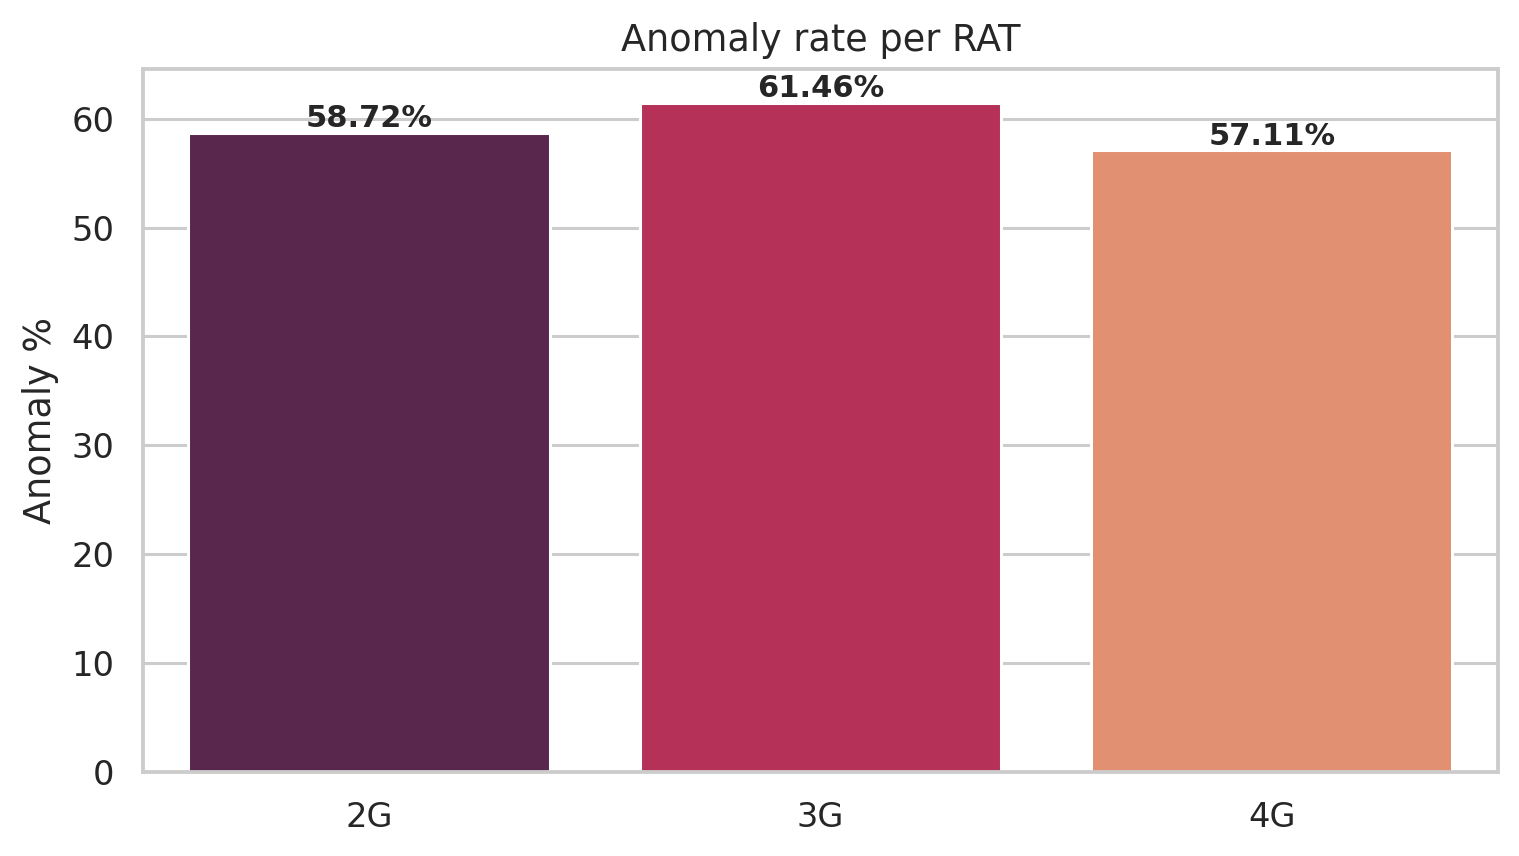

{'2G': np.float64(58.72), '3G': np.float64(61.46), '4G': np.float64(57.11)}


In [28]:
rates = {}
for rat, df in oss_raw.items():
    integ_s = df[integ(df)].astype(str).str.rstrip('%').replace('', np.nan).astype(float)
    cdr_c = cdr(df)
    cdr_s = pd.to_numeric(df[cdr_c], errors='coerce').fillna(0) if cdr_c else pd.Series(0, index=df.index)
    a = ((integ_s<100) | (cdr_s>2)).fillna(False)
    rates[rat] = round(a.mean()*100, 2)
fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(x=list(rates.keys()), y=list(rates.values()), palette='rocket', ax=ax)
for i,v in enumerate(rates.values()): ax.text(i, v+0.5, f'{v}%', ha='center', fontweight='bold')
ax.set_ylabel('Anomaly %'); ax.set_title('Anomaly rate per RAT'); plt.tight_layout(); plt.show()
print(rates)

## 24 · Real-vs-Simulated Validation (Kolmogorov-Smirnov test)

**What this shows:** A two-sample KS test (Massey 1951) on each numeric column to STATISTICALLY validate whether the simulator preserves the real-data distribution. Visual KDE overlay (§10) is intuition; KS gives a p-value + effect size.
**What to look for:** Read EFFECT SIZE (D) before p-value — at N=50K per group, even small drifts become 'significant'. D<0.1 = small (good), D>0.2 = large (concerning).

,column,ks_statistic_D,p_value,drift_detected,effect_size,n_real,n_simulated
0,dou_total,0.0463,4.74e-47,True,small,50000,50000
1,duration,0.0088,4.29e-02,True,small,50000,50000
2,traffic_4g,0.0098,1.60e-02,True,small,50000,50000
3,s1_mme_sr,0.0032,9.57e-01,False,small,50000,50000
4,iu_attach_sr,0.0010,1.00e+00,False,small,50000,50000
5,gb_attach_sr,0.0079,8.51e-02,False,small,50000,50000
6,voice_onlinetime_3g,0.0068,1.92e-01,False,small,50000,50000


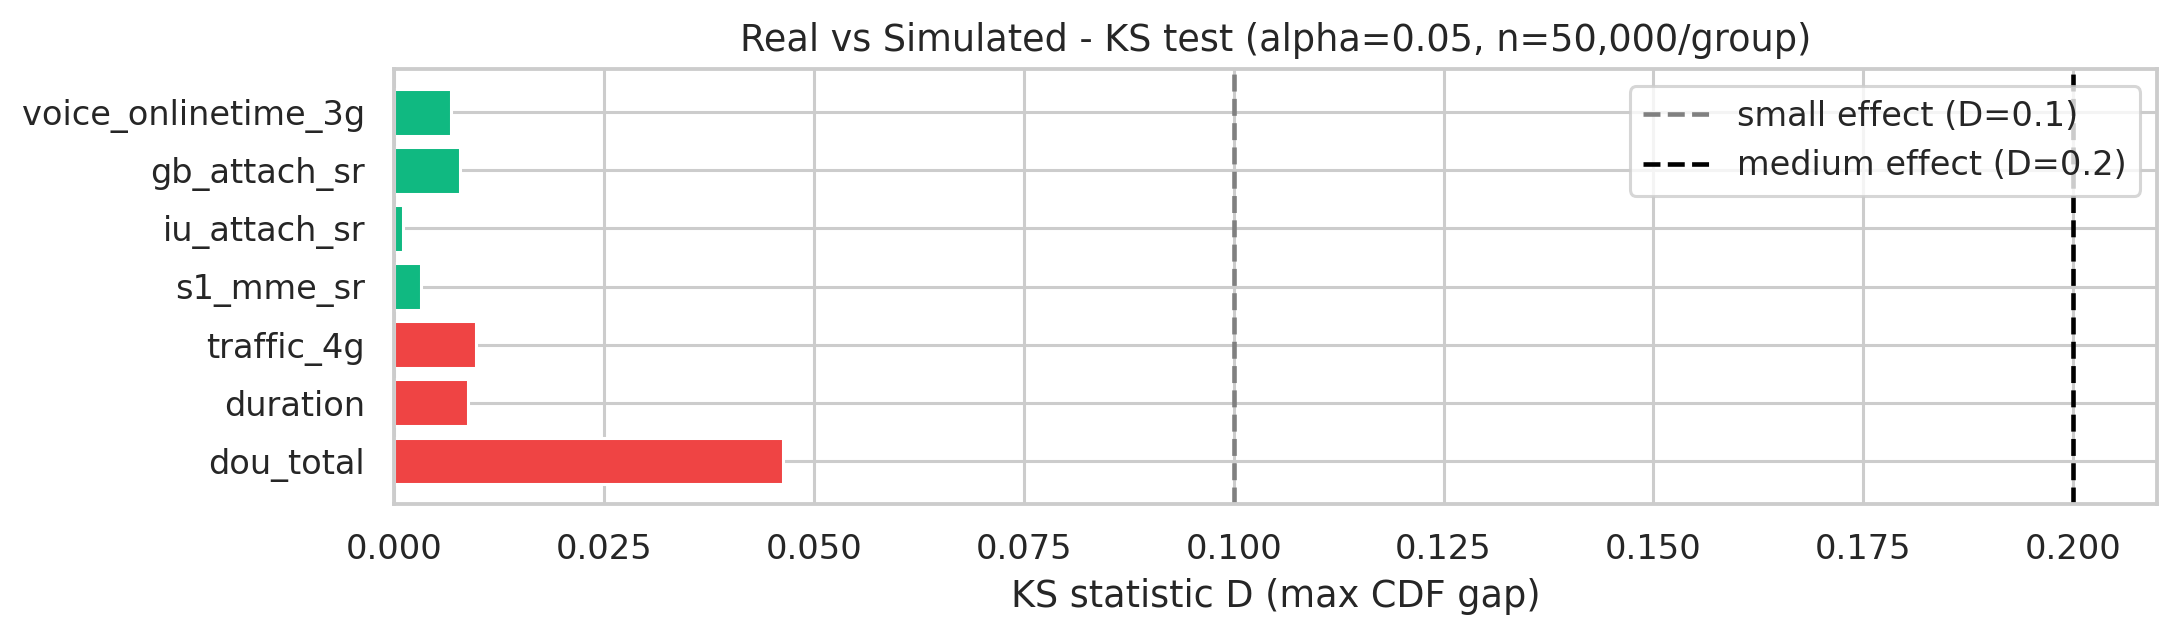


Drift summary: 3/7 columns show statistically significant drift.
NOTE: at N=50K, even tiny differences trigger p<0.05. Focus on EFFECT SIZE (D), not just p.


In [29]:
# --- Kolmogorov-Smirnov: statistical validation of real-vs-simulated distributions ---
# Visual KDE overlay (§10) only suggests similarity; KS test gives a p-value.
# Refs:
#   - Massey FJ (1951). The Kolmogorov-Smirnov Test for Goodness of Fit. JASA.
#   - scipy.stats.ks_2samp - two-sample two-sided test
# Interpretation:
#   - p >= alpha -> distributions NOT significantly different (good - simulator faithful)
#   - p <  alpha -> distributions DIFFER (drift; check whether intentional)
# Note: KS is sensitive - even small differences become significant at large N.
#       We report KS statistic D (effect size) alongside p.

ks_results = []
candidate_cols = [c for c in ['dou_total', 'duration', 'traffic_4g', 's1_mme_sr',
                              'iu_attach_sr', 'gb_attach_sr', 'voice_onlinetime_3g']
                  if c in df_bss.columns]

KS_SAMPLE_PER_GROUP = 50_000
for col in candidate_cols:
    r = df_bss.loc[df_bss.source_origin == 'real',      col].dropna().astype(float)
    s = df_bss.loc[df_bss.source_origin == 'simulated', col].dropna().astype(float)
    if r.empty or s.empty:
        continue
    r_samp = r.sample(n=min(KS_SAMPLE_PER_GROUP, len(r)), random_state=SEED)
    s_samp = s.sample(n=min(KS_SAMPLE_PER_GROUP, len(s)), random_state=SEED)
    ks = stats.ks_2samp(r_samp, s_samp, alternative='two-sided')
    ks_results.append({
        'column':         col,
        'ks_statistic_D': round(float(ks.statistic), 4),
        'p_value':        f'{ks.pvalue:.2e}',
        'drift_detected': ks.pvalue < KS_PVALUE_DRIFT_ALPHA,
        'effect_size':    'small' if ks.statistic < 0.1 else 'medium' if ks.statistic < 0.2 else 'large',
        'n_real':         len(r_samp),
        'n_simulated':    len(s_samp),
    })

ks_df = pd.DataFrame(ks_results)
display(ks_df)

if not ks_df.empty:
    fig, ax = plt.subplots(figsize=(10, max(3, 0.4 * len(ks_df))))
    colors = ['#ef4444' if d else '#10b981' for d in ks_df['drift_detected']]
    ax.barh(ks_df['column'], ks_df['ks_statistic_D'], color=colors)
    ax.axvline(0.1, color='gray', linestyle='--', label='small effect (D=0.1)')
    ax.axvline(0.2, color='black', linestyle='--', label='medium effect (D=0.2)')
    ax.set_xlabel('KS statistic D (max CDF gap)')
    ax.set_title(f'Real vs Simulated - KS test (alpha={KS_PVALUE_DRIFT_ALPHA}, n={KS_SAMPLE_PER_GROUP:,}/group)')
    ax.legend()
    plt.tight_layout(); plt.show()

drift_count = int(ks_df['drift_detected'].sum()) if not ks_df.empty else 0
print(f'\nDrift summary: {drift_count}/{len(ks_df)} columns show statistically significant drift.')
print('NOTE: at N=50K, even tiny differences trigger p<0.05. Focus on EFFECT SIZE (D), not just p.')

## 22 · Summary (in-memory)

Findings dictionary. Nothing written to disk. Notebook 01 owns persistence.

In [30]:
import json as _json
summary = {
    'bss_total_rows': int(len(df_bss)),
    'bss_real_rows': int((df_bss.source_origin=='real').sum()),
    'bss_simulated_rows': int((df_bss.source_origin=='simulated').sum()),
    'bss_nan_columns': int((nan_pct>0).sum()),
    'oss_rat_anomaly_rates_pct': rates,
    'oss_total_rows': {rat: int(df.shape[0]) for rat,df in oss_raw.items()},
}
print(_json.dumps(summary, indent=2, default=str))

{
  "bss_total_rows": 7968077,
  "bss_real_rows": 968077,
  "bss_simulated_rows": 7000000,
  "bss_nan_columns": 10,
  "oss_rat_anomaly_rates_pct": {
    "2G": 58.72,
    "3G": 61.46,
    "4G": 57.11
  },
  "oss_total_rows": {
    "2G": 80000,
    "3G": 80000,
    "4G": 240000
  }
}


---
## Next: notebook 01
Open `01_etl_feature_engineering.ipynb` — it uploads these CSVs to MinIO, cleans, engineers, splits.

---

## 26 · Limitations & Threats to Validity

Defense reviewers will ask. Document them upfront.

### Data limitations

- **Real data covers only 2 months (Feb + Mars 2026).** All other months are bootstrap-simulated. The simulator preserves marginal distributions and intra-month correlations but **cannot reproduce inter-month temporal dynamics** (seasonality, churn waves, network outages). KS test (§24) gives statistical evidence of per-column fidelity, but inter-feature joint distributions are not validated.
- **`_consistent` simulator variants double-load August / April / January / May / June / July / September.** Cell §3 emits a `[warn]` when duplicate-month files are detected. Owner decision pending: dedup by `(imsi, month_year)` or keep both as augmentation. Tracked in `notebooks/reports/00_findings.md` (B1).
- **OSS data is point-in-time (April 27, 2026 export).** No temporal axis on OSS — Granger causality analysis (notebook 10) operates on monthly area aggregates, not raw OSS time series.
- **OSS↔BSS join key is *area*, not subscriber↔cell.** Real CEM analysis would require IMSI↔cell binding, which Tunisie Telecom did not provide. All cross-source analysis is **area-level**, not subscriber-level.

### Methodological caveats

- **Pearson + Spearman + Mutual Information** are pairwise, not joint. Multivariate dependencies are not tested.
- **KS test is sensitive at large N** (Massey 1951): at N=50K per group, even practically-negligible differences become statistically significant. Always read **effect size D** alongside the p-value.
- **`dou_total` quartile used as CEM-score proxy** in §22.5 (the true `cem_score` column is computed in notebook 01).
- **Choropleth match rate** depends on `area` column ↔ governorate name fuzzy matching. For production-grade defense visuals, switch to the `dashboard/lib/tunisia-areas.ts` mapping (cell-site prefix → governorate).

### Reproducibility caveats

- `SEED=42` is set globally for `numpy` / `random` / `PYTHONHASHSEED`. PyTorch / CUDA seeds are notebook-02/03/04 concerns and **not set here**.
- Sample sizes are constants in the parameters cell; papermill can override at retrain time.

### What we did NOT do (deliberate scope cuts)

- We did not **profile** with `ydata-profiling` or `sweetviz`. Reasoning: those produce 50-page HTML reports that hide the methodology behind a black box; defense reviewers prefer explicit, cited diagnostics.
- We did not **write** any artifact to disk. Notebook 01 owns persistence — this notebook stays read-only by contract (cell §0).
- We did not **fix bug B1** (`_consistent` double-load) — that's an owner decision, not a code-review fix. Tracked in findings.md.

---

## 27 · Sources & Methodology Citations

| Method | Source |
|---|---|
| CRISP-DM Phase 2 structure | Chapman et al. (2000), *CRISP-DM 1.0 Step-by-step data mining guide*. SPSS. |
| Missingness diagnostics (`missingno`) | ResidentMario/missingno · https://github.com/ResidentMario/missingno (3.5k+ stars) |
| MAR / MCAR / MNAR theory | Little RJA, Rubin DB. *Statistical Analysis with Missing Data*. Wiley (2002). |
| Spearman rank correlation | Spearman C. (1904). "The Proof and Measurement of Association between Two Things". *Am. J. Psychol.* |
| Mutual Information | Reshef DN et al. (2011). "Detecting Novel Associations in Large Data Sets". *Science.* |
| Mutual Information implementation | scikit-learn — `sklearn.feature_selection.mutual_info_regression` |
| Skewness threshold for log1p | Bulmer MG. (1979). *Principles of Statistics.* Dover. |
| Kolmogorov-Smirnov test | Massey FJ. (1951). "The Kolmogorov-Smirnov Test for Goodness of Fit". *JASA.* |
| KS implementation | `scipy.stats.ks_2samp` |
| Choropleth pattern | geopandas official tutorial · https://geopandas.org/en/stable/docs/user_guide/mapping.html |
| Tunisia ADM1 GeoJSON | Project asset · `dashboard/lib/tunisia-geojson.json` (24 governorates) |
| Kaggle Grandmaster EDA patterns | subinium/analysis-of-eda-notebooks, vbmokin/eda-for-tabular-data-advanced-techniques |
| Kaggle EDA best-practices | The_Kaggler_voice (Medium). "Kaggle Project Best Practices 101: EDA". |
| Kaggle EDA curated list | https://www.kaggle.com/getting-started/265590 |

---

## Next: notebook 01

Open `01_etl_feature_engineering.ipynb` — it uploads these CSVs to MinIO, cleans, engineers, splits.